# 🏆 Fodboldquiz — Komplet system v4

**Alt i én notebook.** Kør sektionerne **i rækkefølge** — én gang per uge.

| Del | Hvornår | Beskrivelse |
|-----|---------|-------------|
| **00 Opsætning** | Én gang per session | Mount Drive, installer pakker, definer aliasser |
| **01 Import kampe** | Mandag | Parse + match kampe mod API-Sports fixtures |
| **02 Odds** | Mandag | Hent odds (API-Sports betalt) + ELO/Opta rankings |
| **03 Forudsigelser** | Inden kampstart | Indtast spillernes bud |
| **04 Resultater** | Søndag aften | Hent 1/X/2 via API-Sports fixture_id |
| **05 Point & stilling** | Søndag aften | Beregn point, H2H, ELO |
| **06 Dashboard** | Søndag aften | Charts og statistik |
| **07 Historisk import** | Én gang | Importer Excel-historik til CSV |

> **Arkitektur:** API-Sports er primær datakilde for fixtures og resultater.
> fixture\_id gemmes ved import og bruges til præcise opslag — ingen fuzzy-match ved resultathentning.

> **Dataregel:** Tomme/None-værdier **overskriver aldrig** eksisterende data.
> Brug altid `df.loc[new_values.notna(), col] = new_values` ved opdatering.

In [6]:
# ── ENGANGSKØRSEL: Kopiér data fra Drive til GitHub ────────────────────────
import os, subprocess
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
REPO = "Stenner93/Odds"

# Klon repoen
subprocess.run([
    'git', 'clone',
    f'https://{GITHUB_TOKEN}@github.com/{REPO}.git',
    '/content/Odds'
], check=True)

# Opret data-mappe i repoen
os.makedirs('/content/Odds/data', exist_ok=True)

# Kopiér alle datafiler fra Drive
import shutil
DRIVE_DATA = '/content/drive/MyDrive/fodboldquiz/data'
GITHUB_DATA = '/content/Odds/data'

filer = [
    'weekly_matches.csv', 'predictions.csv', 'odds.csv',
    'points.csv', 'h2h.csv', 'standings.csv', 'elo_history.csv',
    'hist_matches.csv', 'hist_odds.csv', 'hist_predictions.csv',
    'player_stats.csv', 'national_elo.csv', 'hold_mapping.json',
    'model_params.json', 'model_calibration.json', 'fdc_goals.csv',
    'dashboard_template.html'
]

kopieret = []
for f in filer:
    src = os.path.join(DRIVE_DATA, f)
    dst = os.path.join(GITHUB_DATA, f)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        kopieret.append(f)
    else:
        print(f"  ⚠️  Ikke fundet: {f}")

print(f"\n✅ Kopieret {len(kopieret)} filer til /content/Odds/data/")

# Push til GitHub
os.chdir('/content/Odds')
subprocess.run(['git', 'config', 'user.email', 'andersstenner@hotmail.com'], check=True)
subprocess.run(['git', 'config', 'user.name', 'Stenner93'], check=True)
subprocess.run(['git', 'add', 'data/'], check=True)
subprocess.run(['git', 'commit', '-m', 'feat: tilføj datafiler til repo'], check=True)
subprocess.run(['git', 'push'], check=True)
print("✅ Data pushet til GitHub")

  ⚠️  Ikke fundet: model_calibration.json

✅ Kopieret 16 filer til /content/Odds/data/
✅ Data pushet til GitHub


## 🔧 00 — Opsætning
*Kør én gang: Drive-godkendelse, globale imports.*


In [1]:
# ── 00-A  Drive auth ─────────────────────────────────────────────────────────
# Prøver Service Account via Colab Secrets (INGEN popup).
# Fallback: standard drive.mount() OAuth-popup.
#
# OPSÆTNING (én gang, ~20 min):
#   1. console.cloud.google.com → IAM & Admin → Service Accounts → Opret
#   2. Download JSON-nøgle (Actions → Manage keys → Add key → JSON)
#   3. Del Drive-mappen 'fodboldquiz/data' med service account-email (Redaktør)
#   4. Colab: hængelås-ikon i venstre sidebar → Tilføj hemmelighed:
#        Navn:  SERVICE_ACCOUNT_JSON
#        Værdi: <indsæt hele JSON-indholdet>
#      Aktiver hemmelighed for denne notebook ✓
#   5. DRIVE_FOLDER_ID nedenfor: find folder-ID fra Drive URL:
#        https://drive.google.com/drive/folders/<FOLDER_ID>
#
# Herefter kører notebooken uden popup!

DRIVE_FOLDER_ID = ''  # ← Indsæt dit mappe-ID her (se trin 5 ovenfor)

_SA_MODE   = False
_drive_svc = None

try:
    from google.colab import userdata as _ud
    _sa_json_str = _ud.get('SERVICE_ACCOUNT_JSON')
    if not _sa_json_str:
        raise ValueError('SERVICE_ACCOUNT_JSON ikke sat i Colab Secrets')

    import json as _json_auth
    from google.oauth2 import service_account as _sa_mod
    from googleapiclient.discovery import build as _gapi_build

    _sa_info  = _json_auth.loads(_sa_json_str)
    _sa_creds = _sa_mod.Credentials.from_service_account_info(
        _sa_info,
        scopes=['https://www.googleapis.com/auth/drive']
    )
    _drive_svc = _gapi_build('drive', 'v3', credentials=_sa_creds)

    # Download alle projektfiler til lokal tmp-mappe
    import os as _os_sa, io as _io_sa
    from googleapiclient.http import MediaIoBaseDownload as _MIoD

    _LOCAL_TMP = '/content/fodboldquiz_sa'
    _os_sa.makedirs(_LOCAL_TMP, exist_ok=True)

    if DRIVE_FOLDER_ID:
        _files = _drive_svc.files().list(
            q=f"'{DRIVE_FOLDER_ID}' in parents and trashed=false",
            fields='files(id,name)',
            pageSize=200
        ).execute().get('files', [])
        _downloaded = 0
        for _fi in _files:
            if not any(_fi['name'].endswith(ext) for ext in ('.csv', '.json', '.html', '.xlsx')):
                continue
            _fh = _io_sa.BytesIO()
            _dl = _MIoD(_drive_svc.files().get_media(fileId=_fi['id']), _fh)
            while True:
                _, done = _dl.next_chunk()
                if done: break
            with open(_os_sa.path.join(_LOCAL_TMP, _fi['name']), 'wb') as _out:
                _out.write(_fh.getvalue())
            _downloaded += 1
        print(f'  ✅ Hentet {_downloaded} filer fra Drive (SA)')
        _SA_DATA_DIR = _LOCAL_TMP
    else:
        print('  ⚠ DRIVE_FOLDER_ID ikke sat — filer hentes ikke automatisk')
        _SA_DATA_DIR = None

    _SA_MODE = True
    print('✅ Drive auth: Service Account (ingen popup!)')

except Exception as _sa_err:
    _sa_msg = str(_sa_err)
    if 'SERVICE_ACCOUNT_JSON ikke sat' not in _sa_msg:
        print(f'  ⚠ SA-fejl: {_sa_err}')
    from google.colab import drive as _colab_drive
    _colab_drive.mount('/content/drive')
    _SA_DATA_DIR = None
    print('✅ Drive auth: OAuth (monteret)')

# ── 00-B  GitHub-tilslutning ────────────────────────────────────────────────
import subprocess as _sp, os as _os_gh

GITHUB_MODE  = False
GITHUB_LOCAL = '/content/Odds'
GITHUB_REPO  = 'Stenner93/Odds'

try:
    _gt = _ud.get('GITHUB_TOKEN')
    if not _gt:
        raise ValueError('GITHUB_TOKEN ikke sat i Colab Secrets')

    if _os_gh.path.exists(f'{GITHUB_LOCAL}/.git'):
        _r = _sp.run(['git','-C',GITHUB_LOCAL,'pull'],
                     capture_output=True, text=True, timeout=30)
        print('✅ GitHub: pull OK' if _r.returncode==0 else f'⚠️  Pull fejl: {_r.stderr[:100]}')
    else:
        _r = _sp.run([
            'git','clone',
            f'https://{_gt}@github.com/{GITHUB_REPO}.git', GITHUB_LOCAL
        ], capture_output=True, text=True, timeout=60)
        print('✅ GitHub: klonet' if _r.returncode==0 else f'⚠️  Clone fejl: {_r.stderr[:100]}')

    if _r.returncode == 0:
        _sp.run(['git','-C',GITHUB_LOCAL,'config','user.email','andersstenner@hotmail.com'], capture_output=True)
        _sp.run(['git','-C',GITHUB_LOCAL,'config','user.name','Stenner93'], capture_output=True)
        GITHUB_MODE = True

except Exception as _e_gh:
    print(f'⚠️  GitHub-tilslutning fejlede: {_e_gh}')

if not GITHUB_MODE:
    print('ℹ️  Kører i Drive-mode (fallback)')


  ⚠ SA-fejl: Secret SERVICE_ACCOUNT_JSON does not exist.
Mounted at /content/drive
✅ Drive auth: OAuth (monteret)


In [2]:
import pandas as pd # Ensuring pandas is available globally for csv_upsert
import os           # Ensuring os is available globally for csv_upsert

# ── 01-A  Konfiguration ──────────────────────────────────────────────────
# CURRENT_ROUND sættes automatisk af celle 01-D ("Runde nr. X" fra kuponsteksten)
# Ingen grund til at ændre noget her — 01-D er altid master
CURRENT_SEASON = 4     # Sæson 4 = 2025/26  (historisk: 1-3)
CURRENT_ROUND = None  # Sættes automatisk af 01-D fra kuponsteksten — ingen grund til at ændre dette

# API-Sports sæson-år — bruges til fixture-opslag
# Typisk det år, kampene STARTER (f.eks. 2025 for 2025/26-sæsonen)
API_SEASON_YEAR = 2025  # ← juster ved sæsonstart

print(f'Sæson {CURRENT_SEASON}, runde {CURRENT_ROUND}')
# ── Fælles hjælpefunktioner (bruges på tværs af celler) ────────────────────
def _norm_bet(v):
    """Konverterer råt gætværdi til '1'/'X'/'2' eller None.
    Håndterer 1/9/2-format (Mortens tabel), X-streng og NaN.
    Defineret her (01-A) så alle celler bruger SAMME implementering."""
    if v is None: return None
    try:
        s = str(v).strip()
        if s.lower() in ('nan', 'none', ''): return None
        if s in ('1', '1.0'): return '1'
        if s in ('9', '9.0', 'X', 'x'): return 'X'
        if s in ('2', '2.0'): return '2'
        vi = int(float(s))
        return {1: '1', 9: 'X', 2: '2'}.get(vi)
    except:
        return None

# H2H point-konstanter (defineret tidligt så 03-B og 05-A bruger samme)
H2H_WIN  = 3
H2H_DRAW = 1
H2H_LOSS = 0


print(f'API sæson-år: {API_SEASON_YEAR}')

# ── Forkortelsesnavne-omdøbninger (slår igennem i ALLE CSVer med det samme) ──
# Tilføj her når hold_mapping.json opdateres med nye forkortelser.
# Format: {'GAMMEL_KODE': 'NY_KODE'}
# Koden gennemløber weekly_matches, odds, predictions og h2h og erstatter
# alle forekomster af gamle koder — både i match_code og i home/away_abbr felter.
CODE_RENAMES = {
    'SY2': 'RSA',   # Sydafrika
    'SY3': 'SYK',   # Sydkorea
}

if CODE_RENAMES:
    import pandas as _pd_cr, os as _os_cr
    _DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('')) if '__file__' not in dir() else os.path.dirname(__file__), 'data')
    # Colab-sti
    for _d in ['/content/drive/MyDrive/fodboldquiz/data', _DATA_DIR]:
        if _os_cr.path.isdir(_d): _DATA_DIR = _d; break
    _CSV_FILES = [
        ('weekly_matches.csv', ['match_code','home_abbr_temp','away_abbr_temp']),
        ('odds.csv',           ['match_code','home_abbr_temp','away_abbr_temp']),
        ('predictions.csv',    ['match_code']),
        ('h2h.csv',            []),   # h2h har ikke match_code — springes over
    ]
    _total_renames = 0
    for _fname, _cols in _CSV_FILES:
        _fpath = _os_cr.path.join(_DATA_DIR, _fname)
        if not _os_cr.path.exists(_fpath): continue
        try:
            _df_cr = _pd_cr.read_csv(_fpath, dtype=str).fillna('')
            _changed = 0
            for _col in _cols:
                if _col not in _df_cr.columns: continue
                for _old, _new in CODE_RENAMES.items():
                    # Erstat præcis kode i match_code (eks. ODD-SY2 → ODD-RSA)
                    import re as _re_cr
                    _before = _df_cr[_col].copy()
                    _df_cr[_col] = _df_cr[_col].apply(
                        lambda v: _re_cr.sub(r'(?<![A-ZÆØÅ])' + _re_cr.escape(_old) + r'(?![A-ZÆØÅ])', _new, v)
                    )
                    _changed += (_df_cr[_col] != _before).sum()
            if _changed:
                _df_cr.to_csv(_fpath, index=False)
                _total_renames += _changed
                print(f'  CODE_RENAMES: {_fname} — {_changed} felter opdateret')
        except Exception as _e_cr:
            print(f'  ⚠ CODE_RENAMES {_fname}: {_e_cr}')
    if _total_renames:
        print(f'✅ CODE_RENAMES: {_total_renames} koder opdateret på tværs af CSV-filer')
    else:
        print('ℹ CODE_RENAMES: ingen ændringer (koder allerede opdateret)')
# FORCE_REFRESH-toggles er samlet i celle 02-B (manuel konfiguration)

# ── CSV Filnavne (globalt) ─────────────────────────────────────────────
# Disse filnavne bør være konsistente i hele notebooken.
# DATA_DIR er defineret i 07-F
# DATA_DIR vælges automatisk ud fra auth-tilstand
if GITHUB_MODE:
    DATA_DIR = f'{GITHUB_LOCAL}/data'
elif _SA_MODE and _SA_DATA_DIR:
    DATA_DIR = _SA_DATA_DIR
else:
    DATA_DIR = '/content/drive/MyDrive/fodboldquiz/data'
MATCHES_CSV     = os.path.join(DATA_DIR, 'weekly_matches.csv') # weekly matches
PREDICTIONS_CSV = os.path.join(DATA_DIR, 'predictions.csv')   # player guesses
ODDS_CSV        = os.path.join(DATA_DIR, 'odds.csv')          # odds + elo + opta
POINTS_CSV      = os.path.join(DATA_DIR, 'points.csv')        # correct guesses
H2H_CSV         = os.path.join(DATA_DIR, 'h2h.csv')           # h2h matchups & results
STANDINGS_CSV   = os.path.join(DATA_DIR, 'standings.csv')     # h2h standings
ELO_CSV         = os.path.join(DATA_DIR, 'elo_history.csv')  # elo history (players)
HIST_MATCHES    = os.path.join(DATA_DIR, 'hist_matches.csv')  # historical matches
HIST_ODDS       = os.path.join(DATA_DIR, 'hist_odds.csv')     # historical odds
HIST_PREDS      = os.path.join(DATA_DIR, 'hist_predictions.csv') # historical predictions
PLAYER_STATS    = os.path.join(DATA_DIR, 'player_stats.csv')  # historical player stats
SOFASCORE_CSV   = os.path.join(DATA_DIR, 'sofascore_data.csv') # SofaScore form + event-ids

def csv_upsert(path, df_new, key_cols, overwrite_if_new_data=False):
    """Upserts (updates or inserts) new data into an existing CSV file.

    Args:
        path (str): The path to the CSV file.
        df_new (pd.DataFrame): The DataFrame containing new data to upsert.
        key_cols (list): A list of column names to use as primary keys for merging.
        overwrite_if_new_data (bool, optional): If True, non-null values in `df_new`
            will overwrite existing non-null values. If False, existing non-null values
            are preserved. Defaults to False.
    """
    # Ensure key_cols are integers in df_new for robust merging
    for col in key_cols:
        if col in df_new.columns:
            try:
                df_new[col] = df_new[col].astype(int)
            except ValueError:
                # If conversion fails, it might be due to NaN or other non-int values,
                # proceed and handle potential NaNs during merge. This won't cause KeyError.
                pass

    df_existing = pd.DataFrame()
    file_exists_and_readable = False

    if os.path.exists(path) and os.path.getsize(path) > 0:
        try:
            temp_df_existing = pd.read_csv(path)
            # Check if all key_cols exist in the DataFrame read from file
            if all(col in temp_df_existing.columns for col in key_cols):
                df_existing = temp_df_existing
                # Ensure key_cols in existing dataframe are also integers
                for col in key_cols:
                    try:
                        df_existing[col] = df_existing[col].astype(int)
                    except ValueError:
                        # If conversion fails for existing, means the existing data is dirty.
                        # Treat it as an unreadable file and break.
                        print(f"  ⚠ Existing CSV '{os.path.basename(path)}' has non-integer values in key column '{col}'. Treating as new file.")
                        df_existing = pd.DataFrame() # Reset to empty
                        break
                if not df_existing.empty: # Only if conversion was successful for all key_cols
                    file_exists_and_readable = True
            else:
                print(f"  ⚠ Existing CSV '{os.path.basename(path)}' missing one or more key columns ({key_cols}). Treating as new file.")
        except pd.errors.EmptyDataError:
            print(f"  ⚠ Existing CSV '{os.path.basename(path)}' is empty. Treating as new file.")
        except Exception as e:
            print(f"  ⚠ Error reading existing CSV '{os.path.basename(path)}': {e}. Treating as new file.")

    if file_exists_and_readable:
        # Use outer merge to keep all records and identify which need updating/inserting
        # We append _old and _new suffixes to differentiate columns from df_existing and df_new
        merged_df = pd.merge(df_existing, df_new, on=key_cols, how='outer', suffixes=('_old', '_new'))

        newly_added_rows = 0
        updated_cells = 0

        # Ensure all columns from df_new are in merged_df for consistent processing
        for col in df_new.columns:
            if col not in merged_df.columns:
                if f"{col}_new" in merged_df.columns:
                    merged_df[col] = merged_df[f"{col}_new"]
                elif f"{col}_old" in merged_df.columns:
                    merged_df[col] = merged_df[f"{col}_old"]
                else:
                    merged_df[col] = None # Fallback if column is entirely new and not key

        for col in df_new.columns:
            if col in key_cols: continue # Skip key columns as they are handled by merge

            col_old = f"{col}_old"
            col_new = f"{col}_new"

            # If the column exists in both (meaning it's not a new column added by df_new)
            if col_old in merged_df.columns and col_new in merged_df.columns:
                if overwrite_if_new_data:
                    # New value overwrites old value if new is not NaN
                    # If new is NaN, keep old value
                    # This also correctly handles old being NaN and new being a value
                    merged_df[col] = merged_df[col_new].fillna(merged_df[col_old])

                    # Count actual updates where old was not NaN and new is different and not NaN
                    mask_updated = (merged_df[col_old].notna()) & (merged_df[col_new].notna()) & (merged_df[col_old] != merged_df[col_new])
                    updated_cells += mask_updated.sum()

                else:
                    # Existing non-null values are preserved (old wins if not NaN)
                    # If old is NaN, then new value is taken.
                    merged_df[col] = merged_df[col_old].fillna(merged_df[col_new])

                    # Count actual updates where old was NaN and new is not NaN
                    mask_filled_nan = (merged_df[col_old].isna()) & (merged_df[col_new].notna())
                    updated_cells += mask_filled_nan.sum()

            elif col_new in merged_df.columns: # Column only exists in df_new part (it's new data or column)
                merged_df[col] = merged_df[col_new]
            elif col_old in merged_df.columns: # Column only exists in df_existing part (not in df_new)
                merged_df[col] = merged_df[col_old]
            # If neither, it must be a column that was originally in df_new and didn't conflict, so it's already there

        # Identify rows that are entirely new (i.e., keys present in df_new but not in df_existing)
        existing_keys = df_existing[key_cols].drop_duplicates()
        new_keys = df_new[key_cols].drop_duplicates()

        # Get keys that are in df_new but not in df_existing
        # This involves merging the key columns of new_keys with existing_keys to find non-matches
        merged_keys = pd.merge(new_keys, existing_keys, on=key_cols, how='left', indicator=True)
        new_key_rows_mask = (merged_keys['_merge'] == 'left_only')
        newly_added_rows = new_key_rows_mask.sum()

        # Final DataFrame will contain only the intended columns (without _old/_new suffixes)
        df_final = merged_df[df_new.columns] # Reorder and select columns from df_new

        print(f"  ✓ {os.path.basename(path)}: +{newly_added_rows} nye rækker, ~{updated_cells} opdaterede celler (total {len(df_final)} rækker)")

    else:
        # If the file did not exist, was empty, or was unreadable, simply save the new DataFrame
        df_final = df_new
        print(f"  ✓ {os.path.basename(path)}: Oprettet med {len(df_final)} rækker")

    df_final.to_csv(path, index=False)


Sæson 4, runde None
API sæson-år: 2025
ℹ CODE_RENAMES: ingen ændringer (koder allerede opdateret)


## 📋 01 — Kupon (runde-input)
*Start her hver runde: hent eller paste kuponen, kør parser.*


### 01-B — Auto-hent *(deaktiveret — brug 01-C)*

In [4]:
# ── 01-B Auto-hent kampdata fra Cognito Forms ─────────────────────────────
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install', 'playwright', '-q'], check=True)
subprocess.run(['playwright', 'install', 'chromium', '--with-deps'],
               capture_output=True)

from playwright.async_api import async_playwright

COGNITO_URL = "https://www.cognitoforms.com/Fodboldquiz1/N%C3%86STEKUPON"

_fetched_text = None
try:
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        await page.goto(COGNITO_URL, wait_until='networkidle', timeout=30000)
        await page.wait_for_timeout(4000)
        tekst = await page.inner_text('body')
        await browser.close()

    if any(x in tekst for x in ["endnu ikke åben", "for tidligt", "for sent"]):
        print("⚠️  Formularen er ikke åben endnu — bruger manuel paste")
    else:
        _fetched_text = tekst
        print(f"✅ Kampdata hentet automatisk ({len(tekst)} tegn)")

except Exception as e:
    print(f"⚠️  Fejl: {e}")

⚠️  Formularen er ikke åben endnu — bruger manuel paste


### 01-C — Manuel paste (indsæt kupon her)

In [ ]:
# ── 01-C  Manuel paste ───────────────────────────────────────────────────
# Ret kampblokken her hvis auto-hent fejlede.
# Format:
#   dd.mm.yy HH:MM [lokation]
#   [Liga], [land] [runde]
#   TV: ...
#   Hjemmehold - Udehold
#   1 X 2

_manual_text = """NÆSTE KUPON
Kupon nr. 16
Runde nr. 16 - afdeling nr. 1
Sidste frist: 19. juni kl. 23.45

Navn*(påkrævet)
Fornavn
Efternavn
Email*(påkrævet)


20.06.26 19:00 på Houston Stadium
Landskamp
VM
TV: DR1

Holland - Sverige

1

X

2


20.06.26 21:00 på Estadio UD Almería
La Liga 2, Spanien
Oprykningsplayoff, finale 2. kamp
TV: TV2 Play

Almería - Malaga

1

X

2


21.06.26 21:00 på SoFi Stadium, Inglewood
Landskamp
VM
TV:

Belgien - Iran

1

X

2


22.06.26 19:00 på AT&T i Arlington
Landskamp
VM
TV: TV2

Argentina - Østrig

1

X

2


23.06.26 19:00 på Houston Stadium
Landskamp
VM
TV: DR1

Portugal - Uzbekistan

1

X

2


23.06.26 22:00 på Gillette St. i Foxborough
Landskamp
VM
TV: TV2

England - Ghana

1

X

2


24.06.26 21:00 på Lumen Field i Seattle
Landskamp
VM
TV: DR2

Bosnien - Qatar

1

X

2


24.06.26 21:00 på BC Place I Vancouver
Landskamp
VM
TV: DR1

Schweiz - Canada

1

X

2


25.06.26 22:00 på Meadowlands i East Rutherford
Landskamp
VM
TV:

Ecuador - Tyskland

1

X

2


26.06.26 21:00 på Gillette St. i Foxborough
Landskamp
VM
TV:

Norge - Frankrig

1

X

2"""

raw_match_input = _fetched_text if _fetched_text else _manual_text
print(f'✅ Bruger: {"Cognito (auto)" if _fetched_text else "manuel paste"}')

✅ Bruger: manuel paste


### 01-D — Parser + gem weekly\_matches.csv

In [ ]:
# ── 01-D  Parser + gem weekly_matches.csv ────────────────────────────────
#
# FLOW:
#   1. Parser kampblokkene → dato, liga, hjemme/udehold
#   2. Laver match_code via hold_mapping.json (Oddsklub-forkortelser)
#   3. Gemmer i weekly_matches.csv — ingen API-kald
#
# DATAREGEL: Eksisterende resultater bevares ved genkørsel.

import re as _re, os as _os, glob as _glob, json as _json_mod

# ── Holdnavn → Oddsklub-forkortelse ──────────────────────────────────────
# Indlæs hold_mapping.json fra Drive (samme placeringer som _find_excel).
# Sidst-skriver-vinder: STB overskriver RCS for Strasbourg.
_NAME_TO_ABBR = {}
_hm_path = None
for _root in [
    '/content/drive/MyDrive/fodboldquiz/data',
    '/content/drive/MyDrive/fodboldquiz',
    '/content/drive/MyDrive',
]:
    _p = _os.path.join(_root, 'hold_mapping.json')
    if _os.path.exists(_p):
        _hm_path = _p
        break

if _hm_path:
    try:
        with open(_hm_path, encoding='utf-8') as _f:
            _raw_hm = _json_mod.load(_f)
        for _entry in _raw_hm:
            _n = str(_entry.get('name','')).strip().lower()
            _a = str(_entry.get('abbr','')).strip()
            _e = str(_entry.get('elo_name','')).strip().lower()
            if _n and _a:
                _NAME_TO_ABBR[_n] = _a  # sidst-skriver-vinder → STB over RCS
            if _e and _a and _e not in _NAME_TO_ABBR:
                _NAME_TO_ABBR[_e] = _a
        _EXTRA_ABBR = {
            'athletic club bilbao': 'BIL', 'athletic club': 'BIL',
            'celta de vigo': 'VIG', 'celta': 'VIG',
            'rayo vallecano': 'VAL',
            'ifk göteborg': 'GÖT', 'ifk goteborg': 'GÖT',
            'esbjerg fb': 'EfB',
            'lokomotive leipzig': 'LEI', 'rw essen': 'RWE', 'würzburger kickers': 'WÜK'  # lowercase — _abbr() søger med .lower()
        }
        _NAME_TO_ABBR.update({k: v for k, v in _EXTRA_ABBR.items() if k not in _NAME_TO_ABBR})
        print(f'   hold_mapping.json indlæst: {len(_NAME_TO_ABBR)} hold ({_hm_path})')
    except Exception as _e:
        print(f'  ⚠ hold_mapping.json fejl: {_e}')
else:
    print('  ⚠ hold_mapping.json ikke fundet — kør 07-F først')

_ABBR_FALLBACK_LOG = []   # hold der ikke fandtes i hold_mapping.json

def _abbr(name):
    """Returnerer Oddsklub-forkortelse for et holdnavn (fra Hold-fanen i arket).
    Altid max 3 tegn. Tjekker at genereret kode ikke kolliderer med eksisterende.
    Logger hold der ikke fandtes i mapping (til advarsel i output).
    """
    import unicodedata as _ud
    key = str(name).strip().lower()
    if key in _NAME_TO_ABBR:
        return _NAME_TO_ABBR[key]
    # Prøv ASCII-normalisering (fanger f.eks. 'ifk goteborg' → 'GÖT')
    key_asc = _ud.normalize('NFKD', key).encode('ascii', 'ignore').decode()
    if key_asc in _NAME_TO_ABBR:
        return _NAME_TO_ABBR[key_asc]
    # Fallback — MAX 3 tegn, unik:
    # Spring generiske præfikser over og brug første 3 bogstaver af første
    # indholdsbærende ord. Tjek at koden ikke allerede tilhører et andet hold.
    _SKIP = {'fc', 'sc', 'ac', 'as', 'ss', 'vfb', 'vfl', 'vfw', 'spvgg', 'bsc',
             'fk', 'sk', 'ik', 'if', 'bk', 'hb', 'cd', 'ud', 'cf', 'rc'}
    parts = key.split()
    sig = [p for p in parts if p not in _SKIP] or parts
    _used = set(_NAME_TO_ABBR.values())  # alle eksisterende koder

    # Kandidater i prioriteret rækkefølge:
    # 1) første 3 af første signifikant ord  (LOK)
    # 2) første 3 af andet signifikant ord   (LEI)
    # 3) første 2 af første + første af andet  (LO + L = LOL... nej)
    # 3) første + første + første af ord 1,2,3  (initialer: L+L = LL?)
    # 4) første 3 af hele navn u/ mellemrum
    # 5) første 2 af første + 1 af anden
    candidates = []
    if len(sig) >= 1:
        candidates.append(sig[0][:3].upper())          # LOK
    if len(sig) >= 2:
        candidates.append(sig[1][:3].upper())          # LEI
        candidates.append((sig[0][:2]+sig[1][:1]).upper())  # LO+L
        candidates.append((sig[0][:1]+sig[1][:2]).upper())  # L+EI
    raw = ''.join(key.split())
    candidates.append(raw[:3].upper())                  # LOK (no space)
    if len(sig) >= 3:
        candidates.append(sig[2][:3].upper())

    result = None
    for cand in candidates:
        if cand and cand not in _used:
            result = cand
            break

    if result is None:
        # Alle varianter taget — tilføj tal-suffix (LOK2, LOK3...)
        base = candidates[0] if candidates else name[:3].upper()
        for n in range(2, 20):
            attempt = (base[:2] + str(n)).upper()
            if attempt not in _used:
                result = attempt
                break
        if result is None:
            result = candidates[0] if candidates else name[:3].upper()

    # Registrer i _NAME_TO_ABBR så næste kald (samme hold) ikke gen-beregner
    _NAME_TO_ABBR[key] = result

    # Log (undgå dubletter)
    if name not in [x[0] for x in _ABBR_FALLBACK_LOG]:
        _ABBR_FALLBACK_LOG.append((name, result))
    return result

def _make_code(home, away):
    """Returnerer f.eks. 'STB-VAL' ud fra Oddsklub Hold-fanens forkortelser."""
    return f"{_abbr(home)}-{_abbr(away)}"

# ── Liga-normalisering (lokal — ingen global afhængighed) ─────────────────
_LEAGUE_NORM = {
    'premier league': 'Premier League', 'bundesliga': 'Bundesliga',
    'serie a': 'Serie A', 'la liga': 'La Liga', 'ligue 1': 'Ligue 1',
    'liga portugal': 'Liga Portugal', 'eredivisie': 'Eredivisie',
    'superliga': 'Superligaen', 'superligaen': 'Superligaen',
    'champions league': 'Champions League', 'europa league': 'Europa League',
    'conference league': 'Conference League', 'nations league': 'Nations League',
    'fa cup': 'FA Cup', 'copa del rey': 'Copa del Rey',
    'dbu pokalen': 'DBU Pokalen', 'dbu pokal': 'DBU Pokalen',
    'efl cup': 'EFL Cup', 'championship': 'Championship',
    'kroatisk liga': 'KRO', 'el': 'Europa League', 'cl': 'Champions League',
}

def _norm_league(raw):
    if not raw: return 'Ukendt'
    key = raw.lower().strip()
    for k, v in _LEAGUE_NORM.items():
        if k in key:
            return v
    return raw.strip()

# ── Parser ────────────────────────────────────────────────────────────────
def _is_date(l):  return bool(_re.match(r'\d{2}\.\d{2}\.\d{2}', l))
def _is_tv(l):    return bool(_re.match(r'TV:', l, _re.I))
def _is_1x2(l):   return bool(_re.match(r'^[1X2]$', l.strip(), _re.I))

def parse_matches(text):
    lines = [l.rstrip() for l in text.splitlines()]
    date_indices = [i for i, l in enumerate(lines) if _is_date(l.strip())]
    if not date_indices:
        return []
    date_indices.append(len(lines))
    results = []
    for start, end in zip(date_indices, date_indices[1:]):
        block = [l.strip() for l in lines[start:end]
                 if l.strip() and not _is_tv(l.strip()) and not _is_1x2(l.strip())]
        date_str = time_str = league_raw = home_raw = away_raw = None
        for line in block:
            if _is_date(line):
                m = _re.search(r'(\d{2})\.(\d{2})\.(\d{2,4})', line)
                if m:
                    d, mo, y = m.group(1), m.group(2), m.group(3)
                    date_str = f'20{y}-{mo}-{d}' if len(y)==2 else f'{y}-{mo}-{d}'
                m2 = _re.search(r'\b(\d{1,2}:\d{2})\b', line)
                if m2: time_str = m2.group(1)
                continue
            if _re.match(r'^(på|i )\s+', line, _re.I):
                continue
            if _re.search(r'.+\s+-\s+.+', line) and not _is_date(line):
                if not _re.match(r'^\d+\.?\s+runde', line, _re.I):
                    m = _re.match(r'^(.+?)\s+-\s+(.+)$', line)
                    if m and home_raw is None:
                        home_raw = m.group(1).strip()
                        away_raw = m.group(2).strip()
                    continue
            if league_raw is None and not _is_date(line):
                league_raw = line.split(',')[0].strip()
        if home_raw:
            results.append({'date':date_str,'time':time_str,
                             'league_raw':league_raw,
                             'home_raw':home_raw,'away_raw':away_raw})
    return results

# ── Kør ──────────────────────────────────────────────────────────────────
raw_parsed = parse_matches(raw_match_input)
print(f'📋 Parsede {len(raw_parsed)} kampblokke')

# ── Auto-detekter CURRENT_ROUND fra kuponstekst ───────────────────────────
# (CURRENT_ROUND er sat til None i 01-A — denne celle opdaterer den fra kuponsteksten)
_rnd_match = _re.search(r'(?:kupon|runde)\s+nr\.?\s*(\d+)', raw_match_input, _re.I)
if _rnd_match:
    _detected_round = int(_rnd_match.group(1))
    if _detected_round != CURRENT_ROUND:
        print(f'  ⚡ CURRENT_ROUND opdateret: {CURRENT_ROUND} → {_detected_round} (fra kuponstekst)')
        CURRENT_ROUND = _detected_round
    else:
        print(f'  ✓ CURRENT_ROUND bekræftet fra kuponstekst: runde {CURRENT_ROUND}')
else:
    if CURRENT_ROUND is None:
        raise RuntimeError('''
⚠ CURRENT_ROUND ikke detekteret!
  → Er kuponsteksten korrekt indsat i 01-C?
  → Forventede format: "Runde nr. 14" eller "Kupon nr. 14"''')
    print(f'  ⚠ Kunne ikke auto-detektere runde fra tekst — bevarer CURRENT_ROUND={CURRENT_ROUND}')
for i, r in enumerate(raw_parsed, 1):
    print(f'  #{i}: {r["home_raw"]} vs {r["away_raw"]} ({r["date"]}, {r["league_raw"]})')

resolved = []
for i, r in enumerate(raw_parsed, 1):
    h  = r['home_raw'] or ''
    a  = r['away_raw'] or ''
    lg = _norm_league(r['league_raw'])
    resolved.append({
        'season':    CURRENT_SEASON,
        'round':     CURRENT_ROUND,
        'match_no':  i,
        'match_code': _make_code(h, a),
        'date':      r['date'],
        'time':      r['time'],
        'league':    lg,
        'league_raw':r['league_raw'],
        'home_team': h,
        'away_team': a,
        'fixture_id':    None,
        'league_id':     None,
        'home_team_id':  None,
        'away_team_id':  None,
        'result':    None,
    })

# ── Advarsel: hold og ligaer der mangler i mapping ───────────────────────
_ABBR_FALLBACK_LOG = [x for x in _ABBR_FALLBACK_LOG if x[0]]  # fjern tomme
if _ABBR_FALLBACK_LOG:
    print()
    print('  ⚠️  MANGLER I hold_mapping.json — disse hold brugte fallback-forkortelse:')
    print('     Tilføj dem i hold-fanen i Excel og kør 07-F, eller tilføj til')
    print('     ABBR_FIXES i celle 02-B for at rette med det samme.')
    print()
    for _holdnavn, _fbkode in _ABBR_FALLBACK_LOG:
        print(f'     ➜  " {_holdnavn}"  →  genereret " {_fbkode}"  (kan give mismatch!)')
    print()

_ukendte_ligaer = sorted({r['league'] for r in resolved if r['league'] in ('Ukendt', 'Ukendt liga', '', None)
                           and r.get('league_raw')})
if _ukendte_ligaer:
    print('  ⚠️  UKENDTE LIGAER — disse liganavne er ikke i _LEAGUE_NORM-ordbogen:')
    for _lg in _ukendte_ligaer:
        _raw = next((r['league_raw'] for r in resolved if r['league'] == _lg), '?')
        print(f'     ➜  " {_raw}"  →  vises som "Ukendt" i dashboardet')
    print('     Tilføj i _LEAGUE_NORM-dict i starten af denne celle.')
    print()

if not _ABBR_FALLBACK_LOG and not _ukendte_ligaer:
    print('  ✅ Alle hold og ligaer genkendt — ingen mangler i mapping')

df_new = pd.DataFrame(resolved)
df_new['season'] = df_new['season'].astype(int)
df_new['round']  = df_new['round'].astype(int)

csv_upsert(
    path=MATCHES_CSV,
    df_new=df_new,
    key_cols=['season','round','match_no'],
    overwrite_if_new_data=False
)

print(f'\n✅ {len(df_new)} kampe gemt → sæson {CURRENT_SEASON}, runde {CURRENT_ROUND}')
df_display = pd.read_csv(MATCHES_CSV)
df_display['season'] = df_display['season'].astype(int)
df_display['round']  = df_display['round'].astype(int)
df_cur = df_display[(df_display.season==CURRENT_SEASON)&(df_display.round==CURRENT_ROUND)]
try:
    display(df_cur[['match_no','date','time','league','home_team','away_team','match_code']]
            .rename(columns={'match_no':'#','date':'Dato','time':'Tid',
                             'league':'Liga','home_team':'Hjemme',
                             'away_team':'Ude','match_code':'Kode'})
            .reset_index(drop=True))
except:
    print(df_cur[['match_no','home_team','away_team','match_code']].to_string(index=False))

   hold_mapping.json indlæst: 701 hold (/content/drive/MyDrive/fodboldquiz/data/hold_mapping.json)
📋 Parsede 10 kampblokke
  ⚡ CURRENT_ROUND opdateret: None → 16 (fra kuponstekst)
  #1: Holland vs Sverige (2026-06-20, Landskamp)
  #2: Almería vs Malaga (2026-06-20, La Liga 2)
  #3: Belgien vs Iran (2026-06-21, Landskamp)
  #4: Argentina vs Østrig (2026-06-22, Landskamp)
  #5: Portugal vs Uzbekistan (2026-06-23, Landskamp)
  #6: England vs Ghana (2026-06-23, Landskamp)
  #7: Bosnien vs Qatar (2026-06-24, Landskamp)
  #8: Schweiz vs Canada (2026-06-24, Landskamp)
  #9: Ecuador vs Tyskland (2026-06-25, Landskamp)
  #10: Norge vs Frankrig (2026-06-26, Landskamp)

  ⚠️  MANGLER I hold_mapping.json — disse hold brugte fallback-forkortelse:
     Tilføj dem i hold-fanen i Excel og kør 07-F, eller tilføj til
     ABBR_FIXES i celle 02-B for at rette med det samme.

     ➜  " Ecuador"  →  genereret " ECU"  (kan give mismatch!)

  ✓ weekly_matches.csv: +0 nye rækker, ~0 opdaterede celler (total 2

/tmp/ipykernel_1238/3642754559.py:200: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_df[col] = merged_df[col_old].fillna(merged_df[col_new])


,#,Dato,Tid,Liga,Hjemme,Ude,Kode


## 📊 02 — Data: odds, ELO, forudsigelser, resultater

**Anbefalet rækkefølge:** 02-B → 02-A → 02-A.2 → 02-C → 02-D → 02-S → 02-E  
*Start altid med 02-B — den sætter FORCE\_REFRESH-variable og manuelle overrides.*


### 02-A — Odds API + Club-ELO *(hent odds + ELO til alle kampene)*

In [ ]:
import requests, pandas as pd, os

# Fallback: sæt til False hvis 02-B ikke er kørt endnu
if 'FORCE_REFRESH_ODDS' not in dir(): FORCE_REFRESH_ODDS = False
if 'FORCE_REFRESH_BZZ'  not in dir(): FORCE_REFRESH_BZZ  = True

!pip install rapidfuzz -q # Install rapidfuzz quietly
!pip install unidecode -q # Install unidecode quietly
from rapidfuzz import process, fuzz
from unidecode import unidecode # Ensure unidecode is imported after potential pip install

ODDS_API_KEY = 'c0c769b1de997f244fde74902a303138'

# ── HOLD-ALIASSER  (canonical navn → liste af kendte varianter) ───────────────
# Bruges til at matche manuelt-parsede holdnavne mod API-Sports navne.
# Tilføj nye hold nederst i listen.
TEAM_ALIASES = {
    # ── Danmark ──────────────────────────────────────────────────────────
    'FC København':       ['FC København','F.C. København','FC Copenhagen','Copenhagen','FCK','FC Kbh'],
    'Brøndby':            ['Brøndby IF','Brøndby','Brondby IF','Brondby','BIF', 'brondby if'],
    'FC Midtjylland':     ['FC Midtjylland','Midtjylland','FCM'],
    'FC Nordsjælland':    ['FC Nordsjælland','Nordsjælland','FC Nordsjaelland','FCN'],
    'AGF':                ['AGF','Aarhus GF','Aarhus', 'AGF Aarhus', 'agf aarhus', 'aarhus'],
    'OB':                 ['OB','Odense Boldklub','Odense BK'],
    'Silkeborg IF':       ['Silkeborg IF','Silkeborg'],
    'Randers FC':         ['Randers FC','Randers'],
    'Sønderjyske':        ['Sønderjyske','SønderjyskE','Sonderjyske'],
    'Viborg FF':          ['Viborg FF','Viborg'],
    'Lyngby BK':          ['Lyngby BK','Lyngby'],
    'Vejle BK':           ['Vejle BK','Vejle'],
    'HB Køge':            ['HB Køge'],
    'Hvidovre IF':          ['Hvidovre IF','Hvidovre'],
    'AaB':                ['AaB','Aalborg BK','Aalborg'],
    'AC Horsens':         ['AC Horsens','Horsens'],
    'Esbjerg':            ['Esbjerg','Esbjerg FB'],
    'Odder':              ['Odder'],
    'Frem':               ['Frem', 'BK Frem'],
    # ── England ──────────────────────────────────────────────────────────
    'Manchester City':    ['Manchester City','Man City','ManCity'],
    'Manchester United':  ['Manchester United','Man Utd','Man United','Man. Utd.','Manchester Utd'],
    'Arsenal':            ['Arsenal','Arsenal FC'],
    'Chelsea':            ['Chelsea','Chelsea FC'],
    'Liverpool':          ['Liverpool','Liverpool FC'],
    'Tottenham':          ['Tottenham','Tottenham Hotspur','Spurs'],
    'Newcastle United':   ['Newcastle United','Newcastle','Newcastle Utd'],
    'Brighton':           ['Brighton','Brighton & Hove Albion','Brighton and Hove Albion'],
    'West Ham':           ['West Ham','West Ham United'],
    'Nottingham Forest':  ['Nottingham Forest','Nottm Forest','Forest','Nottingham'],
    'Bournemouth':        ['Bournemouth','AFC Bournemouth'],
    'Fulham':             ['Fulham','Fulham FC'],
    'Crystal Palace':     ['Crystal Palace','Palace'],
    'Leicester City':     ['Leicester City','Leicester'],
    'Aston Villa':        ['Aston Villa','Villa'],
    'Leeds United':       ['Leeds United','Leeds'],
    'Sunderland':         ['Sunderland'],
    'Burnley':            ['Burnley'],
    'Everton':            ['Everton'],
    'Brentford':          ['Brentford'],
    'Wolverhampton':      ['Wolverhampton','Wolves','Wolverhampton Wanderers'],
    'Hull':               ['Hull'],
    'Wigan':              ['Wigan'],
    'Sheffield United':  ['Sheffield United','Sheffield Utd','Sheffield'],
    'Middlesbrough':     ['Middlesbrough'],
    'Southampton':        ['Southampton'],
    'West Bromwich':      ['West Bromwich','West Brom'],
    'Norwich City':       ['Norwich City','Norwich'],
    # ── Spanien ──────────────────────────────────────────────────────────
    'Real Madrid':        ['Real Madrid','Real Madrid CF'],
    'Barcelona':          ['Barcelona','FC Barcelona'],
    'Atlético Madrid':    ['Atlético Madrid','Atletico Madrid','Atletico de Madrid','Atletico'],
    'Athletic Bilbao':    ['Athletic Bilbao','Athletic Club','Athletic Club Bilbao'],
    'Real Betis':         ['Real Betis','Betis'],
    'Villarreal':         ['Villarreal','Villarreal CF'],
    'Real Sociedad':      ['Real Sociedad'],
    'Sevilla':            ['Sevilla','Sevilla FC'],
    'Valencia':           ['Valencia','Valencia CF'],
    'Girona':             ['Girona','Girona FC', 'Girona', 'Girona FC'],
    'Osasuna':            ['Osasuna','CA Osasuna'],
    'Espanyol':           ['Espanyol','RCD Espanyol'],
    'Oviedo':             ['Oviedo','Real Oviedo'],
    'Celta Vigo':         ['Celta Vigo','Celta de Vigo','Celta'],
    'Vallecano':     ['Rayo Vallecano','Rayo', 'Vallecano'],
    'Alaves':             ['Alaves','Alaves'],
    'Málaga':             ['Málaga', 'Malaga'],
    'Mallorca':           ['Mallorca','Mallorca FC'],
    'Elche':              ['Elche','Elche CF'],
    'Levante':            ['Levante','Levante UD'],
    'Granada':            ['Granada','Granada CF'],
    'Castellón':          ['Castellón', 'CD Castellón', 'Castellon'],
    'Eibar':              ['Eibar', 'SD Eibar'],
    'Almería':            ['Almería', 'Almeria', 'UD Almería'],
    'Las Palmas':         ['Las Palmas', 'UD Las Palmas'],
    # ── Tyskland ─────────────────────────────────────────────────────────
    'Bayern München':     ['Bayern München','Bayern Munich','FC Bayern München','FC Bayern Munich','Bayern'],
    'Bayern':     ['Bayern München','Bayern Munich','FC Bayern München','FC Bayern Munich','Bayern'],
    'Borussia Dortmund':  ['Borussia Dortmund','Dortmund','BVB'],
    'RB Leipzig':         ['RB Leipzig','Leipzig','RasenBallsport Leipzig'],
    'Leverkusen':   ['Bayer Leverkusen','Leverkusen','Bayer 04 Leverkusen'],
    'Eintracht Frankfurt':['Eintracht Frankfurt','Frankfurt','Eintracht'],
    'Stuttgart':      ['VfB Stuttgart','Stuttgart'],
    'Werder Bremen':      ['Werder Bremen','Werder','SV Werder Bremen'],
    'FC Köln':            ['FC Köln','Köln','1. FC Köln','FC Koln'],
    'Union Berlin':       ['Union Berlin','1. FC Union Berlin'],
    'Mainz':              ['Mainz','Mainz 05','1. FSV Mainz 05'],
    'HSV Hamburg':        ['HSV Hamburg','Hamburger SV','HSV','Hamburg'],
    'FC St. Pauli':       ['FC St. Pauli','St. Pauli'],
    'Hertha Berlin':      ['Hertha Berlin','Hertha BSC','Hertha'],
    'Freiburg':           ['Freiburg','SC Freiburg'],
    'Hoffenheim':         ['TSG Hoffenheim','Hoffenheim','1899 Hoffenheim'],
    'Wolfsburg':          ['Wolfsburg','VFL Wolfsburg'],
    'Paderborn':          ['Paderborn','Paderborn 07'],
    'Augsburg':           ['Augsburg','1. FSV Augsburg'],
    'RW Essen':           ['Rot Weiss Essen', 'Rot-Weiss Essen'],
    'Würzburger Kickers': ['Würzburger Kickers'],
    'Fürth':              ['Greuther Fürth','Fürth'],
    'Hannover':           ['Hannover 96','Hannover 96'],
    'Lokomotive Leipzig': ['Lokomotive Leipzig'],
    # ── Italien ──────────────────────────────────────────────────────────
    'AC Milan':           ['AC Milan','Milan','AC Milan'],
    'Inter':        ['Inter Milan','Inter','Internazionale','FC Internazionale'],
    'Juventus':           ['Juventus','Juventus FC'],
    'Napoli':             ['Napoli','SSC Napoli'],
    'Roma':               ['Roma','AS Roma'],
    'Lazio':              ['Lazio','SS Lazio'],
    'Atalanta':           ['Atalanta','Atalanta BC'],
    'Fiorentina':         ['Fiorentina','ACF Fiorentina'],
    'Bologna':            ['Bologna','Bologna FC'],
    'Torino':             ['Torino','Torino FC'],
    'Como':               ['Como','Como FC'],
    'Genoa':              ['Genoa','Genoa FC'],
    'Sampdoria':          ['Sampdoria','Sampdoria S.p.A.'],
    'Sassuolo':           ['Sassuolo','Sassuolo Calcio'],
    'Catanzaro':          ['Catanzaro'],
    'Monza':              ['Monza'],
    'Brescia':            ['Brescia', 'Brescia Calcio'],
    'Ascoli':             ['Ascoli', 'Ascoli Calcio 1898 FC'],
    # ── Frankrig ─────────────────────────────────────────────────────────
    'Paris Saint-Germain':['Paris Saint-Germain','PSG','Paris SG','Paris Saint Germain'],
    'Paris SG':['Paris Saint-Germain','PSG','Paris SG','Paris Saint Germain'],
    'Marseille':          ['Marseille','Olympique Marseille','Olympique de Marseille'],
    'Lyon':               ['Lyon','Olympique Lyonnais','Olympique Lyon'],
    'Monaco':             ['Monaco','AS Monaco'],
    'Lille':              ['Lille','Lille OSC','LOSC Lille'],
    'Strasbourg':        ['Strasbourg','FC Strasbourg'],
    'Montpellier':        ['Montpellier','Montpellier Hérault SC'],
    # ── Portugal ─────────────────────────────────────────────────────────
    'Benfica':            ['Benfica','SL Benfica','Sport Lisboa e Benfica'],
    'Sporting CP':        ['Sporting CP','Sporting Lisbon','Sporting','Sporting Lisboa'],
    'Porto':              ['Porto','FC Porto'],
    'Braga':              ['Braga','SC Braga'],
    # ── Holland ──────────────────────────────────────────────────────────
    'Ajax':               ['Ajax','AFC Ajax'],
    'Feyenoord':          ['Feyenoord','Feyenoord Rotterdam'],
    'PSV':                ['PSV','PSV Eindhoven'],
    # ── Belgien / Skotland ───────────────────────────────────────────────
    'Club Brugge':        ['Club Brugge','Club Brugge KV','Brugge'],
    'Celtic':             ['Celtic','Celtic FC'],
    'Rangers':            ['Rangers','Rangers FC'],
    'Hearts':              ['Hearts', 'Heart of Midlothian FC', 'Heart of Midlothian'],
    'Gent':               ['Gent', 'KAA Gent'],
    'Genk':               ['Genk', 'KRC Genk'],
    # ── Sverige ──────────────────────────────────────────────────────────
    'IFK Göteborg':       ['Göteborg, IFK Göteborg','Goeteborg'],
    'Örgryte':            ['Örgryte','Oergryte', 'Orgryte'],
    'Elfsborg':           ['Elfsborg', 'IF Elfsborg'],
    'Mjällby':            ['Mjällby','Mjällby AIF'],
    'AIK':                ['AIK', 'AIK Solna'],
    'Sirius':             ['Sirius', 'IK Sirius'],
    'Laholm':             ['Laholm', 'Laholms FK'],
    'Hässleholms IF':     ['Hässleholms IF', 'Hassleholms IF'],
    'Utsikten':           ['Utsikten', 'Utsiktens BK'],
    'FC Rosengård':       ['FC Rosengård', 'Rosengård'],
    # ── Norge ────────────────────────────────────────────────────────────
    'Bodø/Glimt':         ['Bodø/Glimt','Bodo/Glimt','FK Bodø/Glimt'],
    'Molde':              ['Molde', 'Molde FK'],
    'Sandefjord':         ['Sandefjord', 'Sandefjord Fotball'],
    # ── Tyrkiet ──────────────────────────────────────────────────────────
    'Galatasaray':        ['Galatasaray','Galatasaray SK'],
    'Fenerbahçe':         ['Fenerbahçe','Fenerbahce'],
    # ── Kroatien ─────────────────────────────────────────────────────────
    'Dinamo Zagreb':      ['Dinamo Zagreb','GNK Dinamo Zagreb'],
    # ── Landshold (danske navne) ─────────────────────────────────────────
    'Danmark':            ['Danmark','Denmark','DEN'],
    'England':            ['England','ENG'],
    'Frankrig':           ['Frankrig','France','FRA'],
    'Tyskland':           ['Tyskland','Germany','GER'],
    'Spanien':            ['Spanien','Spain','ESP'],
    'Italien':            ['Italien','Italy','ITA'],
    'Holland':            ['Holland','Netherlands','NED'],
    'Portugal':           ['Portugal','POR'],
    'Belgien':            ['Belgien','Belgium','BEL'],
    'Sverige':            ['Sverige','Sweden','SWE'],
    'Norge':              ['Norge','Norway','NOR'],
    'Schweiz':            ['Schweiz','Switzerland','SUI'],
    'Østrig':             ['Østrig','Austria','AUT'],
    'Ungarn':             ['Ungarn','Hungary','HUN'],
    'Serbien':            ['Serbien','Serbia','SRB'],
    'Ukraine':            ['Ukraine','UKR'],
    'Tyrkiet':            ['Tyrkiet','Turkey','TUR'],
    'Kroatien':           ['Kroatien','Croatia','CRO'],
    'Skotland':           ['Skotland','Scotland','SCO'],
    'USA':                ['USA','United States'],
    'Brasilien':          ['Brasilien','Brazil','BRA'],
    'Argentina':          ['Argentina','ARG'],
    'DR Congo':           ['DR Congo', 'Congo DR', 'Democratic Republic of Congo'],
    'Mexico':             ['Mexico', 'MEX'],
    'Sydafrika':          ['Sydafrika', 'South Africa', 'RSA'],
    'Sydkorea':           ['Sydkorea', 'South Korea', 'KOR'],
    'Tjekkiet':           ['Tjekkiet', 'Czech Republic', 'Czechia', 'CZE'],
    'Canada':             ['Canada', 'CAN'],
    'Bosnien':   ['Bosnien', 'Bosnia', 'Bosnia and Herzegovina', 'Bosnia & Herzegovina', 'Bosnia-Herzegovina', 'Bosnia Herzegovina', 'BIH'],
    'Qatar':              ['Qatar', 'QAT'],
    'Japan':              ['Japan', 'JPN'],
    'Tunesien':           ['Tunesien', 'Tunisia', 'TUN'],
    'Egypten':            ['Egypten', 'Egypt', 'EGY'],
    'Senegal':            ['Senegal', 'SEN'],
    'Australien':         ['Australien', 'Australia', 'AUS'],
}

# Byg hurtig opslag: variant → canonical
_V2C = {}
for canon, variants in TEAM_ALIASES.items():
    _V2C[canon] = canon
    for v in variants:
        _V2C[v] = canon

def _norm(s: str) -> str:
    return unidecode(str(s)).lower().replace('-',' ').replace('/',' ').strip()

_NORM_V2C = {_norm(v): c for v, c in _V2C.items()}

def resolve_team(raw: str) -> str:
    """Returnerer canonical holdnavn. Advarer og registrerer ukendte navne."""
    if not raw or str(raw).strip() in ('', 'nan'): return raw
    raw = str(raw).strip()
    if raw in _V2C: return _V2C[raw]
    n = _norm(raw)
    if n in _NORM_V2C: return _NORM_V2C[n]
    print(f'  ⚠️  UKENDT HOLD: "{raw}" — tilføj til TEAM_ALIASES i celle 00')
    TEAM_ALIASES[raw] = [raw]; _V2C[raw] = raw; _NORM_V2C[n] = raw
    return raw

LEAGUE_ODDS_KEY = {
    'Premier League':      'soccer_epl',
    'Championship':        'soccer_efl_champ',
    'FA Cup':              'soccer_fa_cup',
    'EFL Cup':             'soccer_england_efl_cup',
    'La Liga':             'soccer_spain_la_liga',
    'La Liga 2':           'soccer_spain_segunda_division', # Added
    'Copa del Rey':        'soccer_spain_copa_del_rey',
    'Bundesliga':          'soccer_germany_bundesliga',
    '2. Bundesliga':       'soccer_germany_bundesliga2',
    'Skotland Premier League':'soccer_spl',
    'Serie A':             'soccer_italy_serie_a',
    'Serie B':             'soccer_italy_serie_b', # Corrected from 'Serie b'
    'Serie C':             'soccer_italy_serie_c', # Added
    'Ligue 1':             'soccer_france_ligue_one',
    'Liga Portugal':       'soccer_portugal_primeira_liga',
    'Eredivisie':          'soccer_netherlands_eredivisie',
    'Superligaen':         'soccer_denmark_superliga',
    '1. division':         'soccer_denmark_division_1', # Added for Danish 1. division
    'Champions League':    'soccer_uefa_champs_league',
    'Europa League':       'soccer_uefa_europa_league',
    'Conference League':   'soccer_uefa_europa_conference_league',
    'Nations League':      'soccer_uefa_nations_league',
    'Allsvenskan':        'soccer_sweden_allsvenskan',
    'Superettan':        'soccer_sweden_superettan',
    'Eliteserien':        'soccer_norway_eliteserien',
    'Coupe de France':     'soccer_france_coupe_de_france', # Corrected missing quote
    'Conference League Playoff': 'soccer_belgium_first_div',
    'VM':                   'soccer_fifa_world_cup',
    'Landskamp':                   'soccer_fifa_world_cup'

    }

LEAGUE_DISPLAY = {
    'DBU Pokalen':'DBU Pokalen','Superliga':'Superligaen','Superligaen':'Superligaen',
    'Premier League':'Premier League','FA Cup':'FA Cup','EFL Cup':'EFL Cup',
    'Carabao Cup':'EFL Cup','Championship':'Championship',
    'La Liga':'La Liga','Copa del Rey':'Copa del Rey',
    'Bundesliga':'Bundesliga','2. Bundesliga':'2. Bundesliga','DFB-Pokal':'DFB-Pokal',
    'Serie A':'Serie A','Coppa Italia':'Coppa Italia','Ligue 1':'Ligue 1',
    'Liga Portugal':'Liga Portugal','Primeira Liga':'Liga Portugal',
    'Eredivisie':'Eredivisie',
    'Champions League':'Champions League','UEFA Champions League':'Champions League',
    'Europa League':'Europa League','UEFA Europa League':'Europa League',
    'Conference League':'Conference League','UEFA Conference League':'Conference League',
    'Nations League':'Nations League','UEFA Nations League':'Nations League',
    'VM Kval.':'VM Kval.','VM-kval':'VM Kval.','VM-Kvalifikation':'VM Kval.',
    'EM Kval.':'EM Kval.','EM-Kvalifikation':'EM Kval.',
    'Venskabskamp':'Venskabskamp',
    'DfB Pokal':'DFB-Pokal',
    'Svenska Cupen': 'Svenska Cupen',
    'Oddset Pokalen': 'Oddset Pokalen',
    '1. division': '1. division',
    'Allsvenskan': 'Allsvenskan',
    'Coupe de France': 'Coupe de France',
    'Serie B': 'Serie B',
    'Serie C': 'Serie C', # Added
    'Regionalliga': 'Regionalliga', # Added
    '1. division Syd': '1. division Syd', # Added
    '3. division': '3. division', # Added
    'Landskamp': 'Landskamp',          # Venskabskampe / friendly
}

def resolve_league(raw: str) -> str:
    if not raw: return 'Ukendt'
    raw = str(raw).strip()
    if raw in LEAGUE_DISPLAY: return LEAGUE_DISPLAY[raw]
    for k, v in LEAGUE_DISPLAY.items():
        if k.lower() in raw.lower(): return v
    print(f'  ⚠️  UKENDT LIGA: "{raw}" — tilføj til LEAGUE_DISPLAY i celle 00')
    LEAGUE_DISPLAY[raw] = raw
    return raw

def _canon_set(name):
    """Lav sæt af normaliserede navne for et hold inkl. aliasser."""
    variants = [name] + TEAM_ALIASES.get(name, [])
    return {_norm(x) for x in variants}

# ── Rankings (Opta + Club ELO fra GitHub) ─────────────────────────────────
print('Henter club rankings...')
opta_df = elo_df = pd.DataFrame()
try:
    rel = requests.get(
        'https://api.github.com/repos/tonyelhabr/club-rankings/releases/latest',
        timeout=30).json()
    assets = {a['name']: a['browser_download_url']
              for a in rel.get('assets',[]) if a['name'].endswith('.csv')}
    if 'opta-club-rankings.csv' in assets:
        opta_df = pd.read_csv(assets['opta-club-rankings.csv'], low_memory=False)
        opta_df['updated_at'] = pd.to_datetime(opta_df['updated_at'], errors='coerce')
        opta_df = opta_df[opta_df['updated_at']==opta_df['updated_at'].max()].copy()
        opta_df['_norm'] = opta_df['team'].apply(_norm)
        import datetime as _odt
        _opta_age = (_odt.date.today() - opta_df['updated_at'].max().date()).days
        _opta_warn = f' ⚠ {_opta_age} dage gammelt!' if _opta_age > 14 else ''
        print(f'  Opta: {len(opta_df)} hold (sidst opdateret {_opta_age} dage siden{_opta_warn})')
    # ClubElo: hent direkte fra API med dags dato (altid opdateret)
    import datetime as _cdt, io as _cio
    _today_str = _cdt.date.today().isoformat()  # f.eks. '2026-05-19'
    try:
        _elo_r = requests.get(f'http://api.clubelo.com/{_today_str}', timeout=15)
        if _elo_r.status_code == 200:
            elo_df = pd.read_csv(_cio.StringIO(_elo_r.text))
            elo_df['_norm'] = elo_df['Club'].apply(_norm)
            print(f'  ELO (ClubElo {_today_str}): {len(elo_df)} hold opdateret')
        else:
            print(f'  ELO: ClubElo API svarede {_elo_r.status_code}')
    except Exception as _elo_e:
        print(f'  ELO fejl: {_elo_e}')
except Exception as e:
    print(f'  ⚠ Rankings fejl: {e}')

def _rank(team, df, val_col, cutoff=88):
    if df.empty: return None

    # 1. Get canonical team name first to ensure consistency
    canonical_team = resolve_team(team)

    # 2. Generate all normalized aliases for the canonical team
    normalized_aliases = _canon_set(canonical_team)

    # 3. Check for exact match using any of the normalized aliases
    for alias_norm in normalized_aliases:
        ex = df[df['_norm']==alias_norm]
        if not ex.empty:
            return ex[val_col].values[0]

    # 4. If no exact match, try fuzzy matching using the canonical normalized name
    #    (or the primary normalized name for the original 'team' if canonical_team wasn't changed)
    primary_norm_name = _norm(canonical_team) if canonical_team else _norm(team)

    m = process.extractOne(primary_norm_name, df['_norm'].tolist(), scorer=fuzz.WRatio, score_cutoff=cutoff)
    if m: return df.loc[df['_norm']==m[0], val_col].values[0]

    return None

# ── Bzzoiro Sports Data — ML-predictions ─────────────────────────────────
# Gratis API med CatBoost-predictions kalibreret mod markedsodds.
# Kræver én gratis registrering på sports.bzzoiro.com → indsæt token nedenfor.
_odds_cache = {}

def _fetch_league(sport_key):
    if sport_key in _odds_cache: return _odds_cache[sport_key]
    url = f'https://api.the-odds-api.com/v4/sports/{sport_key}/odds/'
    params = {'apiKey':ODDS_API_KEY,'regions':'eu','markets':'h2h','oddsFormat':'decimal'}
    try:
        r = requests.get(url, params=params, timeout=25)
        rem = r.headers.get('x-requests-remaining','?')
        if r.status_code == 401: print(f'  ⚠ Ugyldig API-nøgle'); return []
        data = r.json()
        if isinstance(data, list):
            _odds_cache[sport_key] = data
            print(f'  {sport_key}: {len(data)} events (tilbage: {rem})')
            return data
        else:
            msg = data.get('message', str(data)) if isinstance(data, dict) else str(data)
            print(f'  ⚠ {sport_key}: API-svar uventet ({msg}) — HTTP {r.status_code}')
    except Exception as e:
        print(f'  ⚠ Odds fejl {sport_key}: {e}')
    return []

def _get_match_odds(home, away, league):
    sport_key = LEAGUE_ODDS_KEY.get(league)
    if not sport_key: return None, None, None, None, None
    events = _fetch_league(sport_key)
    hc = _canon_set(home); ac = _canon_set(away)
    for ev in events:
        evh = _norm(ev.get('home_team',''))
        eva = _norm(ev.get('away_team',''))
        direct  = (evh in hc and eva in ac)
        swapped = (evh in ac and eva in hc)
        if not (direct or swapped):
            if (max(fuzz.WRatio(_norm(home),evh), fuzz.WRatio(_norm(home),eva)) >= 94 and
                max(fuzz.WRatio(_norm(away),evh), fuzz.WRatio(_norm(away),eva)) >= 94):
                direct = True
        if direct or swapped:
            mk = bname = None
            for b in ev.get('bookmakers',[]):
                for mkt in b.get('markets',[]):
                    if mkt.get('key')=='h2h':
                        mk=mkt; bname=b.get('title'); break
                if mk: break
            if not mk: continue
            prices = {_norm(o['name']): o['price'] for o in mk.get('outcomes',[])}
            oh = prices.get(_norm(ev['home_team']))
            oa = prices.get(_norm(ev['away_team']))
            od = prices.get('draw')
            if not oh or not oa: continue
            if swapped: oh, oa = oa, oh
            inv_h = 1/oh; inv_a = 1/oa; inv_d = 1/od if od else 0
            s = inv_h + inv_a + inv_d
            if s == 0: continue
            return (round(oh,2), round(od,2) if od else None, round(oa,2),
                    round(inv_h/s*100,1), round(inv_a/s*100,1))
    return None, None, None, None, None

# ── Hoved-loop ────────────────────────────────────────────────────────────
print(f"""
Henter odds for sæson {CURRENT_SEASON}, runde {CURRENT_ROUND}...""")

def _rec_regel(o1, ox, o2):
    if not (o1 and ox and o2): return None
    margin = 1/o1 + 1/ox + 1/o2
    p1r, pxr, p2r = (1/o1)/margin, (1/ox)/margin, (1/o2)/margin
    return max([('1',p1r),('X',pxr),('2',p2r)], key=lambda x: x[1])[0]

def _rec_lr(o1, ox, o2, elo_home, elo_away):
    if o1 and ox and o2:
        return _rec_regel(o1, ox, o2)
    if elo_home and elo_away:
        diff = elo_home - elo_away
        if diff > 80:    return '1'
        elif diff < -80: return '2'
        else:            return 'X'
    return None

df_matches = pd.read_csv(MATCHES_CSV)
df_matches['season'] = df_matches['season'].astype(int)
df_matches['round']  = df_matches['round'].astype(int)
df_rnd = df_matches[
    (df_matches['season']==CURRENT_SEASON) &
    (df_matches['round']==CURRENT_ROUND)
].sort_values('match_no')

# Fjern duplikater fra df_rnd for at forhindre gentaget output.
# Bruger 'home_team', 'away_team' og 'league' som nøgler, da 'match_no' kan være gentaget,
# hvis MATCHES_CSV har akkumuleret duplikater over tid.
df_rnd.drop_duplicates(subset=['season', 'round', 'home_team', 'away_team'], keep='last', inplace=True)

if df_rnd.empty:
    print('Ingen kampe for denne runde — kør celle 01 først.')
else:
    _odds_ok = set()
    if os.path.exists(ODDS_CSV) and not FORCE_REFRESH_ODDS:
        _df_ex = pd.read_csv(ODDS_CSV)
        _df_ex = _df_ex[(_df_ex['season']==CURRENT_SEASON)&(_df_ex['round']==CURRENT_ROUND)]
        for _, _r in _df_ex.iterrows():
            if pd.notna(_r.get('odds_1')) and pd.notna(_r.get('odds_x')) and pd.notna(_r.get('odds_2')):
                _odds_ok.add(_r['match_code'])
    if _odds_ok: print('  (springer ' + str(len(_odds_ok)) + ' kamp(e) over -- odds OK)')

    rows = []
    for _, m in df_rnd.iterrows():
        home, away, league_from_df = m['home_team'], m['away_team'], m['league']
        # Use resolve_league to get a canonical league name before looking up in LEAGUE_ODDS_KEY
        canonical_league = resolve_league(league_from_df)

        print(f"  [{int(m['match_no']):2}] {home} vs {away}...", end=' ', flush=True)
        mc = m.get('match_code','')
        if mc in _odds_ok: print('(spring over)'); continue

        o1, ox, o2, p1, p2 = _get_match_odds(home, away, canonical_league)
        eh = _rank(home, elo_df,  'Elo')
        ea = _rank(away, elo_df,  'Elo')
        oh = _rank(home, opta_df, 'rating')
        oa = _rank(away, opta_df, 'rating')

        eh = int(eh) if eh is not None else None
        ea = int(ea) if ea is not None else None

        # Favorit: odds > ELO > Opta
        if p1 is not None and p2 is not None:
            fav = '1' if p1>p2 else ('2' if p2>p1 else 'X')
        elif eh is not None and ea is not None:
            fav = '1' if eh>ea else ('2' if ea>eh else 'X')
        elif oh is not None and oa is not None:
            fav = '1' if oh>oa else ('2' if oa>oh else 'X')
        else:
            fav = None

        rows.append({
            'season': CURRENT_SEASON, 'round': CURRENT_ROUND,
            'match_no': int(m['match_no']),
            'match_code': m.get('match_code',''),
            'date': str(m.get('date','')),
            'league': canonical_league,
            'home_team': home, 'away_team': away,
            'odds_1': o1, 'odds_x': ox, 'odds_2': o2,
            'prob_1': p1, 'prob_2': p2,
            'elo_home': eh, 'elo_away': ea,
            'elo_diff': (eh-ea) if (eh and ea) else None,
            'opta_home': round(oh,1) if oh else None,
            'opta_away': round(oa,1) if oa else None,
            'opta_diff': round(oh-oa,1) if (oh and oa) else None,
            'favourit': fav,
            'rec_regel': _rec_regel(o1, ox, o2),
            'rec_lr':    _rec_lr(o1, ox, o2, eh, ea),
            'rec_bzz': None,
        })
        status = 'OK' if o1 else ('ELO' if eh else '--')
        print(status)

    df_new = pd.DataFrame(rows)
    # Ensure df_new does not contain duplicates before upserting
    df_new.drop_duplicates(subset=['season', 'round', 'match_no'], keep='last', inplace=True)

    # --- Start: Clean existing odds.csv before upserting ---
    if os.path.exists(ODDS_CSV):
        try:
            df_existing_odds = pd.read_csv(ODDS_CSV)
            # Ensure proper types for key columns before dropping duplicates
            df_existing_odds['season'] = df_existing_odds['season'].astype(int)
            df_existing_odds['round'] = df_existing_odds['round'].astype(int)
            # Drop duplicates based on the primary key
            cleaned_df_existing_odds = df_existing_odds.drop_duplicates(
                subset=['season', 'round', 'match_no'], keep='last'
            )
            if len(cleaned_df_existing_odds) < len(df_existing_odds):
                print(f"  ✓ Cleansed odds.csv: Removed {len(df_existing_odds) - len(cleaned_df_existing_odds)} duplicate rows.")
                cleaned_df_existing = cleaned_df_existing_odds
                cleaned_df_existing_odds.to_csv(ODDS_CSV, index=False)
            else:
                print("  ✓ odds.csv already clean (no duplicates detected).")
        except pd.errors.EmptyDataError:
            print("  ⚠ odds.csv was empty, creating new.")
        except Exception as e:
            print(f"  ⚠ Error cleaning odds.csv: {e}")
    # --- End: Clean existing odds.csv before upserting ---

    # Use the generic csv_upsert function to save odds.csv
    if not df_new.empty:
        csv_upsert(
            path=ODDS_CSV,
            df_new=df_new,
            key_cols=['season', 'round', 'match_no'],
            overwrite_if_new_data=True
        )
    else:
        print('  (ingen nye odds at gemme -- alle kampe springet over)')

    # Vis
    _show_cols = ['match_no','match_code','odds_1','odds_x','odds_2',
                  'prob_1','prob_x','prob_2','diff_12',
                  'elo_home','elo_away','favourit','rec_regel','rec_lr','rec_bzz']
    if df_new.empty and os.path.exists(ODDS_CSV):
        _df_show = pd.read_csv(ODDS_CSV)
        _df_show = _df_show[(_df_show['season']==CURRENT_SEASON)&(_df_show['round']==CURRENT_ROUND)]
        show = _df_show[[c for c in _show_cols if c in _df_show.columns]]
    else:
        show = df_new[[c for c in _show_cols if c in df_new.columns]]
    try:
        display(show.fillna('—').reset_index(drop=True))
    except:
        print(show.fillna('—').to_string(index=False))

print(f'✅ Odds opsætning OK | {len(TEAM_ALIASES)} hold-aliasser | {len(LEAGUE_ODDS_KEY)} ligaer med odds mapping')

Henter club rankings...
  Opta: 3000 hold (sidst opdateret 158 dage siden ⚠ 158 dage gammelt!)
  ELO: ClubElo API svarede 503

Henter odds for sæson 4, runde 16...
  [ 1] Holland vs Sverige...   soccer_fifa_world_cup: 36 events (tilbage: 330)
--
  [ 2] Almería vs Malaga...   soccer_spain_la_liga: 0 events (tilbage: 330)
--
  [ 3] Belgien vs Iran...   ⚠️  UKENDT HOLD: "Iran" — tilføj til TEAM_ALIASES i celle 00
OK
  [ 4] Argentina vs Østrig... OK
  [ 5] Portugal vs Uzbekistan...   ⚠️  UKENDT HOLD: "Uzbekistan" — tilføj til TEAM_ALIASES i celle 00
OK
  [ 6] England vs Ghana...   ⚠️  UKENDT HOLD: "Ghana" — tilføj til TEAM_ALIASES i celle 00
OK
  [ 7] Bosnien vs Qatar... OK
  [ 8] Schweiz vs Canada... OK
  [ 9] Ecuador vs Tyskland...   ⚠️  UKENDT HOLD: "Ecuador" — tilføj til TEAM_ALIASES i celle 00
OK
  [10] Norge vs Frankrig... OK
  ✓ odds.csv already clean (no duplicates detected).
  ✓ odds.csv: +0 nye rækker, ~48 opdaterede celler (total 100 rækker)


/tmp/ipykernel_1238/3642754559.py:191: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_df[col] = merged_df[col_new].fillna(merged_df[col_old])


,match_no,match_code,odds_1,odds_x,odds_2,prob_1,prob_2,elo_home,elo_away,favourit,rec_regel,rec_lr,rec_bzz
0,1,HOL-SVE,—,—,—,—,—,—,—,—,—,—,—
1,2,ALM-MLG,—,—,—,—,—,—,—,1,—,—,—
2,3,BEL-IRA,1.46,4.79,7.68,66.9,12.7,—,—,1,1,1,—
3,4,ARG-ØST,1.51,3.9,6.4,61.6,14.5,—,—,1,1,1,—
4,5,POR-UZB,1.18,7.0,12.5,79.2,7.5,—,—,1,1,1,—
5,6,ENG-GHA,1.2,6.75,11.5,78.0,8.1,—,—,1,1,1,—
6,7,BOS-QAT,1.47,4.75,7.25,66.1,13.4,—,—,1,1,1,—
7,8,SWI-CAN,2.5,3.05,3.3,38.8,29.4,—,—,1,1,1,—
8,9,ECU-TYS,3.0,3.4,1.82,28.3,46.7,—,—,2,2,2,—
9,10,NOR-FRK,4.39,3.66,1.78,21.4,52.9,—,—,2,2,2,—


✅ Odds opsætning OK | 190 hold-aliasser | 29 ligaer med odds mapping


### 02-B — Manuel konfiguration *(kør ALTID FØRST)*
*Sæt FORCE\_REFRESH-flags, manuelle odds og match\_code-overrides.*


In [ ]:
import pandas as pd, json, os

# ── 02-B  Manuel konfiguration ──────────────────────────────────────────────
# ═══════════════════════════════════════════════════════════════════════════
# OVERSKRIV-KONTROL — sæt True for at tvinge genindlæsning
# ═══════════════════════════════════════════════════════════════════════════
FORCE_REFRESH_ODDS          = True  # True = hent nye odds fra API (bruger credits)
FORCE_REFRESH_BZZ           = True   # True = kør altid Bzzoiro-predictions
FORCE_REFRESH_SOFASCORE     = True   # True = genindlæs SofaScore-data
FORCE_REFRESH_NATIONAL_ELO  = True  # True = hent ny landshold-ELO fra nettet
FORCE_REFRESH_N20           = True  # True = hent fra numbertwenty.io selvom data findes
FORCE_REFRESH_RESULTS       = True  # True = hent altid resultater, ignorér kendte

# ── Manuel resultater (overskriver API-resultater) ──────────────────────────
# Nøgle: (sæson, runde, match_code) — entydigt på tværs af alle runder og sæsoner
# 'ALL' = afbrudt kamp, alle aktive spillere får 1 rigtigt
# 'NaN' eller None rydder et forkert resultat så den kan hentes igen
MANUAL_RESULTS = {
  (4, 15, 'TJE-RSA'): None  # Retter Tjekkiet-Sydafrika i R15 ved at rydde det forkerte 2-tal
}

# ── Manuel odds + koder + forkortelser ──────────────────────────────────────
# Udfyld KUN de kampe der mangler data fra API'et.
# Format:  kamp_nummer (1-baseret, som i weekly_matches.csv match_no)

# Manuel odds: {kamp_nr: [odds_1, odds_x, odds_2]}
MANUAL_ODDS = {
    2: [2.10, 3.50, 3.25]
}

# Manuel match_code override: {kamp_nr: 'NY-KODE'}
MANUAL_CODES = {
}

# Forkortelse-fixes: {holdnavn: 'FORKORTELSE'}
ABBR_FIXES = {
    'Sydafrika': 'RSA',
    'Sydkorea': 'SYK'
}

# ─────────────────────────────────────────────────────────────────────────────

df_wm = pd.read_csv(MATCHES_CSV)
df_wm['season'] = df_wm['season'].astype(int)
df_wm['round']  = df_wm['round'].astype(int)

_cs_str = str(CURRENT_SEASON)
_cr_str = str(CURRENT_ROUND)
rnd = df_wm[
    (df_wm['season'].astype(str) == _cs_str) &
    (df_wm['round'].astype(str) == _cr_str)
].sort_values('match_no')

df_odds = pd.read_csv(ODDS_CSV) if os.path.exists(ODDS_CSV) else pd.DataFrame()

changes = 0

# --- Odds ---
for kamp_nr, (o1, ox, o2) in MANUAL_ODDS.items():
    mc_rows = rnd[rnd['match_no'].astype(int) == kamp_nr]
    if mc_rows.empty:
        print(f'  ⚠ Kamp {kamp_nr} ikke fundet i weekly_matches R{CURRENT_ROUND}'); continue
    mc = mc_rows['match_code'].values[0]
    margin = 1/o1 + 1/ox + 1/o2
    p1, px, p2 = round((1/o1)/margin, 4), round((1/ox)/margin, 4), round((1/o2)/margin, 4)
    rec = max([('1',p1),('X',px),('2',p2)], key=lambda x: x[1])[0]
    if not df_odds.empty:
        mask = (df_odds['season'].astype(int)==CURRENT_SEASON) & (df_odds['match_code']==mc)
        if mask.any():
            df_odds.loc[mask, ['odds_1','odds_x','odds_2','prob_1','prob_x','prob_2','rec_regel']] = [o1,ox,o2,p1,px,p2,rec]
        else:
            print(f'  ⚠ {mc} ikke i odds.csv')
            continue
    df_odds.to_csv(ODDS_CSV, index=False)
    print(f'  ✅ Odds opdateret: [{kamp_nr}] {mc}  {o1}/{ox}/{o2}')
    changes += 1

# --- Match codes ---
for kamp_nr, ny_kode in MANUAL_CODES.items():
    idx = rnd[rnd.match_no == kamp_nr].index
    if len(idx) == 0:
        print(f'  ⚠ Kamp {kamp_nr} ikke fundet'); continue
    gammel = rnd.loc[idx[0], 'match_code']
    df_wm.loc[(df_wm.season==CURRENT_SEASON)&(df_wm.round==CURRENT_ROUND)&(df_wm.match_no==kamp_nr), 'match_code'] = ny_kode
    df_wm.to_csv(MATCHES_CSV, index=False)
    if not df_odds.empty:
        df_odds.loc[(df_odds['season'].astype(int)==CURRENT_SEASON)&(df_odds['match_code']==gammel), 'match_code'] = ny_kode
        df_odds.to_csv(ODDS_CSV, index=False)
    print(f'  ✅ Match_code: [{kamp_nr}] {gammel} → {ny_kode}')
    changes += 1

# --- Forkortelse-fixes ---
if ABBR_FIXES:
    hm_path = None
    for root in [DATA_DIR, os.path.dirname(DATA_DIR)]:
        p = os.path.join(root, 'hold_mapping.json')
        if os.path.exists(p): hm_path = p; break
    if hm_path:
        with open(hm_path, encoding='utf-8') as f_hm:
            hm = json.load(f_hm)
        updated = 0
        for holdnavn, forkortelse in ABBR_FIXES.items():
            found = False
            for entry in hm:
                if entry.get('name','').lower() == holdnavn.lower():
                    entry['abbr'] = forkortelse; found = True; updated += 1; break
            if not found:
                hm.append({'name': holdnavn, 'abbr': forkortelse, 'land': '?', 'type': 'club'})
                updated += 1
        with open(hm_path, 'w', encoding='utf-8') as f_hm:
            json.dump(hm, f_hm, ensure_ascii=False, indent=2)
        print(f'  ✅ hold_mapping.json: {updated} hold opdateret')
        changes += 1

if changes == 0:
    print('02-B: Ingen manuelle rettelser konfigureret — OK')
else:
    print(f'\n✅ 02-B færdig: {changes} ændringer gemt')

/tmp/ipykernel_1238/1776413221.py:70: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_odds.loc[mask, ['odds_1','odds_x','odds_2','prob_1','prob_x','prob_2','rec_regel']] = [o1,ox,o2,p1,px,p2,rec]


  ✅ Odds opdateret: [2] ALM-MLG  2.1/3.5/3.25
  ✅ hold_mapping.json: 2 hold opdateret

✅ 02-B færdig: 2 ændringer gemt


### 🔍 Diagnostik (read-only — kan springes over)

In [ ]:
import pandas as pd
import os

# Tjekker rådata i weekly_matches.csv for aktuel runde
if CURRENT_ROUND is None:
    print("⚠ CURRENT_ROUND er ikke sat — kør celle 01-D først")
elif os.path.exists(MATCHES_CSV):
    df_check = pd.read_csv(MATCHES_CSV)
    print(f"Fil: {MATCHES_CSV}")
    print(f"Total rækker: {len(df_check)}")
    print(f'Unikke sæsoner: {sorted(df_check["season"].unique())}')
    print(f'Unikke runder:  {sorted(df_check["round"].unique())}')
    match_check = df_check[
        (df_check['season'].astype(str) == str(CURRENT_SEASON)) &
        (df_check['round'].astype(str)  == str(CURRENT_ROUND))
    ]
    if not match_check.empty:
        print()
        print(f'✅ Fundet {len(match_check)} kampe for S{CURRENT_SEASON}R{CURRENT_ROUND}')
        display(match_check.head(10))
    else:
        print()
        print(f'❌ Ingen kampe fundet for S{CURRENT_SEASON}R{CURRENT_ROUND}')
        print("Her er de sidste 5 rækker som reference:")
        display(df_check.tail(10))
else:
    print(f"❌ Filen {MATCHES_CSV} ikke fundet.")


Fil: /content/drive/MyDrive/fodboldquiz/data/weekly_matches.csv
Total rækker: 2355
Unikke sæsoner: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Unikke runder:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58)]

✅ Fundet 10 ka

,season,round,match_no,match_code,date,time,league,league_raw,home_team,away_team,fixture_id,league_id,home_team_id,away_team_id,result
1696,4,16,1,HOL-SVE,2026-06-20,19:00,Landskamp,Landskamp,Holland,Sverige,NaN,NaN,NaN,NaN,1
1697,4,16,2,ALM-MLG,2026-06-20,21:00,La Liga,La Liga 2,Almería,Malaga,NaN,NaN,NaN,NaN,2
1698,4,16,3,BEL-IRA,2026-06-21,21:00,Landskamp,Landskamp,Belgien,Iran,NaN,NaN,NaN,NaN,NaN
1699,4,16,4,ARG-ØST,2026-06-22,19:00,Landskamp,Landskamp,Argentina,Østrig,NaN,NaN,NaN,NaN,NaN
1700,4,16,5,POR-UZB,2026-06-23,19:00,Landskamp,Landskamp,Portugal,Uzbekistan,NaN,NaN,NaN,NaN,NaN
1701,4,16,6,ENG-GHA,2026-06-23,22:00,Landskamp,Landskamp,England,Ghana,NaN,NaN,NaN,NaN,NaN
1702,4,16,7,BOS-QAT,2026-06-24,21:00,Landskamp,Landskamp,Bosnien,Qatar,NaN,NaN,NaN,NaN,NaN
1703,4,16,8,SWI-CAN,2026-06-24,21:00,Landskamp,Landskamp,Schweiz,Canada,NaN,NaN,NaN,NaN,NaN
1704,4,16,9,ECU-TYS,2026-06-25,22:00,Landskamp,Landskamp,Ecuador,Tyskland,NaN,NaN,NaN,NaN,NaN
1705,4,16,10,NOR-FRK,2026-06-26,21:00,Landskamp,Landskamp,Norge,Frankrig,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import os

if CURRENT_ROUND is None:
    print("⚠ CURRENT_ROUND er ikke sat — kør celle 01-D først")
else:
    print(f"--- Tjekker data for Sæson {CURRENT_SEASON} Runde {CURRENT_ROUND} ---")

    if os.path.exists(MATCHES_CSV):
        df_wm_check = pd.read_csv(MATCHES_CSV)
        df_wm_check["season"] = df_wm_check["season"].astype(int)
        df_wm_check["round"]  = df_wm_check["round"].astype(int)
        wm_cur = df_wm_check[
            (df_wm_check["season"] == CURRENT_SEASON) & (df_wm_check["round"] == CURRENT_ROUND)]
        print()
        print(f'Indhold af {os.path.basename(MATCHES_CSV)}:')
        if not wm_cur.empty:
            display(wm_cur[["match_no","match_code","home_team","away_team"]])
        else:
            print("⚠️ Ingen kampe fundet i weekly_matches.csv for denne runde.")

    if os.path.exists(ODDS_CSV):
        df_odds_check = pd.read_csv(ODDS_CSV)
        df_odds_check["season"] = df_odds_check["season"].astype(int)
        df_odds_check["round"]  = df_odds_check["round"].astype(int)
        odds_cur = df_odds_check[
            (df_odds_check["season"] == CURRENT_SEASON) & (df_odds_check["round"] == CURRENT_ROUND)]
        print()
        print(f'Indhold af {os.path.basename(ODDS_CSV)}:')
        if not odds_cur.empty:
            display(odds_cur[["match_no","match_code","home_team","away_team"]])
        else:
            print("⚠️ Ingen rækker fundet i odds.csv for denne runde.")


--- Tjekker data for Sæson 4 Runde 16 ---

Indhold af weekly_matches.csv:


,match_no,match_code,home_team,away_team
1696,1,HOL-SVE,Holland,Sverige
1697,2,ALM-MLG,Almería,Malaga
1698,3,BEL-IRA,Belgien,Iran
1699,4,ARG-ØST,Argentina,Østrig
1700,5,POR-UZB,Portugal,Uzbekistan
1701,6,ENG-GHA,England,Ghana
1702,7,BOS-QAT,Bosnien,Qatar
1703,8,SWI-CAN,Schweiz,Canada
1704,9,ECU-TYS,Ecuador,Tyskland
1705,10,NOR-FRK,Norge,Frankrig



Indhold af odds.csv:


,match_no,match_code,home_team,away_team
90,1,HOL-SVE,Holland,Sverige
91,2,ALM-MLG,Almería,Malaga
92,3,BEL-IRA,Belgien,Iran
93,4,ARG-ØST,Argentina,Østrig
94,5,POR-UZB,Portugal,Uzbekistan
95,6,ENG-GHA,England,Ghana
96,7,BOS-QAT,Bosnien,Qatar
97,8,SWI-CAN,Schweiz,Canada
98,9,ECU-TYS,Ecuador,Tyskland
99,10,NOR-FRK,Norge,Frankrig


In [ ]:
import pandas as pd
import os

if CURRENT_ROUND is None:
    print("⚠ CURRENT_ROUND er ikke sat — kør celle 01-D først")
elif os.path.exists(ODDS_CSV):
    print(f"--- VERIFIKATION AF ODDS.CSV — S{CURRENT_SEASON}R{CURRENT_ROUND} ---")
    df_odds_check = pd.read_csv(ODDS_CSV)
    df_odds_check["season"] = df_odds_check["season"].astype(int)
    df_odds_check["round"]  = df_odds_check["round"].astype(int)
    cur_odds = df_odds_check[
        (df_odds_check["season"] == CURRENT_SEASON) &
        (df_odds_check["round"]  == CURRENT_ROUND)
    ]
    if not cur_odds.empty:
        print(f"Fundet {len(cur_odds)} kampe i odds.csv for S{CURRENT_SEASON}R{CURRENT_ROUND}:")
        show_cols = [c for c in ["match_no","match_code","home_team","away_team","odds_1","odds_x","odds_2","elo_home","elo_away","rec_regel"] if c in cur_odds.columns]
        display(cur_odds[show_cols])
    else:
        print(f"⚠️  Ingen data fundet for S{CURRENT_SEASON}R{CURRENT_ROUND} — kør 02-A først.")
else:
    print("odds.csv ikke fundet endnu — kør 02-A.")


--- VERIFIKATION AF ODDS.CSV — S4R16 ---
Fundet 10 kampe i odds.csv for S4R16:


,match_no,match_code,home_team,away_team,odds_1,odds_x,odds_2,elo_home,elo_away,rec_regel
90,1,HOL-SVE,Holland,Sverige,1.70,3.75,4.60,1944.0,1755.0,1.0
91,2,ALM-MLG,Almería,Malaga,2.10,3.50,3.25,1556.0,1568.0,1.0
92,3,BEL-IRA,Belgien,Iran,1.46,4.79,7.68,1879.0,1440.0,1.0
93,4,ARG-ØST,Argentina,Østrig,1.51,3.90,6.40,1497.0,1857.0,1.0
94,5,POR-UZB,Portugal,Uzbekistan,1.18,7.00,12.50,1967.0,1698.0,1.0
95,6,ENG-GHA,England,Ghana,1.20,6.75,11.50,2055.0,1557.0,1.0
96,7,BOS-QAT,Bosnien,Qatar,1.47,4.75,7.25,1616.0,1447.0,1.0
97,8,SWI-CAN,Schweiz,Canada,2.50,3.05,3.30,1865.0,1767.0,1.0
98,9,ECU-TYS,Ecuador,Tyskland,3.00,3.40,1.82,1890.0,1939.0,2.0
99,10,NOR-FRK,Norge,Frankrig,4.39,3.66,1.78,1929.0,2084.0,2.0


### 02-A.2 — Landshold-ELO (VM/EM/Nations League)
*Kun relevant når kuponen indeholder internationale kampe.*


In [ ]:
# Fallback: sæt til False hvis 02-B ikke er kørt endnu
if 'FORCE_REFRESH_NATIONAL_ELO' not in dir(): FORCE_REFRESH_NATIONAL_ELO = False

# ── 02-A.2  Landshold-ELO (VM/EM/Nations League) ─────────────────────────
# Henter ELO for alle 242 landshold fra international-football.net
# Kør ved sæsonstart eller når turneringen nærmer sig.
# Output: national_elo.csv + _NATIONAL_ELO dict (holdnavn → elo)

import requests as _req_nel, os as _os_nel, pandas as _pd_nel
from datetime import datetime as _dt_nel
from bs4 import BeautifulSoup as _BS_nel

NATIONAL_ELO_CSV = os.path.join(DATA_DIR, 'national_elo.csv')
# FORCE_REFRESH_NATIONAL_ELO styres nu fra celle 02-B

_NATIONAL_ELO = {}   # holdnavn (lower) → elo  — bruges globalt

def _fetch_national_elo_table():
    """Henter ELO-tabel fra international-football.net for dags dato."""
    from datetime import datetime
    today = datetime.utcnow()
    url = f"https://www.international-football.net/elo-ratings-table?year={today.year}&month={today.month:02d}&day={today.day:02d}"
    hdrs = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)',
            'Accept': 'text/html', 'Referer': 'https://www.google.com/'}
    try:
        r = _req_nel.get(url, headers=hdrs, timeout=20)
        r.raise_for_status()
        soup = _BS_nel(r.text, 'html.parser')
        teams = []
        for t in soup.find_all('table')[1:]:
            for row in t.find_all('tr'):
                cells = [td.get_text(strip=True) for td in row.find_all(['td','th'])]
                if len(cells) >= 4 and cells[0].rstrip('.').isdigit():
                    try:
                        teams.append({
                            'rank': int(cells[0].rstrip('.')),
                            'name': cells[2],
                            'elo':  int(cells[3]),
                            'fetched': today.strftime('%Y-%m-%d')
                        })
                    except (ValueError, IndexError):
                        pass
        return teams
    except Exception as e:
        print(f'  ⚠ Landshold-ELO fetch fejlede: {e}')
        return []

# Brug cache hvis nyere end 7 dage og FORCE_REFRESH=False
_use_cache = False
if not FORCE_REFRESH_NATIONAL_ELO and _os_nel.path.exists(NATIONAL_ELO_CSV):
    try:
        _df_cache = _pd_nel.read_csv(NATIONAL_ELO_CSV)
        if 'fetched' in _df_cache.columns and len(_df_cache) > 100:
            _last = _pd_nel.to_datetime(_df_cache['fetched'].iloc[0])
            _age = (_dt_nel.utcnow() - _last).days
            if _age <= 7:
                _use_cache = True
                print(f'  📋 Bruger cachet landshold-ELO ({len(_df_cache)} hold, {_age} dage gammel)')
                for _, _row in _df_cache.iterrows():
                    _NATIONAL_ELO[_row['name'].lower()] = int(_row['elo'])
    except Exception:
        pass

if not _use_cache:
    print('  🌐 Henter landshold-ELO fra international-football.net...')
    _nations = _fetch_national_elo_table()
    if _nations:
        _df_nel = _pd_nel.DataFrame(_nations)
        _df_nel.to_csv(NATIONAL_ELO_CSV, index=False)
        for row in _nations:
            _NATIONAL_ELO[row['name'].lower()] = row['elo']
        print(f'  ✅ Landshold-ELO: {len(_nations)} hold hentet og gemt')
        # Vis top 10 + Danmark
        print('  Top 10:')
        for r in _nations[:10]:
            print(f"    {r['rank']:3d}. {r['name']:25s} {r['elo']}")
        dk = next((r for r in _nations if 'denmark' in r['name'].lower()), None)
        if dk:
            print(f"  Danmark: #{dk['rank']} — ELO {dk['elo']}")
    else:
        print('  ❌ Ingen data hentet — tjek forbindelsen')

# Tilgængelig som _NATIONAL_ELO["denmark"] → 1870 osv.
# Bruges af 02-A: hvis hold ikke er i klub-ELO, søg her
if _NATIONAL_ELO:
    print(f'  _NATIONAL_ELO klar: {len(_NATIONAL_ELO)} landshold')

# ── Back-fill elo_home/elo_away i odds.csv med landshold-ELO ─────────────
# Kører kun hvis _NATIONAL_ELO er udfyldt og odds.csv eksisterer
if _NATIONAL_ELO and _os_nel.path.exists(ODDS_CSV):
    import pandas as _pd_bf

    def _nel_lookup(team_name):
        """Slår holdnavn op i _NATIONAL_ELO via TEAM_ALIASES.
        Virker med både dansk nøgle ('Sydafrika') og engelsk API-navn ('South Africa').
        """
        try:
            # Byg liste af varianter: direkte nøgle-opslag + søg i alias-lister
            all_variants = list(TEAM_ALIASES.get(team_name, []))
            if not all_variants:
                # team_name er ikke en dansk nøgle — søg i værdilister
                tl = team_name.lower()
                for canonical, alias_list in TEAM_ALIASES.items():
                    if any(v.lower() == tl for v in [canonical] + list(alias_list)):
                        all_variants = [canonical] + list(alias_list)
                        break
            variants = [team_name] + [v for v in all_variants if v != team_name]
        except NameError:
            variants = [team_name]  # TEAM_ALIASES ikke tilgængeligt
        for v in variants:
            elo = _NATIONAL_ELO.get(str(v).lower())
            if elo:
                return int(elo)
        return None

    _df_bf = _pd_bf.read_csv(ODDS_CSV)
    _df_bf['season'] = _df_bf['season'].astype(int)
    _df_bf['round']  = _df_bf['round'].astype(int)

    _mask = (
        (_df_bf['season'] == CURRENT_SEASON) &
        (_df_bf['round']  == CURRENT_ROUND)  &
        (_df_bf['elo_home'].isna() | _df_bf['elo_away'].isna())
    )

    updated = 0
    for idx in _df_bf[_mask].index:
        row = _df_bf.loc[idx]
        if _pd_bf.isna(row.get('elo_home')):
            val = _nel_lookup(str(row['home_team']))
            if val:
                _df_bf.at[idx, 'elo_home'] = val
                updated += 1
        if _pd_bf.isna(row.get('elo_away')):
            val = _nel_lookup(str(row['away_team']))
            if val:
                _df_bf.at[idx, 'elo_away'] = val
                updated += 1

    # Genberegn elo_diff for opdaterede rækker
    _cur = (_df_bf['season'] == CURRENT_SEASON) & (_df_bf['round'] == CURRENT_ROUND)
    _df_bf.loc[_cur, 'elo_diff'] = _df_bf.loc[_cur, 'elo_home'] - _df_bf.loc[_cur, 'elo_away']

    _df_bf.to_csv(ODDS_CSV, index=False)
    if updated:
        print(f'  ✅ Landshold-ELO skrevet til odds.csv: {updated} felter opdateret')
    else:
        print(f'  ℹ odds.csv: ingen tomme elo_home/elo_away for S{CURRENT_SEASON}R{CURRENT_ROUND}')



  🌐 Henter landshold-ELO fra international-football.net...


/tmp/ipykernel_1238/1856134421.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  today = datetime.utcnow()


  ✅ Landshold-ELO: 242 hold hentet og gemt
  Top 10:
      1. Spain                     2129
      2. Argentina                 2128
      3. France                    2084
      4. England                   2055
      5. Colombia                  1998
      6. Brazil                    1986
      7. Netherlands               1972
      8. Portugal                  1967
      9. Germany                   1954
     10. Norway                    1929
  Danmark: #18 — ELO 1869
  _NATIONAL_ELO klar: 242 landshold
  ℹ odds.csv: ingen tomme elo_home/elo_away for S4R16


### 02-C — Bzzoiro ML-predictions *(valgfri)*
*Kræver Bzzoiro-token. Giver ML-forudsigelser for de støttte ligaer.*


In [ ]:
### 02-C — Bzzoiro ML-predictions (valgfri — bruger API-credits)
# Opdateret med optimeret fuzzy-matching og bredere liga-søgning

BZZOIRO_TOKEN = '456373dd0bdb3336ac9cadf4fc903d1d3d322a79'

_BZZ_BASE    = 'https://sports.bzzoiro.com/api/v2'
_BZZ_HEADERS = {'Authorization': f'Token {BZZOIRO_TOKEN}'} if BZZOIRO_TOKEN else {}

_BZZ_LEAGUE_IDS = {
    'Premier League':        1,
    'La Liga':               3,
    'Serie A':               4,
    'Bundesliga':            5,
    'Ligue 1':               6,
    'Champions League':      7,
    'Europa League':         8,
    'Eredivisie':           10,
    'Superligaen':          11,
    '1. division':          38,
    'Scottish Premiership': 13,
    'Liga Portugal':         2,
    'FA Cup':               39,
    'Coupe de France':      55,
    'Allsvenskan':          26,
    'Copa del Rey':         41,
    'Championship':         12,
}

_bzz_cache = {}

def _bzz_fetch_day(date_str):
    if not BZZOIRO_TOKEN: return []
    if date_str in _bzz_cache: return _bzz_cache[date_str]
    try:
        r = requests.get(
            f'{_BZZ_BASE}/events/',
            headers=_BZZ_HEADERS,
            params={'date_from': date_str, 'date_to': date_str, 'limit': 200},
            timeout=15)
        r.raise_for_status()
        events = r.json().get('results', [])
        _bzz_cache[date_str] = events
        return events
    except Exception as e:
        print(f'  ⚠ Bzzoiro dag-hent fejl ({date_str}): {e}')
        return []

def _bzz_prediction(home, away, date_str, league):
    if not BZZOIRO_TOKEN: return None
    events = _bzz_fetch_day(date_str)
    if not events: return None

    league_id = _BZZ_LEAGUE_IDS.get(league)

    # Forsøg først med liga-filter, ellers søg i alle dagens kampe
    candidates = [e for e in events if e.get('league_id') == league_id]
    if not candidates:
        candidates = events

    best_score = 0; best_id = None
    # Kraftigere normalisering: fjerner 'AFC', 'SC' osv.
    def clean_t(n):
        return unidecode(str(n)).lower().replace('fc ','').replace('afc ','').replace('sc ','').replace(' - ',' ').strip()

    nh = clean_t(home)
    na = clean_t(away)

    for ev in candidates:
        eh = clean_t(ev.get('home_team', ''))
        ea = clean_t(ev.get('away_team', ''))

        # Tjekker begge veje (hjemme/ude kan være byttet i API)
        s_direct = (fuzz.WRatio(nh, eh) + fuzz.WRatio(na, ea)) / 2
        s_swap   = (fuzz.WRatio(nh, ea) + fuzz.WRatio(na, eh)) / 2
        score = max(s_direct, s_swap)

        if score > best_score:
            best_score = score
            best_id = ev.get('id')

    # Sænket threshold til 55% for at fange varianter som 'Bournemouth' vs 'AFC Bournemouth'
    if best_score < 55 or best_id is None:
        return None

    try:
        r = requests.get(f'{_BZZ_BASE}/predictions/{best_id}/', headers=_BZZ_HEADERS, timeout=15)
        if r.status_code == 404: return None
        r.raise_for_status()
        data = r.json()
        p1, px, p2 = data.get('home_win'), data.get('draw'), data.get('away_win')
        if None in (p1, px, p2): return None
        return max([(p1,'1'),(px,'X'),(p2,'2')], key=lambda x: x[0])[1]
    except: return None

if BZZOIRO_TOKEN:
    import pandas as pd, os
    from unidecode import unidecode

    df_m = pd.read_csv(MATCHES_CSV)
    df_m = df_m[(df_m['season']==CURRENT_SEASON)&(df_m['round']==CURRENT_ROUND)]
    df_m.drop_duplicates(subset=['season','round','home_team','away_team'], keep='last', inplace=True)

    bzz_results = []
    print(f'Henter Bzzoiro ML-predictions (S{CURRENT_SEASON} R{CURRENT_ROUND})...')
    for _, m in df_m.iterrows():
        print(f"  {m['home_team']} vs {m['away_team']}...", end=' ', flush=True)
        res = _bzz_prediction(m['home_team'], m['away_team'], str(m.get('date','')), resolve_league(m['league']))
        print(res or '--')
        if res:
            bzz_results.append({'match_no': m['match_no'], 'rec_bzz': res})

    if bzz_results and os.path.exists(ODDS_CSV):
        df_odds = pd.read_csv(ODDS_CSV)
        for r in bzz_results:
            mask = (df_odds['season']==CURRENT_SEASON) & (df_odds['round']==CURRENT_ROUND) & (df_odds['match_no']==r['match_no'])
            df_odds.loc[mask, 'rec_bzz'] = r['rec_bzz']
        df_odds.to_csv(ODDS_CSV, index=False)
        print(f"✅ Opdateret {len(bzz_results)} predictions i odds.csv")

Henter Bzzoiro ML-predictions (S4 R16)...
  Holland vs Sverige... --
  Almería vs Malaga... --
  Belgien vs Iran... --
  Argentina vs Østrig... --
  Portugal vs Uzbekistan... --
  England vs Ghana... --
  Bosnien vs Qatar... --
  Schweiz vs Canada... --
  Ecuador vs Tyskland... --
  Norge vs Frankrig... --


### 02-D — numbertwenty.io predictions

In [ ]:
# Fallback: sæt til False hvis 02-B ikke er kørt endnu
if 'FORCE_REFRESH_N20' not in dir(): FORCE_REFRESH_N20 = False

### 02-D  numbertwenty.io predictions (valgfri — kør inden celle 08)
# Henter fair-ELO + kamp-sandsynligheder fra numbertwenty.io
# Søger på ALLE kampens datoer i runden (ikke kun dags dato)
# Output: opdaterer odds.csv med kolonnerne:
#   n20_prob_1, n20_prob_x, n20_prob_2  — fair sandsynligheder (0-100)
#   n20_rec                              — anbefaling baseret på fair probs
#   n20_elo_home, n20_elo_away           — fair ELO ratings fra N20

import os, pandas as pd, requests as _req, datetime as _dt
from unidecode import unidecode
from rapidfuzz import process, fuzz

# FORCE_REFRESH_N20 styres nu fra celle 02-B

def _n20_norm(name):
    return unidecode(str(name)).lower().strip().replace(' ','').replace('-','').replace('.','').replace('_','')

# Kendte API-navne-afvigelser: The Odds API ↔ N20 bruger ikke altid samme navn
_N20_NAME_ALIASES = {
    'parissg':          'parissaintgermain',  # Odds API: "Paris SG" → N20: "Paris Saint-Germain"
    'psg':              'parissaintgermain',
    'parisfc':          'parissaintgermain',
    'manchesterunited': 'manchesterunited',   # virker allerede — dokumentation
    'bvb':              'borussiadortmund',
    'dortmund':         'borussiadortmund',
    'borussiamoenchengladbach': 'borussiamonchengladbach',
    'leverkusen':       'bayerleverkusen',
    'atleticomadrid':   'atleticomadrid',     # virker allerede
    'inter':            'intermilan',
    'intermilanfc':     'intermilan',
}

def _n20_norm_a(name):
    """Normalize + anvend kendte API↔N20 navn-aliaser."""
    n = _n20_norm(name)
    return _N20_NAME_ALIASES.get(n, n)

def _n20_variants(name):
    """Returnerer alle normaliserede navnevarianter til matchning mod N20.
    Prøver _N20_NAME_ALIASES først, derefter alle TEAM_ALIASES-varianter.
    Bruges så vi finder 'czechia' selv når vi søger på 'Tjekkiet'.
    """
    n = _n20_norm(name)
    variants = []
    # _N20_NAME_ALIASES har højest prioritet
    if n in _N20_NAME_ALIASES:
        variants.append(_N20_NAME_ALIASES[n])
    # TEAM_ALIASES: tilføj alle normaliserede varianter
    try:
        nl = name.lower()
        for canonical, alias_list in TEAM_ALIASES.items():
            all_names = [canonical] + list(alias_list)
            if any(v.lower() == nl for v in all_names):
                for v in all_names:
                    nv = _n20_norm(v)
                    if nv not in variants:
                        variants.append(nv)
                break
    except NameError:
        pass  # TEAM_ALIASES ikke defineret (celle 14 ikke kørt)
    # Tilføj altid det rå normaliserede navn sidst som fallback
    if n not in variants:
        variants.append(n)
    return variants

def _n20_extract(item):
    """Udtræk hold + sandsynligheder uanset om API bruger Team/Opponent eller home_team/away_team."""
    # Prøv alle kendte feltvarianter
    team = (item.get('Team') or item.get('team') or item.get('home_team') or '')
    opp  = (item.get('Opponent') or item.get('opponent') or item.get('away_team') or '')
    pp   = item.get('pred_probs') or {}
    if not pp or not team: return None
    try:
        return {
            'team':     str(team).strip(),
            'opponent': str(opp).strip(),
            'prob_1':   round(float(pp.get('1', pp.get('home', 0))) * 100, 1),
            'prob_x':   round(float(pp.get('X', pp.get('draw', 0))) * 100, 1),
            'prob_2':   round(float(pp.get('2', pp.get('away', 0))) * 100, 1),
            'elo_home': item.get('Elo_Team') or item.get('elo_team'),
            'elo_away': item.get('Elo_Opponent') or item.get('elo_opponent'),
        }
    except: return None

def _fetch_n20_for_date(date_str):
    """Henter alle kampe fra N20 for én dato. Returnerer liste af match-dicts."""
    try:
        _r = _req.get(
            f'https://numbertwenty.io/predict_grouped?date={date_str}&tz_offset=0',
            timeout=20, headers={'User-Agent': 'Mozilla/5.0'})
        if _r.status_code != 200: return []
        _raw = _r.json()
        _items = _raw if isinstance(_raw, list) else _raw.get('matches', [])
        return [m for m in (_n20_extract(i) for i in _items) if m]
    except: return []

if not os.path.exists(ODDS_CSV):
    print('Ingen odds.csv — kør celle 02-A først')
else:
    try:
        _df_odds = pd.read_csv(ODDS_CSV)
        _df_cur = _df_odds[
            (_df_odds['season'].astype(int) == CURRENT_SEASON) &
            (_df_odds['round'].astype(int) == CURRENT_ROUND)
        ].drop_duplicates('match_code').copy()

        if _df_cur.empty:
            print('Ingen kampe i odds.csv for aktuel runde — kør 02-A først')
        else:
            # Skip-check
            if not FORCE_REFRESH_N20 and 'n20_rec' in _df_odds.columns:
                _done = set(_df_odds[_df_odds['n20_rec'].notna()]['match_code'])
                _todo = _df_cur[~_df_cur['match_code'].isin(_done)]
                if _todo.empty:
                    print(f'N20 data allerede hentet for alle {len(_df_cur)} kampe — sæt FORCE_REFRESH_N20=True for at genindlæse')
                    raise SystemExit(0)
            else:
                _todo = _df_cur

            # Bestem hvilke datoer vi skal hente fra N20
            # Brug kampenes dato fra weekly_matches.csv hvis muligt
            _dates_to_fetch = set()
            if os.path.exists(MATCHES_CSV):
                _df_wm = pd.read_csv(MATCHES_CSV)
                _df_wm = _df_wm[
                    (_df_wm['season'].astype(int) == CURRENT_SEASON) &
                    (_df_wm['round'].astype(int) == CURRENT_ROUND)
                ]
                _date_col = next((c for c in ['date','match_date','datetime','Date'] if c in _df_wm.columns), None)
                if _date_col:
                    for _d in _df_wm[_date_col].dropna():
                        try:
                            _dates_to_fetch.add(str(pd.to_datetime(_d).date()))
                        except: pass
            # Tilføj altid dags dato + de næste 5 dage som fallback
            _today = _dt.date.today()
            for _offset in range(6):
                _dates_to_fetch.add(str(_today + _dt.timedelta(days=_offset)))

            _dates_to_fetch = sorted(_dates_to_fetch)
            print(f'Henter N20 data for {len(_dates_to_fetch)} datoer: {", ".join(_dates_to_fetch)}')

            # Hent alle kampe og byg opslag: normaliseret_hjemmehold → match
            _all_n20 = {}
            _total_fetched = 0
            for _date in _dates_to_fetch:
                _matches = _fetch_n20_for_date(_date)
                _total_fetched += len(_matches)
                for _m in _matches:
                    _key = _n20_norm(_m['team'])
                    _all_n20[_key] = _m
                    # Tilføj også modstanderens synspunkt (N20 har begge retninger)
                    _away_key = _n20_norm(_m['opponent'])
                    if _away_key and _away_key not in _all_n20:
                        # Gem spejlet version (vend probs)
                        _all_n20[_away_key + '__away'] = _m
            print(f'  N20: {_total_fetched} kampe hentet i alt ({len(_all_n20)} unikke holds)')

            # _opp_lookup: normaliseret modstandernavn → match (fra Team-perspektiv)
            # Bruges i trin 3 for hold der er listet som Opponent i N20, ikke Team
            _opp_lookup = {}
            for _k, _m in _all_n20.items():
                if not _k.endswith('__away'):
                    _ok = _n20_norm(_m.get('opponent',''))
                    if _ok and _ok not in _all_n20:
                        _opp_lookup[_ok] = _m
            _all_teams = [k for k in _all_n20.keys() if not k.endswith('__away')]
            _updates = []

            for _, _row in _todo.iterrows():
                _mc   = str(_row['match_code'])
                _home = str(_row.get('home_team','')).strip()
                _away = str(_row.get('away_team','')).strip()
                if not _home or _home == 'nan': continue

                _hn_variants = _n20_variants(_home)
                _an_variants = _n20_variants(_away)
                _found = None

                # 1. Direkte match — prøv alle kendte navnevarianter for hjemmehold
                for _hn in _hn_variants:
                    if _hn in _all_n20:
                        _found = _all_n20[_hn]
                        if _hn != _n20_norm(_home):
                            print(f'  Alias-match: "{_home}" → N20 "{_found["team"]}"')
                        break
                # 2. Fuzzy match — brug bedste score på tværs af alle varianter
                if not _found and _all_teams:
                    _best_m, _best_s = None, 0
                    for _hn in _hn_variants:
                        _b, _s, _ = process.extractOne(_hn, _all_teams, scorer=fuzz.token_sort_ratio)
                        if _s > _best_s:
                            _best_s = _s; _best_m = _b
                    if _best_s >= 78:
                        _found = _all_n20[_best_m]
                        print(f'  Fuzzy match: "{_home}" → "{_found["team"]}" (score {_best_s})')
                _hn = _hn_variants[0]  # behold for bagudkompatibilitet
                # 3. Prøv udehold (N20 kan have listet kampen omvendt)
                if not _found and _all_teams:
                    _best2, _score2, _ = process.extractOne(_an, _all_teams, scorer=fuzz.token_sort_ratio)
                    if _score2 >= 78:
                        _m_away = _all_n20[_best2]
                        # Kamp er listet med "vores udehold" som hjemmehold → vend probs
                        _found = {
                            'team':     _m_away['opponent'],
                            'opponent': _m_away['team'],
                            'prob_1':   _m_away['prob_2'],
                            'prob_x':   _m_away['prob_x'],
                            'prob_2':   _m_away['prob_1'],
                            'elo_home': _m_away['elo_away'],
                            'elo_away': _m_away['elo_home'],
                        }
                        print(f'  Omvendt match: "{_home}" fundet som gæstehold "{_found["opponent"]}" (score {_score2})')
                # 3b. Hjemmehold optræder som Opponent i N20 (neutralt venue / omvendt listing)
                if not _found:
                    _opp_m = _opp_lookup.get(_hn)
                    if not _opp_m and _all_teams:
                        # Fuzzy mod _opp_lookup nøgler
                        _opp_keys = list(_opp_lookup.keys())
                        if _opp_keys:
                            _ob, _os, _ = process.extractOne(_hn, _opp_keys, scorer=fuzz.token_sort_ratio)
                            if _os >= 78:
                                _opp_m = _opp_lookup[_ob]
                                print(f'  Opponent-match (fuzzy): "{_home}" fundet som modstander "{_opp_m["opponent"]}" (score {_os})')
                    if _opp_m:
                        if not _opp_lookup.get(_hn):
                            print(f'  Opponent-match: "{_home}" optræder som modstander til "{_opp_m["team"]}" i N20 (neutral venue?)')
                        _found = {
                            'team':     _opp_m['opponent'],
                            'opponent': _opp_m['team'],
                            'prob_1':   _opp_m['prob_2'],
                            'prob_x':   _opp_m['prob_x'],
                            'prob_2':   _opp_m['prob_1'],
                            'elo_home': _opp_m['elo_away'],
                            'elo_away': _opp_m['elo_home'],
                        }

                if _found:
                    _probs = [('1',_found['prob_1']),('X',_found['prob_x']),('2',_found['prob_2'])]
                    _rec   = max(_probs, key=lambda x: x[1])[0]
                    _eh    = round(float(_found['elo_home']),0) if _found.get('elo_home') else None
                    _ea    = round(float(_found['elo_away']),0) if _found.get('elo_away') else None
                    _updates.append({'match_code':_mc,'n20_prob_1':_found['prob_1'],
                        'n20_prob_x':_found['prob_x'],'n20_prob_2':_found['prob_2'],
                        'n20_rec':_rec,'n20_elo_home':_eh,'n20_elo_away':_ea})
                    print(f'  {_home} vs {_away}: N20={_rec} ({_found["prob_1"]}/{_found["prob_x"]}/{_found["prob_2"]}%)')
                else:
                    print(f'  {_home} vs {_away}: ingen N20-match')

            if _updates:
                for _col in ['n20_prob_1','n20_prob_x','n20_prob_2','n20_rec','n20_elo_home','n20_elo_away']:
                    if _col not in _df_odds.columns:
                        _df_odds[_col] = None
                for _, _u in pd.DataFrame(_updates).iterrows():
                    _mask = _df_odds['match_code'] == _u['match_code']
                    for _col in ['n20_prob_1','n20_prob_x','n20_prob_2','n20_rec','n20_elo_home','n20_elo_away']:
                        _df_odds.loc[_mask, _col] = _u[_col]
                _df_odds.to_csv(ODDS_CSV, index=False)
                print(f'N20: {len(_updates)}/{len(_todo)} kampe opdateret i odds.csv')
            else:
                print('N20: ingen kampe matchede — tjek om ligaerne er dækket af numbertwenty.io')

    except SystemExit:
        pass
    except Exception as _n20_e:
        import traceback
        print(f'N20 fejl: {_n20_e}')
        traceback.print_exc()

Henter N20 data for 7 datoer: 2026-06-20, 2026-06-21, 2026-06-22, 2026-06-23, 2026-06-24, 2026-06-25, 2026-06-26
  N20: 96 kampe hentet i alt (162 unikke holds)
  Alias-match: "Holland" → N20 "Netherlands"
  Holland vs Sverige: N20=1 (52.1/40.9/7.0%)
  Almería vs Malaga: N20=1 (53.0/22.0/25.0%)
  Alias-match: "Belgien" → N20 "Belgium"
  Belgien vs Iran: N20=X (41.5/44.5/14.0%)
  Argentina vs Østrig: N20=1 (58.7/34.7/6.6%)
  Portugal vs Uzbekistan: N20=1 (62.2/32.0/5.8%)
  England vs Ghana: N20=1 (66.3/26.1/7.7%)
  Alias-match: "Bosnien" → N20 "Bosnia and Herzegovina"
  Bosnien vs Qatar: N20=1 (48.2/32.0/19.8%)
  Alias-match: "Schweiz" → N20 "Switzerland"
  Schweiz vs Canada: N20=X (39.3/45.4/15.4%)
  Ecuador vs Tyskland: N20=2 (12.7/23.3/64.0%)
  Alias-match: "Norge" → N20 "Norway"
  Norge vs Frankrig: N20=2 (17.9/22.2/59.9%)
N20: 10/10 kampe opdateret i odds.csv


### 02-S — SofaScore form-data

### 02-F — Poisson Monte Carlo
*Kræver at 07-FDC er kørt mindst én gang. Tilføjer `poisson_p1/px/p2` og `rec_poisson` til `odds.csv`.*

In [ ]:
import json, os
import numpy as np
import pandas as pd
from rapidfuzz import process as _rfp02f, fuzz as _rff02f

N_SIM_F     = 10_000
LAMBDA_UNC  = 0.15    # 15 % parameter-usikkerhed → bredere fordeling
FUZZY_THR   = 72

MODEL_PARAMS_JSON = os.path.join(DATA_DIR, 'model_params.json')

if not os.path.exists(MODEL_PARAMS_JSON):
    print('⚠ model_params.json mangler — kør celle 07-FDC først')
else:
    with open(MODEL_PARAMS_JSON, encoding='utf-8') as _f02f:
        _mp02f = json.load(_f02f)
    _fit_date = list(_mp02f.values())[0].get('fitted_date','?') if _mp02f else '?'
    print(f'Model indlæst: {len(_mp02f)} ligaer (fitted {_fit_date})')

    # Oddsklub ligenavn → FDC-kode
    _LIGA_MAP02F = {
        'bundesliga':        'D1', '2. bundesliga':       'D2',
        'la liga':           'SP1','la liga 2':           'SP2',
        'ligue 1':           'F1', 'serie a':             'I1',
        'premier league':    'E0', 'championship':        'E1',
        'eredivisie':        'N1', 'belgian':             'B1',
        'primeira liga':     'P1', 'süper lig':           'T1',
        'super league':      'G1',
    }

    def _fdc_code02f(league):
        lc = str(league).lower()
        for k, v in _LIGA_MAP02F.items():
            if k in lc: return v
        return None

    def _find_team02f(name, candidates):
        if not name or not candidates: return None
        # Prøv direkte
        m = _rfp02f.extractOne(name, candidates, scorer=_rff02f.token_sort_ratio)
        if m and m[1] >= FUZZY_THR: return m[0]
        # Prøv uden club-præfikser
        for px in ('fc ','fk ','bk ','sc ','vfl ','vfb ','rb ','1. fc ','tsg ','sv ','ss '):
            clean = name.lower().replace(px, '')
            m2 = _rfp02f.extractOne(clean, [c.lower() for c in candidates],
                                    scorer=_rff02f.token_sort_ratio)
            if m2 and m2[1] >= FUZZY_THR:
                return candidates[[c.lower() for c in candidates].index(m2[0])]
        return None

    def _poisson_mc02f(lh, la, n=N_SIM_F, unc=LAMBDA_UNC):
        """Monte Carlo med lambda-usikkerhed. Returnerer (p1, px, p2)."""
        rng = np.random.default_rng()
        lh_s = np.maximum(rng.normal(lh, lh*unc, n), 0.02)
        la_s = np.maximum(rng.normal(la, la*unc, n), 0.02)
        hg = rng.poisson(lh_s); ag = rng.poisson(la_s)
        return float((hg>ag).mean()), float((hg==ag).mean()), float((hg<ag).mean())

    # Hent aktuel runde fra weekly_matches.csv
    _df_wm02f = pd.read_csv(MATCHES_CSV)
    _cs02f = str(int(CURRENT_SEASON)); _cr02f = str(int(CURRENT_ROUND))
    _rnd02f = _df_wm02f[
        (_df_wm02f['season'].astype(str)==_cs02f) &
        (_df_wm02f['round'].astype(str)==_cr02f)
    ].sort_values('match_no')

    print(f'\nPoisson MC — S{_cs02f}R{_cr02f} ({len(_rnd02f)} kampe):')
    _poi_rows = []

    for _, _row02f in _rnd02f.iterrows():
        _home = str(_row02f['home_team'])
        _away = str(_row02f['away_team'])
        _mc   = str(_row02f['match_code'])
        _liga = str(_row02f.get('league',''))
        _fdc  = _fdc_code02f(_liga)

        if not _fdc or _fdc not in _mp02f:
            print(f'  {_mc:12} ⚠ {_liga[:25]} ikke i FDC-model')
            continue

        _par  = _mp02f[_fdc]
        _tms  = _par['teams']
        _hf   = _find_team02f(_home, _tms)
        _af   = _find_team02f(_away, _tms)

        if not _hf or not _af:
            _mis = [x for x,y in [(_home,_hf),(_away,_af)] if not y]
            print(f'  {_mc:12} ⚠ Ikke matchet: {", ".join(_mis)}')
            continue

        _lh = (_par['home_adv'] *
               np.exp(_par['attack'][_hf] - _par['defense'][_af]) *
               _par['avg_goals_home'])
        _la = (np.exp(_par['attack'][_af] - _par['defense'][_hf]) *
               _par['avg_goals_away'])
        _p1,_px,_p2 = _poisson_mc02f(_lh, _la)
        _rec = '1' if _p1==max(_p1,_px,_p2) else ('X' if _px==max(_p1,_px,_p2) else '2')
        print(f'  {_mc:12} {_home[:18]:18} vs {_away[:18]:18} '
              f'→ {_rec}  ({_p1:.0%}/{_px:.0%}/{_p2:.0%})  '
              f'λ={_lh:.2f}/{_la:.2f}')
        _poi_rows.append({'match_code':_mc,
            'poisson_p1':round(_p1*100,1), 'poisson_px':round(_px*100,1),
            'poisson_p2':round(_p2*100,1), 'rec_poisson':_rec})

    # Skriv til odds.csv
    if _poi_rows and os.path.exists(ODDS_CSV):
        _dfo02f = pd.read_csv(ODDS_CSV)
        for _col in ['poisson_p1','poisson_px','poisson_p2','rec_poisson']:
            if _col not in _dfo02f.columns: _dfo02f[_col] = None
        _msk_base = (_dfo02f['season'].astype(str)==_cs02f) & (_dfo02f['round'].astype(str)==_cr02f)
        for _r in _poi_rows:
            _m = _msk_base & (_dfo02f['match_code']==_r['match_code'])
            for _c in ['poisson_p1','poisson_px','poisson_p2','rec_poisson']:
                _dfo02f.loc[_m, _c] = _r[_c]
        _dfo02f.to_csv(ODDS_CSV, index=False)
        print(f'\n✅ {len(_poi_rows)} Poisson-forudsigelser gemt i odds.csv')
    elif not _poi_rows:
        print('\nℹ Ingen hold matchet — ingen data gemt')
    else:
        print('\n⚠ odds.csv ikke fundet — kør 02-A/02-B først')

Model indlæst: 13 ligaer (fitted 2026-06-21)

Poisson MC — S4R16 (10 kampe):
  HOL-SVE      ⚠ Landskamp ikke i FDC-model
  ALM-MLG      ⚠ Ikke matchet: Malaga
  BEL-IRA      ⚠ Landskamp ikke i FDC-model
  ARG-ØST      ⚠ Landskamp ikke i FDC-model
  POR-UZB      ⚠ Landskamp ikke i FDC-model
  ENG-GHA      ⚠ Landskamp ikke i FDC-model
  BOS-QAT      ⚠ Landskamp ikke i FDC-model
  SWI-CAN      ⚠ Landskamp ikke i FDC-model
  ECU-TYS      ⚠ Landskamp ikke i FDC-model
  NOR-FRK      ⚠ Landskamp ikke i FDC-model

ℹ Ingen hold matchet — ingen data gemt


### 02-G — Odds Monte Carlo
*Bruger historisk bookmaker-spredning (hist_odds.csv) til at kvantificere usikkerhed i aktuelle odds. Tilføjer `odds_mc_p1/px/p2`, `odds_mc_unc` og `rec_odds_mc` til `odds.csv`.*

In [ ]:
import pandas as pd
import numpy as np
import os

N_SIM_G   = 10_000
MIN_BM    = 3     # minimum bookmakers pr. kamp i volatilitetstabel

_ho_path = os.path.join(DATA_DIR, 'hist_odds.csv')

if not os.path.exists(_ho_path):
    print('⚠ hist_odds.csv mangler — kør 07-C først')
elif not os.path.exists(ODDS_CSV):
    print('⚠ odds.csv ikke fundet — kør 02-A/02-B først')
else:
    # ── Byg volatilitetstabel ─────────────────────────────────────────────
    _df_ho = pd.read_csv(_ho_path, encoding='utf-8-sig')
    for _c in ['home_odds','draw_odds','away_odds']:
        _df_ho[_c] = pd.to_numeric(_df_ho[_c], errors='coerce')
    _df_ho = _df_ho.dropna(subset=['home_odds','draw_odds','away_odds'])
    _df_ho = _df_ho[(_df_ho.home_odds>1)&(_df_ho.draw_odds>1)&(_df_ho.away_odds>1)]

    # Normaliserede implied probs
    _mg = 1/_df_ho.home_odds + 1/_df_ho.draw_odds + 1/_df_ho.away_odds
    _df_ho['p1'] = (1/_df_ho.home_odds) / _mg
    _df_ho['px'] = (1/_df_ho.draw_odds) / _mg
    _df_ho['p2'] = (1/_df_ho.away_odds) / _mg

    # Std på tværs af bookmakers pr. kamp
    _ms = _df_ho.groupby('match_id').agg(
        p1_mean=('p1','mean'), p1_std=('p1','std'),
        n_bm=('bookmaker','count')
    ).dropna().query(f'n_bm >= {MIN_BM}')

    # Buckets: P1 afrundet til 0.05
    _ms['bucket'] = (_ms.p1_mean / 0.05).round() * 0.05
    _vol = _ms.groupby('bucket')['p1_std'].median().reset_index()
    _vol.columns = ['bucket','sigma_median']

    print(f'Volatilitetstabel: {len(_ms):,} kampe, {_ms.n_bm.mean():.1f} bookmakers/kamp i snit')

    def _lookup_sigma(p1):
        """Returnerer typisk P1-std for det givne odds-niveau."""
        b = round(p1 / 0.05) * 0.05
        row = _vol[_vol.bucket == b]
        if not row.empty: return float(row.iloc[0]['sigma_median'])
        diff = (_vol.bucket - p1).abs()
        return float(_vol.iloc[diff.idxmin()]['sigma_median'])

    def _odds_mc02g(p1, px, p2, n=N_SIM_G):
        """
        Dirichlet Monte Carlo baseret på historisk bookmaker-spredning.
        Returnerer (mc_p1, mc_px, mc_p2, uncertainty).
        """
        sigma = max(_lookup_sigma(p1), 0.001)
        # N_eff: "virtuelle bookmakers" kalibreret fra historisk variance
        N_eff = max((p1*(1-p1)) / sigma**2, 4.0)
        alpha = np.array([p1, px, p2]) * N_eff
        alpha = np.maximum(alpha, 0.1)
        draws = np.random.default_rng().dirichlet(alpha, n)
        return (float(draws[:,0].mean()), float(draws[:,1].mean()),
                float(draws[:,2].mean()), float(draws[:,0].std()))

    # ── Anvend på aktuel runde ────────────────────────────────────────────
    _df_o02g = pd.read_csv(ODDS_CSV)
    _cs02g = str(int(CURRENT_SEASON)); _cr02g = str(int(CURRENT_ROUND))
    _rnd02g = _df_o02g[
        (_df_o02g['season'].astype(str)==_cs02g) &
        (_df_o02g['round'].astype(str)==_cr02g)
    ].copy()

    for _c in ['odds_mc_p1','odds_mc_px','odds_mc_p2','odds_mc_unc','rec_odds_mc']:
        if _c not in _df_o02g.columns: _df_o02g[_c] = None

    print(f'\nOdds MC — S{_cs02g}R{_cr02g}:')
    _mc_count = 0
    for _, _r02g in _rnd02g.iterrows():
        _mc = str(_r02g['match_code'])
        _o1 = _r02g.get('odds_1'); _ox = _r02g.get('odds_x'); _o2 = _r02g.get('odds_2')
        if pd.isna(_o1) or pd.isna(_ox) or pd.isna(_o2):
            print(f'  {_mc:12} ⚠ Odds mangler (kør 02-A/02-B)')
            continue
        _mg = 1/float(_o1)+1/float(_ox)+1/float(_o2)
        _p1=(1/float(_o1))/_mg; _px=(1/float(_ox))/_mg; _p2=(1/float(_o2))/_mg

        _mp1,_mpx,_mp2,_unc = _odds_mc02g(_p1, _px, _p2)
        _rec = '1' if _mp1==max(_mp1,_mpx,_mp2) else ('X' if _mpx==max(_mp1,_mpx,_mp2) else '2')
        _unc_pct = round(_unc*100, 1)
        _stars = '★★★' if _unc_pct<2 else ('★★☆' if _unc_pct<3.5 else '★☆☆')
        print(f'  {_mc:12} → {_rec}  ({_mp1:.0%}/{_mpx:.0%}/{_mp2:.0%})  '
              f'unc={_unc_pct}%  {_stars}')

        _msk = ((_df_o02g['season'].astype(str)==_cs02g) &
                (_df_o02g['round'].astype(str)==_cr02g) &
                (_df_o02g['match_code']==_mc))
        _df_o02g.loc[_msk,'odds_mc_p1']  = round(_mp1*100,1)
        _df_o02g.loc[_msk,'odds_mc_px']  = round(_mpx*100,1)
        _df_o02g.loc[_msk,'odds_mc_p2']  = round(_mp2*100,1)
        _df_o02g.loc[_msk,'odds_mc_unc'] = _unc_pct
        _df_o02g.loc[_msk,'rec_odds_mc'] = _rec
        _mc_count += 1

    _df_o02g.to_csv(ODDS_CSV, index=False)
    print(f'\n✅ {_mc_count} Odds MC-forudsigelser gemt i odds.csv')
    print('   unc = typisk spredning — lav = bookmakers enige = højere confidence')

Volatilitetstabel: 623 kampe, 13.9 bookmakers/kamp i snit

Odds MC — S4R16:
  HOL-SVE      → 1  (55%/25%/20%)  unc=0.6%  ★★★
  ALM-MLG      → 1  (45%/27%/29%)  unc=0.6%  ★★★
  BEL-IRA      → 1  (67%/20%/13%)  unc=0.8%  ★★★
  ARG-ØST      → 1  (62%/24%/15%)  unc=0.7%  ★★★
  POR-UZB      → 1  (79%/13%/7%)  unc=1.0%  ★★★
  ENG-GHA      → 1  (78%/14%/8%)  unc=1.0%  ★★★
  BOS-QAT      → 1  (66%/20%/13%)  unc=0.8%  ★★★
  SWI-CAN      → 1  (39%/32%/29%)  unc=0.5%  ★★★
  ECU-TYS      → 2  (28%/25%/47%)  unc=0.6%  ★★★
  NOR-FRK      → 2  (21%/26%/53%)  unc=0.6%  ★★★

✅ 10 Odds MC-forudsigelser gemt i odds.csv
   unc = typisk spredning — lav = bookmakers enige = højere confidence


### 02-H — Ensemble
*Kombinerer alle aktive modellers anbefalinger via vægtet afstemning. Tilføjer `rec_ensemble` og `ensemble_conf` til `odds.csv`.*

In [ ]:
# ── 02-H  Ensemble forudsigelse ─────────────────────────────────────────────
# Vægtet afstemning på tværs af alle modeller der har en anbefaling for kampen.
# Vægtene kan kalibreres på historiske data (07-CALIB) eller bruge priori-vægte.

import pandas as pd, numpy as np, os, json

# Priori-vægte — overskrives af data/model_calibration.json hvis den findes
_W_PRIOR = {
    'rec_odds_mc': 0.35,   # Odds MC — markedet + usikkerhed
    'rec_poisson': 0.25,   # Poisson — holdspecifik styrke
    'rec_lr'     : 0.15,   # Odds+ELO kombineret
    'n20_rec'    : 0.12,   # numbertwenty.io
    'rec_bzz'    : 0.08,   # Bzzoiro
    'rec_regel'  : 0.05,   # Ren odds-normalisering
}

_calib_json = os.path.join(DATA_DIR, 'model_calibration.json')
if os.path.exists(_calib_json):
    with open(_calib_json, encoding='utf-8') as _f02h:
        _calib_data = json.load(_f02h)  # læs én gang
        _weights02h = _calib_data.get('weights', _W_PRIOR)
    print(f'Kalibrerede vægte indlæst (kalibreret {_calib_data.get("calibrated_date", "?")})')
else:
    _weights02h = _W_PRIOR
    print('ℹ Bruger priori-vægte (kør 07-CALIB for data-drevne vægte)')

if not os.path.exists(ODDS_CSV):
    print('⚠ odds.csv ikke fundet — kør 02-A/02-B/02-F/02-G først')
else:
    _df02h = pd.read_csv(ODDS_CSV)
    _cs02h = str(int(CURRENT_SEASON)); _cr02h = str(int(CURRENT_ROUND))
    _rnd02h = _df02h[
        (_df02h['season'].astype(str)==_cs02h) &
        (_df02h['round'].astype(str)==_cr02h)
    ].copy()

    for _c in ['rec_ensemble','ensemble_conf','ensemble_p1','ensemble_px','ensemble_p2']:
        if _c not in _df02h.columns: _df02h[_c] = None

    print(f'\nEnsemble — S{_cs02h}R{_cr02h}:')
    print(f'  {"Kamp":<12}  {"Odds":<6}  {"Pois":<6}  {"N20":<5}  '
          f'{"OdsMC":<6}  {"Bzz":<5}  →  Ensemble  Conf  Enighed')
    print('  ' + '─'*80)

    for _, _r02h in _rnd02h.iterrows():
        _mc = str(_r02h['match_code'])
        _votes = {'1':0.0, 'X':0.0, '2':0.0}
        _total_w = 0.0

        for _model, _w in _weights02h.items():
            _rec = _r02h.get(_model)
            if pd.notna(_rec):
                _rec_s = str(_rec)
                # Normaliser float-lagrede værdier: '2.0' → '2', '1.0' → '1'
                if _rec_s.endswith('.0'): _rec_s = _rec_s[:-2]
                if _rec_s in ('1','X','2'):
                    _votes[_rec_s] += _w
                    _total_w += _w

        if _total_w < 0.05: continue
        for _k in _votes: _votes[_k] /= _total_w

        _rec_ens = max(_votes, key=_votes.get)
        _sorted_v = sorted(_votes.values(), reverse=True)
        _conf = _sorted_v[0] - _sorted_v[1]
        _stars = '★★★' if _conf>0.20 else ('★★☆' if _conf>0.10 else '★☆☆')

        # Optæl hvor mange modeller er enige
        _agree = sum(1 for _m in _weights02h
                     if pd.notna(_r02h.get(_m)) and str(_r02h.get(_m))==_rec_ens)
        _total_models = sum(1 for _m in _weights02h if pd.notna(_r02h.get(_m)))

        _r02h_str = lambda k: str(_r02h.get(k,'')) if pd.notna(_r02h.get(k)) else '-'
        print(f'  {_mc:<12}  {_r02h_str("rec_regel"):<6}  {_r02h_str("rec_poisson"):<6}  '
              f'{_r02h_str("n20_rec"):<5}  {_r02h_str("rec_odds_mc"):<6}  '
              f'{_r02h_str("rec_bzz"):<5}  →  '
              f'{_rec_ens} ({_votes[_rec_ens]:.0%})  {_stars}  {_agree}/{_total_models}')

        _msk02h = ((_df02h['season'].astype(str)==_cs02h) &
                   (_df02h['round'].astype(str)==_cr02h) &
                   (_df02h['match_code']==_mc))
        _df02h.loc[_msk02h, 'rec_ensemble']  = _rec_ens
        _df02h.loc[_msk02h, 'ensemble_conf'] = round(_conf*100, 1)
        _df02h.loc[_msk02h, 'ensemble_p1']   = round(_votes['1']*100,1)
        _df02h.loc[_msk02h, 'ensemble_px']   = round(_votes['X']*100,1)
        _df02h.loc[_msk02h, 'ensemble_p2']   = round(_votes['2']*100,1)

    _df02h.to_csv(ODDS_CSV, index=False)
    print(f'\n✅ Ensemble-resultater gemt i odds.csv')
    print('   ★★★ = stærk konsensus  ★☆☆ = modellerne uenige  N/M = enige ud af tilgængelige')

ℹ Bruger priori-vægte (kør 07-CALIB for data-drevne vægte)

Ensemble — S4R16:
  Kamp          Odds    Pois    N20    OdsMC   Bzz    →  Ensemble  Conf  Enighed
  ────────────────────────────────────────────────────────────────────────────────
  HOL-SVE       1.0     -       1      1.0     -      →  1 (100%)  ★★★  2/4
  ALM-MLG       1.0     -       1      1.0     -      →  1 (78%)  ★★★  1/4
  BEL-IRA       1.0     -       X      1.0     -      →  1 (82%)  ★★★  1/4
  ARG-ØST       1.0     -       1      1.0     -      →  1 (100%)  ★★★  2/4
  POR-UZB       1.0     -       1      1.0     -      →  1 (100%)  ★★★  2/4
  ENG-GHA       1.0     -       1      1.0     -      →  1 (100%)  ★★★  2/4
  BOS-QAT       1.0     -       1      1.0     -      →  1 (100%)  ★★★  2/4
  SWI-CAN       1.0     -       X      1.0     -      →  1 (82%)  ★★★  1/4
  ECU-TYS       2.0     -       2      2.0     -      →  2 (100%)  ★★★  2/4
  NOR-FRK       2.0     -       2      2.0     -      →  2 (100%)  ★★★  2/4



## 👥 03 — Spillere & gæt
*Kør 03-A for kampvisning, 03-B for at indlæse spillergæt og beregne H2H-matchups.*


### 03-A — Spillerliste + kampvisning

In [ ]:
# ── 03-A  Spillerliste + kampvisning ─────────────────────────────────────
PLAYERS = [
    'Anders Stenner', 'Carsten Lektonen', 'Christian Hammer', 'Curt Christensen',
    'Dennis Sveistrup', 'Inga Wamsler', 'Jan Stenner', 'Jørgen Frederiksen',
    'Kasper Noer', 'Kasper Søndergaard', 'Kristian Tophøj', 'Lars Huus',
    'Morten Wamsler', 'Nicolai Frederiksen', 'Noah Wamsler', 'Ricky Frederiksen',
    'Søren Jakobsen', 'Tanja Wamsler',
]

df_matches = pd.read_csv(MATCHES_CSV)
df_matches['season'] = df_matches['season'].astype(int)
df_matches['round']  = df_matches['round'].astype(int)
df_rnd = df_matches[
    (df_matches.season==CURRENT_SEASON)&(df_matches.round==CURRENT_ROUND)
].sort_values('match_no')

show_cols = ['match_no','date','league','home_team','away_team']
if os.path.exists(ODDS_CSV):
    df_odds_ref = pd.read_csv(ODDS_CSV)
    df_odds_ref['season'] = df_odds_ref['season'].astype(int)
    df_odds_ref['round']  = df_odds_ref['round'].astype(int)
    df_odds_ref = df_odds_ref[
        (df_odds_ref.season==CURRENT_SEASON)&(df_odds_ref.round==CURRENT_ROUND)]
    df_ref = df_rnd.merge(
        df_odds_ref[['match_no','odds_1','odds_x','odds_2','favourit']],
        on='match_no', how='left')
    show_cols += [c for c in ['odds_1','odds_x','odds_2','favourit']
                  if c in df_ref.columns]
else:
    df_ref = df_rnd

display(df_ref[show_cols].rename(columns={
    'match_no':'#','date':'Dato','league':'Liga',
    'home_team':'Hjemme','away_team':'Ude',
    'odds_1':'1','odds_x':'X','odds_2':'2'}).reset_index(drop=True))
print(f'\n{len(PLAYERS)} spillere  |  Runde {CURRENT_ROUND}')


,#,Dato,Liga,Hjemme,Ude,1,X,2,favourit



18 spillere  |  Runde 16


### 03-B — Spillergæt (paste/excel) + H2H-matchups

In [ ]:
# ── 03-B  Spillergæt + H2H ─────────────────────────────────────────────────
#
# KILDE = 'excel'  →  Læser ALT fra Excel (historik + aktuel sæson)
# KILDE = 'paste'  →  Indsæt Rod-tabel for ÉN ny runde i RAW_PASTE
#
# H2H: matchups bestemmes af rækkefølgen i Rod (spiller 1 møder 2 osv.)
#      point beregnes fra PersonerPoint (ikke Rod kolonne B)
#
# NOTE til Gemini/AI: MÅ IKKE ændre betingelserne i _parse_rod_season.
# Rundeoverskrifter har TOM kolonne A og 'X. runde' i kolonne B.
# Korrekt check: re.match(r'\d+\.\s*runde', col_b, re.I)
# Se kommentarer i koden.

import openpyxl, re, pandas as pd, glob, os
from collections import defaultdict

KILDE = 'paste'   # 'excel' | 'paste'

RAW_PASTE = """16. runde		HOL-SVE	ALM-MAL	BEL-IRN	ARG-ØST	POR-UZB	ENG-GHA	BOS-QAT	SCH-CAN	ECU-TYS	NOR-FRA
1	Inga Wamsler	1	9	1	1	1	1	1	9	2	2
1	Dennis Sveistrup	1	9	1	1	1	1	1	1	2	2
1	Nicolai Frederiksen	1	9	1	1	1	1	1	1	2	2
0	Benjamin Jakobsen	9	1	1	1	9	1	2	9	2	2
1	Rasmus Jensen	1	1	1	1	1	1	1	9	2	2
0	Tanja Wamsler	9	9	1	1	1	1	1	9	2	9
1	Ricky Frederiksen	1	1	9	1	1	1	1	9	2	2
1	Søren Jakobsen	1	1	1	1	1	1	1	9	2	2
1	Kasper Noer	1	1	1	1	1	1	1	2	2	2
0	Jørgen Frederiksen	9	9	1	1	1	1	9	9	2	1
0	Ualmindeligt inaktiv	0	0	0	0	0	0	0	0	0	0
1	Lars Huus	1	1	1	1	1	1	1	9	2	9
0	Morten Wamsler	9	1	1	1	1	1	1	1	2	9
0	Ole Albrechtsen	9	9	1	1	1	1	1	1	2	2
1	Noah Wamsler	1	1	1	1	1	1	1	1	2	2
0	Curt Christensen	2	1	1	1	1	1	1	9	2	9
1	Anders Stenner	1	9	1	1	1	1	1	1	2	2
0	Kasper Søndergaard	9	1	1	1	1	1	9	9	2	2

"""

# H2H_WIN/DRAW/LOSS defineret i celle 01-A
SEASON_MAP = {0:1, 1:1, 2:2, 3:3, 4:4}

# Ignorerede spillere (ægte "dead" entries)
IGNORE_PLAYERS = {'til minde om sune t.', ''}
# 'Ualmindeligt inaktiv' er MED — man kan vinde H2H mod den (scorer 0)

# Rod-sæsoner: (sæson_nr, start_række, slut_række_ekskl_eller_None)
ROD_SEASONS = [
    (3, 2152, 3173),
    (4, 3173, None),
]

_bet = _norm_bet  # defineret i celle 01-A

def _find_excel():
    for root in ['/content/drive/MyDrive/fodboldquiz',
                 '/content/drive/MyDrive',
                 '/content/drive/MyDrive/fodboldquiz/data']:
        for navn in ['Oddsklub egen oversigt.xlsx',
                     'Oddsklub_egen_oversigt.xlsx']:
            p = os.path.join(root, navn)
            if os.path.exists(p): return p
    hits = glob.glob('/content/drive/MyDrive/**/Oddsklub*.xlsx', recursive=True)
    return hits[0] if hits else None

def _load_personerpoint(wb):
    ws_pp = wb['PersonerPoint']
    hdr = [c.value for c in ws_pp[1]]
    EXCL = {None,'','Resultat','AS tjek','Ualmindeligt inaktiv'}
    PP_COLS = [(i,h) for i,h in enumerate(hdr)
               if i>=4 and h and h not in EXCL
               and not str(h).startswith(('X -','x -'))]
    correct = defaultdict(lambda: defaultdict(int))
    for row in ws_pp.iter_rows(min_row=2, values_only=True):
        runde, sæson = row[0], row[1]
        if sæson is None or runde is None: continue
        try: runde=int(runde); sæson=int(sæson)
        except: continue
        sæson = SEASON_MAP.get(sæson, sæson)
        for ci, player in PP_COLS:
            val = row[ci]
            if val is not None:
                try: correct[(sæson,runde)][player] += int(val)
                except: pass
    return correct

def _parse_rod_season(ws, season_nr, start_row, end_row=None):
    """
    Parser Rod-fanen for én sæson.

    Kolonnestruktur:
      Kolonne A (index 0): ALTID TOM i sæson 3+4
      Kolonne B (index 1): Rundetitel ('X. runde') ELLER antal rigtige (tal)
      Kolonne C (index 2): Spillernavn
      Kolonne D+ (index 3+): Gæt (1/9/2)

    Rundeoverskrift detekteres UDELUKKENDE på kolonne B indeholder 'X. runde'.
    Dette mønster matcher aldrig spillernavne eller talværdier.

    Matchup: spillere listes i rækkefølge → spiller 1 møder 2, 3 møder 4 osv.
    Runde-tæller er løbende (1..51) — ignorerer at Morten nulstiller for hver afdeling.
    """
    matchups = []
    round_seq = 0
    players = []
    in_round = False

    for row_idx, row in enumerate(ws.iter_rows(values_only=True), 1):
        if row_idx < start_row: continue
        if end_row and row_idx >= end_row: break
        if len(row) < 3: continue

        # Hent de tre første kolonner
        # Konverter float til int (Colab læser tal som 4.0 ikke 4)
        raw_b = row[1]
        if isinstance(raw_b, float) and raw_b == int(raw_b):
            raw_b = int(raw_b)
        col_b = str(raw_b).strip() if raw_b is not None else ''
        col_c = str(row[2]).strip() if row[2] is not None else ''

        # ── Rundeoverskrift: kolonne B matcher 'X. runde' ──────────────────
        # Dette mønster er unikt — ingen spillernavn eller talværdi matcher det.
        # col_a behøver IKKE tjekkes; col_b alene er tilstrækkelig.
        if re.match(r'^\d+\.\s*runde\s*$', col_b, re.I):
            # Gem forrige rundes matchups
            if in_round and len(players) >= 2:
                for j in range(0, len(players)-1, 2):
                    matchups.append({
                        'season': season_nr, 'round': round_seq,
                        'player1': players[j], 'player2': players[j+1]
                    })
            round_seq += 1
            in_round = True
            players = []
            continue

        # ── Spillerrække: kolonne B er et tal, kolonne C er et navn ─────────
        if in_round and re.match(r'^\d+$', col_b) and col_c:
            player = (col_c
                      .replace('ST/Benjamin Jakobsen', 'Benjamin Jakobsen')
                      .strip())
            if player.lower() in IGNORE_PLAYERS: continue
            # Spring kampkoder over (format: AAA-BBB)
            if re.match(r'^[A-ZÆØÅ]{2,5}-[A-ZÆØÅ]{2,5}$', player): continue
            players.append(player)

    # Gem allersidste runde
    if in_round and len(players) >= 2:
        for j in range(0, len(players)-1, 2):
            matchups.append({
                'season': season_nr, 'round': round_seq,
                'player1': players[j], 'player2': players[j+1]
            })

    return matchups

def _beregn_h2h(matchups, correct_by_round):
    rows = []
    for mu in matchups:
        s, r, p1, p2 = mu['season'], mu['round'], mu['player1'], mu['player2']
        if (s, r) not in correct_by_round: continue
        s1 = correct_by_round[(s,r)].get(p1, 0)
        s2 = correct_by_round[(s,r)].get(p2, 0)
        if s1 > s2:   h1,h2,out = H2H_WIN, H2H_LOSS, 'W'
        elif s2 > s1: h1,h2,out = H2H_LOSS, H2H_WIN, 'L'
        else:         h1,h2,out = H2H_DRAW, H2H_DRAW, 'D'
        rows.append({'season':s,'round':r,'player_a':p1,'player_b':p2,
                     'correct_a':s1,'correct_b':s2,
                     'h2h_pts_a':h1,'h2h_pts_b':h2,'outcome_a':out})
    cols = ['season','round','player_a','player_b',
            'correct_a','correct_b','h2h_pts_a','h2h_pts_b','outcome_a']
    return pd.DataFrame(rows, columns=cols) if rows else pd.DataFrame(columns=cols)

def _gem_h2h(df_ny):
    if os.path.exists(H2H_CSV):
        try:
            df_ex = pd.read_csv(H2H_CSV)
            df_ex['season'] = df_ex['season'].astype(int)
            seasons_ny = df_ny['season'].unique() if not df_ny.empty else []
            df_ex = df_ex[~df_ex['season'].isin(seasons_ny)]
            return pd.concat([df_ex, df_ny], ignore_index=True) if not df_ny.empty else df_ex
        except pd.errors.EmptyDataError: pass
    return df_ny

# ══════════════════════════════════════════════════════════════════════════
if KILDE == 'excel':
    excel_path = _find_excel()
    if not excel_path:
        raise FileNotFoundError("Excel ikke fundet på Drive.")
    print(f"📂 {excel_path}")
    wb = openpyxl.load_workbook(excel_path, data_only=True, read_only=True)

    # 1. Predictions fra Personerfanen
    ws_p  = wb['Personer']
    hdr_p = [c.value for c in ws_p[1]]
    RES_I = next((i for i,h in enumerate(hdr_p) if h=='Resultat'), None)
    EXCL  = {None,'','Resultat','AS tjek','Ualmindeligt inaktiv'}
    P_COLS = [(i,h) for i,h in enumerate(hdr_p)
               if i>=4 and h and h not in EXCL
               and not str(h).startswith(('X -','x -'))]
    pred_rows = []
    for row in ws_p.iter_rows(min_row=2, values_only=True):
        runde, sæson_raw, mc = row[0], row[1], row[2]
        if runde is None or sæson_raw is None or not mc: continue
        try: runde=int(runde); sæson_raw=int(sæson_raw)
        except: continue
        sæson = SEASON_MAP.get(sæson_raw, sæson_raw)
        result = _bet(row[RES_I]) if RES_I else None
        for ci, player in P_COLS:
            if ci >= len(row): continue
            pred_rows.append({'season':sæson,'round':runde,
                              'match_code':str(mc).strip(),'player':player,
                              'bet':_bet(row[ci]),'result':result})
    df_pred = pd.DataFrame(pred_rows)
    df_pred['_b'] = df_pred['bet'].notna().astype(int)
    df_pred['_r'] = df_pred['result'].notna().astype(int)
    df_pred = (df_pred
               .sort_values(['season','round','match_code','player','_b','_r'],
                            ascending=[True,True,True,True,False,False])
               .drop_duplicates(subset=['season','round','match_code','player'], keep='first')
               .drop(columns=['_b','_r']).reset_index(drop=True))
    df_pred.to_csv(PREDICTIONS_CSV, index=False)
    print(f"✅ predictions.csv: {len(df_pred)} rækker")
    for s, grp in df_pred.groupby('season'):
        sp = grp[grp['bet'].notna()]['player'].nunique()
        print(f"   S{int(s)}: {grp['round'].nunique()} runder, {sp} spillere")

    # 2. PersonerPoint
    correct_by_round = _load_personerpoint(wb)
    pp_s4 = sorted(k[1] for k in correct_by_round if k[0]==CURRENT_SEASON)
    print(f"✅ PersonerPoint S{CURRENT_SEASON}: runder {pp_s4}")

    # 3. Rod-matchups
    ws_rod = wb['Rod']

    # ── Debug: vis de faktiske rækker fra Excel før parsing ───────────────
    print("\n🔍 Debug Rod-fanen (første rækker fra hver sæson-blok):")
    for (s_nr, s_start, s_end) in ROD_SEASONS:
        print(f"   Sæson {s_nr} — rækker {s_start} til {s_end or 'slut'}:")
        count = 0
        for ri, row in enumerate(ws_rod.iter_rows(values_only=True), 1):
            if ri < s_start: continue
            if s_end and ri >= s_end: break
            b = row[1] if len(row)>1 else None
            c = row[2] if len(row)>2 else None
            if b is not None or c is not None:
                print(f"      Række {ri}: B={repr(b)} ({type(b).__name__}), C={repr(c)}")
                count += 1
            if count >= 5: break
    print()

    all_matchups = []
    for (s_nr, s_start, s_end) in ROD_SEASONS:
        mu = _parse_rod_season(ws_rod, s_nr, s_start, s_end)
        all_matchups.extend(mu)
        runder = sorted(set(m['round'] for m in mu))
        print(f"✅ Rod S{s_nr}: {len(mu)} matchups, runder {runder}")

    wb.close()

    if not all_matchups:
        print("\n⚠ FEJL: Ingen matchups fundet!")
        print("  Mulige årsager:")
        print("  1. ROD_SEASONS rækkenumre er forkerte — tjek Excel")
        print("  2. Rod-fanens format afviger fra forventet")
        print("  Kørte parser på: " + str(ROD_SEASONS))
    else:
        # 4. Beregn og gem H2H
        df_h2h = _beregn_h2h(all_matchups, correct_by_round)
        df_saved = _gem_h2h(df_h2h)
        df_saved.to_csv(H2H_CSV, index=False)
        print(f"✅ h2h.csv: {len(df_h2h)} H2H-resultater gemt")

        # 5. Vis stilling
        for s_nr in sorted(set(m['season'] for m in all_matchups)):
            sub = df_h2h[df_h2h['season']==s_nr]
            if sub.empty: continue
            pts = defaultdict(int)
            for _, r in sub.iterrows():
                pts[r['player_a']] += r['h2h_pts_a']
                pts[r['player_b']] += r['h2h_pts_b']
            top = sorted(pts.items(), key=lambda x:-x[1])[:5]
            print(f"   🏆 S{s_nr}: {[(p,v) for p,v in top]}")

# ══════════════════════════════════════════════════════════════════════════
else:  # PASTE
    def _parse_paste(raw):
        """
        Parser Rod-tabel fra Mortens Excel.

        Understøtter tre formater automatisk:
          TAB-A  (Rod m. tom col A): col[0]='', col[1]=antal_rigtige, col[2]=navn, col[3+]=gæt
          TAB-B  (Mortens kopi):     col[0]=antal_rigtige, col[1]=navn, col[2+]=gæt
          VERTIKAL: én værdi pr. linje, blokke adskilt af tomme linjer (Mortens standard)

        VIGTIGT: Match-koder fra paste-headeren bruges KUN som visuel kontrol.
        De faktiske match_codes i predictions.csv hentes fra weekly_matches.csv
        via position (gæt nr. 1 → match_no 1 for runden osv.).
        """
        round_nr   = None
        paste_codes = []
        player_rows = []

        # ── Detekter format: vertikal (ingen tabs) eller tab-separeret ─────────
        if '\t' not in raw:
            # ── VERTIKAL FORMAT ─────────────────────────────────────────────────
            # Blokke adskilt af tomme linjer.
            # Blok 1: "N. runde" + matchkoder (én pr. linje)
            # Blok 2..N: score + spillernavn + gæt (én pr. linje)
            blocks, cur = [], []
            for line in raw.splitlines():
                s = line.strip()
                if s:
                    cur.append(s)
                elif cur:
                    blocks.append(cur)
                    cur = []
            if cur:
                blocks.append(cur)

            for block in blocks:
                if round_nr is None:
                    for i, item in enumerate(block):
                        m = re.match(r'(\d+)\.\s*runde', item, re.I)
                        if m:
                            round_nr = int(m.group(1))
                            paste_codes = [
                                v for v in block[i+1:]
                                if re.match(r'[A-ZÆØÅ]{2,6}-[A-ZÆØÅa-zæøå]{2,6}', v)
                            ]
                            break
                else:
                    # Spiller-blok: block[0]=score, block[1]=navn, block[2:]=gæt
                    if len(block) < 2 or not re.match(r'^\d+$', block[0]):
                        continue
                    player = block[1].replace('ST/Benjamin Jakobsen', 'Benjamin Jakobsen')
                    if player.lower() in IGNORE_PLAYERS:
                        continue
                    guesses = block[2:]
                    player_rows.append((len(player_rows), player, guesses))

        else:
            # ── TAB-SEPARERET FORMAT ─────────────────────────────────────────────
            lines = [l for l in raw.splitlines() if l.strip()]
            for line in lines:
                cols = line.split('\t')
                for ci, val in enumerate(cols):
                    val = val.strip()
                    m = re.match(r'(\d+)\.\s*runde', val, re.I)
                    if m:
                        round_nr = int(m.group(1))
                        paste_codes = [c.strip() for c in cols[ci+1:]
                                       if c.strip() and re.match(r'[A-ZÆØÅ]{2,6}-[A-ZÆØÅa-zæøå]{2,6}', c.strip())]
                        break
                if round_nr is None:
                    continue
                # Format A: '' digit navn gæt...
                # Format B: digit navn gæt...
                _fa = (len(cols) >= 3 and re.match(r'^\d+$', cols[1].strip()) and
                       cols[2].strip() and not re.match(r'^\d+$', cols[2].strip()))
                _fb = (len(cols) >= 2 and re.match(r'^\d+$', cols[0].strip()) and
                       cols[1].strip() and not re.match(r'^\d+$', cols[1].strip()))
                if _fa or _fb:
                    if _fa:
                        player, bets_raw = cols[2].strip(), [c.strip() for c in cols[3:]]
                    else:
                        player, bets_raw = cols[1].strip(), [c.strip() for c in cols[2:]]
                    player = player.replace('ST/Benjamin Jakobsen', 'Benjamin Jakobsen')
                    if player.lower() in IGNORE_PLAYERS:
                        continue
                    first = next((i for i, v in enumerate(bets_raw) if v), 0)
                    player_rows.append((len(player_rows), player, bets_raw[first:]))

        if round_nr is None:
            return None, [], []

        # ── Hent korrekte match_codes fra weekly_matches.csv (position-baseret) ──
        real_codes = []
        if os.path.exists(MATCHES_CSV):
            import pandas as _pd_pp
            _df_wm = _pd_pp.read_csv(MATCHES_CSV)
            _df_wm['season'] = _df_wm['season'].astype(int)
            _df_wm['round']  = _df_wm['round'].astype(int)
            _df_wm_rnd = _df_wm[
                (_df_wm['season'].astype(str) == str(int(CURRENT_SEASON))) &
                (_df_wm['round'].astype(str)  == str(int(round_nr)))
            ].sort_values('match_no')
            real_codes = list(_df_wm_rnd['match_code'].astype(str))

        if not real_codes:
            # Fallback: brug paste-header koder hvis weekly_matches.csv ikke har data
            real_codes = paste_codes
            print(f'  ⚠ Bruger paste-koder som fallback (weekly_matches.csv mangler R{round_nr} data)')
        else:
            # Vis kontrol-tabel: paste-kode vs. faktisk kode
            print(f'  Kode-kontrol (paste-header → weekly_matches.csv):')
            for i, rc in enumerate(real_codes):
                pc = paste_codes[i] if i < len(paste_codes) else '?'
                match_sym = '✓' if pc == rc else '≈'
                print(f'    {i+1:2d}. {pc:12s} → {rc}  {match_sym}')

        player_bets = []
        for idx, p, br in player_rows:
            bets = {}
            for k, mc in enumerate(real_codes):
                raw_val = br[k] if k < len(br) else None
                bets[mc] = _bet(raw_val)
            player_bets.append({'idx': idx, 'player': p, 'bets': bets})

        matchups = [
            {'season': CURRENT_SEASON, 'round': round_nr,
             'player1': player_bets[i]['player'],
             'player2': player_bets[i+1]['player']}
            for i in range(0, len(player_bets) - 1, 2)
        ]
        return round_nr, player_bets, matchups

    round_nr, player_bets, matchups = _parse_paste(RAW_PASTE)
    if round_nr is None:
        print("❌ Ingen rundeoverskrift i RAW_PASTE")
    else:
        print(f"✅ Runde {round_nr}: {len(player_bets)} spillere, {len(matchups)} matchups")
        # Gem predictions
        new_rows = []
        for pb in player_bets:
            for mc, bet in pb['bets'].items():
                new_rows.append({'season':CURRENT_SEASON,'round':round_nr,
                                 'match_code':mc,'player':pb['player'],'bet':bet,'result':None})
        df_new = pd.DataFrame(new_rows)
        if os.path.exists(PREDICTIONS_CSV):
            df_ex = pd.read_csv(PREDICTIONS_CSV)
            mask = ((df_ex['season'].astype(int)==CURRENT_SEASON) &
                    (df_ex['round'].astype(int)==round_nr))
            df_all = pd.concat([df_ex[~mask], df_new], ignore_index=True)
        else:
            df_all = df_new
        df_all.to_csv(PREDICTIONS_CSV, index=False)
        print(f"✅ predictions.csv opdateret")
        # H2H matchups — gem parringsstruktur ALTID; beregn point hvis Excel+resultater tilgængeligt
        _h2h_cols = ['season','round','player_a','player_b','correct_a','correct_b','h2h_pts_a','h2h_pts_b','outcome_a']
        _h2h_base_rows = [{'season': m['season'], 'round': m['round'],
                      'player_a': m['player1'], 'player_b': m['player2'],
                      'correct_a': None, 'correct_b': None,
                      'h2h_pts_a': None, 'h2h_pts_b': None, 'outcome_a': None}
                     for m in matchups]
        _df_h2h_write = pd.DataFrame(_h2h_base_rows, columns=_h2h_cols)

        # Forsøg at beregne point fra PersonerPoint i Excel (valgfrit)
        excel_path = _find_excel()
        if excel_path:
            try:
                wb2 = openpyxl.load_workbook(excel_path, data_only=True, read_only=True)
                crr = _load_personerpoint(wb2); wb2.close()
                df_h2h_pts = _beregn_h2h(matchups, crr)
                if not df_h2h_pts.empty:
                    _df_h2h_write = df_h2h_pts
                    print(f"✅ h2h.csv: PersonerPoint-data for runde {round_nr}")
                    for _, r in df_h2h_pts.iterrows():
                        print(f"   {r['player_a']}({r['correct_a']}) vs {r['player_b']}({r['correct_b']})")
                else:
                    print(f"ℹ PersonerPoint mangler S{CURRENT_SEASON}R{round_nr} — gemmer parringer (point opdateres når resultater kendes)")
            except Exception as _ex:
                print(f"⚠ Excel-fejl: {_ex} — gemmer parringer uden point")
        else:
            print(f"ℹ Ingen Excel — gemmer parringer (brug KILDE='excel' for point)")

        # Upsert: bevar eksisterende runder, erstat KUN aktuel runde
        if os.path.exists(H2H_CSV):
            try:
                _df_h2h_ex = pd.read_csv(H2H_CSV)
                _df_h2h_ex['season'] = _df_h2h_ex['season'].astype(int)
                _df_h2h_ex['round']  = _df_h2h_ex['round'].astype(int)
                _df_h2h_ex = _df_h2h_ex[~((_df_h2h_ex['season']==CURRENT_SEASON)&(_df_h2h_ex['round']==round_nr))]
                _df_h2h_write = pd.concat([_df_h2h_ex, _df_h2h_write], ignore_index=True)
            except Exception: pass
        _df_h2h_write.to_csv(H2H_CSV, index=False)
        print(f"✅ h2h.csv: {len(_h2h_base_rows)} parringer for runde {round_nr} gemt → dashboard viser nu matchups")
        print("\n✅ Kør 04-A → 05-B → 08")

  Kode-kontrol (paste-header → weekly_matches.csv):
     1. HOL-SVE      → HOL-SVE  ✓
     2. ALM-MAL      → ALM-MLG  ≈
     3. BEL-IRN      → BEL-IRA  ≈
     4. ARG-ØST      → ARG-ØST  ✓
     5. POR-UZB      → POR-UZB  ✓
     6. ENG-GHA      → ENG-GHA  ✓
     7. BOS-QAT      → BOS-QAT  ✓
     8. SCH-CAN      → SWI-CAN  ≈
     9. ECU-TYS      → ECU-TYS  ✓
    10. NOR-FRA      → NOR-FRK  ≈
✅ Runde 16: 18 spillere, 9 matchups
✅ predictions.csv opdateret
ℹ PersonerPoint mangler S4R16 — gemmer parringer (point opdateres når resultater kendes)
✅ h2h.csv: 9 parringer for runde 16 gemt → dashboard viser nu matchups

✅ Kør 04-A → 05-B → 08


/tmp/ipykernel_1238/1087286194.py:475: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  _df_h2h_write = pd.concat([_df_h2h_ex, _df_h2h_write], ignore_index=True)


## ✅ 04 — Resultater
*04-A henter automatisk fra TheSportsDB. 04-B til manuelle overrides. 02-E til N20/Odds API.*


### 04-A — TheSportsDB (automatisk resultat-hentning)

In [ ]:
# ── 04-A  Hent resultater fra TheSportsDB ────────────────────────────────
#
# API-nøgle '123' er den gratis testnøgle fra TheSportsDB.
# Søger på holdnavn + dato via searchevents.php → returnerer 1/X/2.
# Fallback: Excel-arket (MasterGrande) hvis SportsDB ikke finder kampen.
# Dataregel: None overskriver aldrig eksisterende resultater.

import requests, pandas as pd, os, time, glob

SPORTSDB_API_KEY = '123'
SPORTSDB_BASE    = f'https://www.thesportsdb.com/api/v1/json/{SPORTSDB_API_KEY}'

def _sdb_fetch(endpoint):
    """Henter data fra TheSportsDB og returnerer JSON eller None."""
    url = f'{SPORTSDB_BASE}/{endpoint}'
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        return r.json()
    except Exception as e:
        print(f'  ⚠ SportsDB fejl: {e}')
        return None

def _score_to_1x2(home_score, away_score):
    """Konverterer målcifre til 1/X/2."""
    try:
        h, a = int(home_score), int(away_score)
        if h > a:   return '1'
        if h == a:  return 'X'
        return '2'
    except (TypeError, ValueError):
        return None

def _sportsdb_result(home, away, date_str):
    """
    Søger TheSportsDB for én kamp og returnerer 1/X/2 eller None.
    Prøver hjemme_vs_ude, derefter ude_vs_hjemme hvis intet findes.
    """
    for h, a, swapped in [(home, away, False), (away, home, True)]:
        event_title = f"{h.replace(' ','_')}_vs_{a.replace(' ','_')}"
        endpoint    = f'searchevents.php?e={event_title}&d={date_str}'
        data = _sdb_fetch(endpoint)
        time.sleep(0.3)

        if not data or not data.get('event'):
            continue

        for ev in data['event']:
            # Kun afsluttede kampe (undgå live-score/in-progress)
            _st = str(ev.get('strStatus') or '').strip().lower()
            if _st and _st not in ('match finished', 'ft', 'finished', 'aet', 'pens', 'ap'):
                continue
            result = _score_to_1x2(ev.get('intHomeScore'), ev.get('intAwayScore'))
            if result:
                if swapped:
                    result = {'1':'2', '2':'1', 'X':'X'}[result]
                return result

    return None

# ── Excel-fallback ────────────────────────────────────────────────────────
def excel_result_to_1x2(v):
    if pd.isna(v): return None
    s = str(v).strip()
    if s == '1' or v == 1: return '1'
    if s in ('X', '9') or v == 9: return 'X'
    if s == '2' or v == 2: return '2'
    return None

_df_excel_results = None
try:
    def _find_excel_local():
        for root in ['/content/drive/MyDrive/fodboldquiz', '/content/drive/MyDrive']:
            for navn in ['Oddsklub egen oversigt.xlsx', 'Oddsklub_egen_oversigt.xlsx']:
                p = os.path.join(root, navn)
                if os.path.exists(p): return p
        hits = glob.glob('/content/drive/MyDrive/**/Oddsklub*.xlsx', recursive=True)
        return hits[0] if hits else None

    _excel_path = _find_excel_local()
    if _excel_path:
        _df_mg = pd.read_excel(pd.ExcelFile(_excel_path), sheet_name='MasterGrande')
        _df_excel_results = _df_mg[['Sæson','Runde','Kamp','Resultat']].copy()
        _df_excel_results.rename(columns={
            'Sæson':'season','Runde':'round',
            'Kamp':'match_code','Resultat':'excel_result'}, inplace=True)
        _df_excel_results['season']       = _df_excel_results['season'].astype(int)
        _df_excel_results['round']        = _df_excel_results['round'].astype(int)
        _df_excel_results['match_code']   = _df_excel_results['match_code'].astype(str).str.strip()
        _df_excel_results['excel_result'] = _df_excel_results['excel_result'].apply(excel_result_to_1x2)
        _df_excel_results = _df_excel_results[
            (_df_excel_results['season'] == CURRENT_SEASON) &
            (_df_excel_results['round']  == CURRENT_ROUND)]
except Exception as _xe:
    print(f'  ℹ Excel-fallback ikke klar: {_xe}')

def _excel_fallback(match_code):
    if _df_excel_results is None: return None
    row = _df_excel_results[_df_excel_results['match_code'] == match_code]
    return row.iloc[0]['excel_result'] if not row.empty else None

# ── Hoved-loop ────────────────────────────────────────────────────────────
df_matches = pd.read_csv(MATCHES_CSV)
# ── Diagnostik: vis hvad filen indeholder ─────────────────────────────────
print(f'  CSV: {MATCHES_CSV}')
print(f'  Rækker i alt: {len(df_matches)}  |  CURRENT_SEASON={CURRENT_SEASON}, CURRENT_ROUND={CURRENT_ROUND}')
_s_raw = df_matches['season'].unique().tolist()
print(f'  Sæsoner (rå): {sorted(str(s) for s in _s_raw)}')
df_matches['season'] = df_matches['season'].astype(int)
df_matches['round']  = df_matches['round'].astype(int)
_s4_rounds = sorted(df_matches[df_matches['season'].astype(str)==str(int(CURRENT_SEASON))]['round'].astype(str).unique().tolist())
print(f'  S{CURRENT_SEASON} runder: {_s4_rounds}')
# ──────────────────────────────────────────────────────────────────────────
# String-sammenligning: virker uanset pandas-version og type-quirks
# (Samme metode som cell 12 der bekræftet finder S4R13-data)
_cs04 = str(int(CURRENT_SEASON)); _cr04 = str(int(CURRENT_ROUND))
df_rnd = df_matches[
    (df_matches['season'].astype(str) == _cs04) &
    (df_matches['round'].astype(str)  == _cr04)
].copy()

print(f'📊 {len(df_rnd)} kampe — sæson {_cs04} runde {_cr04}')
if len(df_rnd) == 0:
    print(f'  🔍 CURRENT_SEASON={CURRENT_SEASON!r} ({type(CURRENT_SEASON).__name__}), '
          f'CURRENT_ROUND={CURRENT_ROUND!r} ({type(CURRENT_ROUND).__name__})')
    _sæsoner = sorted(df_matches["season"].astype(str).unique().tolist())
    _r13_sæsoner = sorted(df_matches[df_matches["round"].astype(str)==_cr04]["season"].astype(str).unique().tolist())
    print(f'  🔍 Sæsoner i filen: {_sæsoner}')
    print(f'  🔍 Sæsoner med runde {_cr04}: {_r13_sæsoner}')
    print(f'  ⚠ Ingen kampe for S{_cs04}R{_cr04}. Kør celle 01-D.')
print('Henter resultater fra TheSportsDB...')

auto_results = {}
for _, row in df_rnd.sort_values('match_no').iterrows():
    mn   = int(row['match_no'])
    home = str(row['home_team'])
    away = str(row['away_team'])
    date = str(row.get('date', ''))
    mc   = str(row['match_code'])

    result = _sportsdb_result(home, away, date)

    if result:
        auto_results[mn] = {'result': result, 'home_goals': None, 'away_goals': None}
        print(f'  ✅ #{mn:>2}: {home} vs {away} — {result} [SportsDB]')
    else:
        ex = _excel_fallback(mc)
        if ex:
            auto_results[mn] = {'result': ex, 'home_goals': None, 'away_goals': None}
            print(f'  ✅ #{mn:>2}: {home} vs {away} — {ex} [Excel]')
        else:
            auto_results[mn] = None
            existing = row.get('result')
            if pd.notna(existing) and str(existing).strip() not in ('', 'None'):
                print(f'  ℹ️  #{mn:>2}: {home} vs {away} — ikke fundet, {existing} gemt tidligere')
            else:
                print(f'  ❌ #{mn:>2}: {home} vs {away} — ikke afsluttet endnu')

found   = sum(1 for v in auto_results.values() if v)
missing = sum(1 for v in auto_results.values() if not v)
print(f'\n📊 {found} fundet, {missing} mangler')
if missing:
    print('   Udfyld manglende manuelt i 04-B nedenfor.')


  CSV: /content/drive/MyDrive/fodboldquiz/data/weekly_matches.csv
  Rækker i alt: 2355  |  CURRENT_SEASON=4, CURRENT_ROUND=16
  Sæsoner (rå): ['1', '2', '3', '4', '5']
  S4 runder: ['1', '10', '11', '12', '13', '14', '15', '16', '2', '3', '4', '5', '6', '7', '8', '9']
📊 10 kampe — sæson 4 runde 16
Henter resultater fra TheSportsDB...
  ℹ️  # 1: Holland vs Sverige — ikke fundet, 1 gemt tidligere
  ✅ # 2: Almería vs Malaga — 2 [SportsDB]
  ❌ # 3: Belgien vs Iran — ikke afsluttet endnu
  ❌ # 4: Argentina vs Østrig — ikke afsluttet endnu
  ❌ # 5: Portugal vs Uzbekistan — ikke afsluttet endnu
  ❌ # 6: England vs Ghana — ikke afsluttet endnu
  ❌ # 7: Bosnien vs Qatar — ikke afsluttet endnu
  ❌ # 8: Schweiz vs Canada — ikke afsluttet endnu
  ❌ # 9: Ecuador vs Tyskland — ikke afsluttet endnu
  ❌ #10: Norge vs Frankrig — ikke afsluttet endnu

📊 1 fundet, 9 mangler
   Udfyld manglende manuelt i 04-B nedenfor.


### 04-B — Manuel resultat-override

In [ ]:
# ── 04-B  Manuel override + gem ──────────────────────────────────────────
# Tjek status nedenfor og udfyld manglende resultater.

try:
    _ = auto_results, df_rnd  # Tjekker at 04-A er kørt
except NameError:
    print('⚠ Kør celle 04-A (Hent resultater fra TheSportsDB) først')
    raise

print('Status:')
print(f'  {"#":>3}  {"Hjemme":22}  {"Ude":22}  {"Liga":20}  Resultat')
print('  ' + '─'*85)
for _, row in df_rnd.sort_values('match_no').iterrows():
    mn  = row['match_no']
    hit = auto_results.get(mn)
    if hit:
        res = f'{hit["result"]} ✅'
    else:
        ex = row.get('result')
        res = f'{ex}  [gemt tidligere]' if pd.notna(ex) else '—  ← MANGLER'
    print(f'  {mn:>3}  {row["home_team"]:22}  {row["away_team"]:22}  '
          f'{str(row["league"])[:20]:20}  {res}')

print()
# Manuel resultater defineres i celle 02-B som MANUAL_RESULTS
# med nøgle (sæson, runde, match_code) — håndteres af celle 04-C

# Saml TheSportsDB-resultater
final_results = {}
for mn, hit in auto_results.items():
    final_results[mn] = hit['result'] if hit else None

# Gem — DATAREGEL: None overskriver ALDRIG eksisterende
df_full = pd.read_csv(MATCHES_CSV)
if 'result' not in df_full.columns:
    df_full['result'] = None

_cs26 = str(int(CURRENT_SEASON)); _cr26 = str(int(CURRENT_ROUND))
_smask = (df_full['season'].astype(str)==_cs26) & (df_full['round'].astype(str)==_cr26)

updated = 0
# Specialresultater der ALDRIG må overskrives automatisk
_PROTECTED = {'ALL'}  # 'ALL' = afbrudt kamp, alle får 1 rigtigt
for mn, res in final_results.items():
    if res is None: continue
    mask = _smask & (df_full['match_no'].astype(str)==str(mn))
    if not mask.any(): continue
    _cur = str(df_full.loc[mask, 'result'].iloc[0]).strip()
    _mc_44 = str(df_full.loc[mask, 'match_code'].iloc[0]).strip()
    _mr_key = (int(CURRENT_SEASON), int(CURRENT_ROUND), _mc_44)
    if _cur in _PROTECTED or _mr_key in MANUAL_RESULTS:
        print(f'  ⓘ #{mn}: {_mc_44} beholdes (MANUAL_RESULTS eller specialresultat)')
        continue
    df_full.loc[mask, 'result'] = str(res)
    updated += int(mask.sum())

df_full.to_csv(MATCHES_CSV, index=False)
print(f'\n✅ {updated} resultat(er) gemt.')
display(df_full[_smask]
        .sort_values('match_no')
        [['match_no','match_code','home_team','away_team','league','result']]
        .rename(columns={'match_no':'#','match_code':'Kode',
                         'home_team':'Hjemme','away_team':'Ude',
                         'league':'Liga','result':'Resultat'})
        .reset_index(drop=True))


Status:
    #  Hjemme                  Ude                     Liga                  Resultat
  ─────────────────────────────────────────────────────────────────────────────────────
    1  Holland                 Sverige                 Landskamp             1  [gemt tidligere]
    2  Almería                 Malaga                  La Liga               2 ✅
    3  Belgien                 Iran                    Landskamp             —  ← MANGLER
    4  Argentina               Østrig                  Landskamp             —  ← MANGLER
    5  Portugal                Uzbekistan              Landskamp             —  ← MANGLER
    6  England                 Ghana                   Landskamp             —  ← MANGLER
    7  Bosnien                 Qatar                   Landskamp             —  ← MANGLER
    8  Schweiz                 Canada                  Landskamp             —  ← MANGLER
    9  Ecuador                 Tyskland                Landskamp             —  ← MANGLER
   10  Nor

,#,Kode,Hjemme,Ude,Liga,Resultat
0,1,HOL-SVE,Holland,Sverige,Landskamp,1
1,2,ALM-MLG,Almería,Malaga,La Liga,2
2,3,BEL-IRA,Belgien,Iran,Landskamp,NaN
3,4,ARG-ØST,Argentina,Østrig,Landskamp,NaN
4,5,POR-UZB,Portugal,Uzbekistan,Landskamp,NaN
5,6,ENG-GHA,England,Ghana,Landskamp,NaN
6,7,BOS-QAT,Bosnien,Qatar,Landskamp,NaN
7,8,SWI-CAN,Schweiz,Canada,Landskamp,NaN
8,9,ECU-TYS,Ecuador,Tyskland,Landskamp,NaN
9,10,NOR-FRK,Norge,Frankrig,Landskamp,NaN


### 04-C — Auto-resultater: N20 + Odds API scores

In [ ]:
# Fallback: sæt til False/tomt hvis 02-B ikke er kørt endnu
if 'FORCE_REFRESH_RESULTS' not in dir(): FORCE_REFRESH_RESULTS = False
if 'MANUAL_RESULTS'        not in dir(): MANUAL_RESULTS = {}

# ── 04-C  Auto-resultater: N20 + Odds API scores + MANUAL override ──────────
# Kør EFTER celle 04-A (TheSportsDB). Udfylder huller med N20 og Odds API.
#
# Kildeprioritering:
#   1. MANUAL_RESULTS (defineres i celle 02-B — overskriver alt)
#   2. N20 predict_grouped  (GF/GA + Status=FT)
#   3. The Odds API /scores  (daysFrom=3, samme sport_key som odds-fetch)

import os as _os2e, pandas as _pd2e, requests as _req2e, datetime as _dt2e

try:
    from rapidfuzz import fuzz as _fuzz2e
    from unidecode import unidecode as _ud2e
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz', 'unidecode', '-q'])
    from rapidfuzz import fuzz as _fuzz2e
    from unidecode import unidecode as _ud2e

# FORCE_REFRESH_RESULTS og MANUAL_RESULTS styres nu fra celle 02-B

# MANUAL_RESULTS ændres nu i celle 02-B (manuel konfiguration)

# ─── Hjælpefunktioner ────────────────────────────────────────────────────────
def _2e_goals_to_1x2(h, a):
    try:
        return '1' if int(h) > int(a) else ('X' if int(h) == int(a) else '2')
    except (TypeError, ValueError):
        return None

def _2e_norm(name):
    return _ud2e(str(name)).lower().strip().replace(' ','').replace('-','').replace('.','').replace('_','')

def _2e_strip_prefix(name):
    """Fjerner kendte præfikser som FC, AFC, IFK for bedre fuzzy-match."""
    _prefixes = ['fc ', 'afc ', 'bk ', 'fk ', 'sk ', 'if ', 'ifk ', 'ik ', 'ac ']
    n = _2e_norm(name)
    for p in _prefixes:
        if n.startswith(p): n = n[len(p):]
    return n

def _2e_fetch_n20_date(date_str):
    """Henter N20 predict_grouped for én dato og returnerer FT-kampe."""
    try:
        r = _req2e.get(
            f'https://numbertwenty.io/predict_grouped?date={date_str}&tz_offset=0',
            timeout=20, headers={'User-Agent': 'Mozilla/5.0'})
        if r.status_code != 200: return []
        raw = r.json()
        items = raw if isinstance(raw, list) else raw.get('matches', [])
        out = []
        for item in items:
            status = str(item.get('Status') or item.get('status') or '').upper()
            if status not in ('FT', 'PEN', 'AET'): continue  # FT=fuldt, Pen=straffespark, AET=overtid
            # Eksplicit fremtidig kamp (N20's Is_Future felt)
            if item.get('Is_Future') or item.get('IsFuture') or item.get('is_future'): continue
            gf = next((item[k] for k in ['GF','gf','HomeGoals'] if k in item and item[k] is not None), None)
            ga = next((item[k] for k in ['GA','ga','AwayGoals'] if k in item and item[k] is not None), None)
            try:
                if gf is None or ga is None or int(float(str(gf)))<0 or int(float(str(ga)))<0: continue
            except: continue
            res = _2e_goals_to_1x2(gf, ga)
            if not res: continue
            team = str(item.get('Team') or item.get('team') or item.get('home_team') or '').strip()
            opp  = str(item.get('Opponent') or item.get('opponent') or item.get('away_team') or '').strip()
            if team:
                out.append({'home': team, 'away': opp, 'result': res, 'date': date_str})
        return out
    except Exception as e:
        print(f'  ⚠ N20 resultater fejlede ({date_str}): {e}')
        return []

def _2e_fetch_odds_scores(sport_key):
    """Henter afsluttede kampe fra The Odds API scores (daysFrom=3)."""
    try:
        r = _req2e.get(
            f'https://api.the-odds-api.com/v4/sports/{sport_key}/scores/',
            params={'apiKey': ODDS_API_KEY, 'daysFrom': 3, 'dateFormat': 'iso'},
            timeout=20)
        if r.status_code != 200:
            return []
        out = []
        for ev in r.json():
            if not ev.get('completed'): continue
            scores   = ev.get('scores') or []
            hname    = ev.get('home_team', '')
            aname    = ev.get('away_team', '')
            hscore   = next((s['score'] for s in scores if s['name'] == hname), None)
            ascore   = next((s['score'] for s in scores if s['name'] == aname), None)
            res = _2e_goals_to_1x2(hscore, ascore)
            if res and hname:
                out.append({'home': hname, 'away': aname, 'result': res})
        return out
    except Exception as e:
        print(f'  ⚠ Odds API scores fejlede ({sport_key}): {e}')
        return []

# Forkortelse → fuldt teamnavn (bruges til N20 fuzzy-match)
# Tilføj her hvis et hold ikke matches korrekt via dets forkortelse
_N20_ABBR_NAMES = {
    # Fodboldklubber der ikke matches via delstreng
    'PSG': 'Paris Saint-Germain', 'ARS': 'Arsenal',
    'PARIS SG': 'Paris Saint-Germain', 'PARIS FC': 'Paris Saint-Germain',
    'GNT': 'Gent', 'GNK': 'Genk',
    'MCI': 'Manchester City', 'MUN': 'Manchester United',
    'LFC': 'Liverpool', 'CHE': 'Chelsea', 'TOT': 'Tottenham',
    'BVB': 'Borussia Dortmund', 'FCB': 'Bayern Munich',
    'BAR': 'Barcelona', 'REA': 'Real Madrid',
    'ATL': 'Atletico Madrid', 'JUV': 'Juventus',
    'INT': 'Inter Milan', 'ACM': 'AC Milan',
    # Landshold — dansk navn → engelsk som N20 bruger
    'SYDKOREA':  'South Korea',
    'TJEKKIET':  'Czechia',
    'SYDAFRIKA': 'South Africa',
    'BOSNIEN':   'Bosnia and Herzegovina',
    'CANADA':    'Canada',
    'MEXICO':    'Mexico',
    'UKRAINE':   'Ukraine',
    'DANMARK':   'Denmark',
    'ENGLAND':   'England',
    'TYSKLAND':  'Germany',
    'FRANKRIG':  'France',
    'SPANIEN':   'Spain',
    'BRASILIEN': 'Brazil',
    'PORTUGAL':  'Portugal',
    'ARGENTINA': 'Argentina',
    'USA':       'United States',
}

def _2e_expand(name):
    """Returnerer alle kendte navnevarianter for et hold.
    Slår op i TEAM_ALIASES (celle 14) og _N20_ABBR_NAMES.
    """
    variants = [name]
    # Brug TEAM_ALIASES hvis celle 14 er kørt (dækker klubs + landshold)
    try:
        nl = name.lower()
        for canonical, alias_list in TEAM_ALIASES.items():
            all_names = [canonical] + list(alias_list)
            if any(v.lower() == nl for v in all_names):
                variants = all_names
                break
    except NameError:
        pass  # TEAM_ALIASES ikke defineret — celle 14 ikke kørt
    # Tilføj fra _N20_ABBR_NAMES (forkortelser der ikke er i TEAM_ALIASES)
    expanded = _N20_ABBR_NAMES.get(name.upper())
    if expanded and expanded not in variants:
        variants.append(expanded)
    return variants  # returnerer nu en liste, ikke én streng

def _2e_fuzzy(home, away, candidates, threshold=75):
    """Fuzzy-matcher home+away mod candidates; returnerer '1'/'X'/'2' eller None.
    Prøver alle kendte navnevarianter (fra TEAM_ALIASES) og omvendt retning.
    """
    _flip = {'1': '2', '2': '1', 'X': 'X'}
    h_variants = _2e_expand(home)
    a_variants = _2e_expand(away)
    for h in h_variants:
        h_n = _2e_strip_prefix(h)
        if len(h_n) < 4: continue  # spring 3-bogstavs forkortelser over (for korte til fuzzy)
        for a in a_variants:
            a_n = _2e_strip_prefix(a)
            if len(a_n) < 4: continue
            for c in candidates:
                ch = _2e_strip_prefix(c.get('home', ''))
                ca = _2e_strip_prefix(c.get('away', ''))
                if not ch: continue
                if (_fuzz2e.partial_ratio(h_n, ch) >= threshold and
                        _fuzz2e.partial_ratio(a_n, ca) >= threshold):
                    return c['result']
                if (_fuzz2e.partial_ratio(h_n, ca) >= threshold+7 and  # reversed: kræver 82 (ikke 75) for at undgå team-navne med fælles præfiks
                        _fuzz2e.partial_ratio(a_n, ch) >= threshold+7):
                    return _flip.get(c['result'], c['result'])
    return None

def _2e_fuzzy_idx(home, away, candidates, threshold=75):
    """Samme som _2e_fuzzy men returnerer også indeks på brugt kandidat.
    Bruges til at fjerne matchede kandidater og undgå genbrug ved return-legs."""
    _flip = {'1': '2', '2': '1', 'X': 'X'}
    h_variants = _2e_expand(home)
    a_variants = _2e_expand(away)
    for h in h_variants:
        h_n = _2e_strip_prefix(h)
        if len(h_n) < 4: continue
        for a in a_variants:
            a_n = _2e_strip_prefix(a)
            if len(a_n) < 4: continue
            for idx_c, c in enumerate(candidates):
                ch = _2e_strip_prefix(c.get('home', ''))
                ca = _2e_strip_prefix(c.get('away', ''))
                if not ch: continue
                if (_fuzz2e.partial_ratio(h_n, ch) >= threshold and
                        _fuzz2e.partial_ratio(a_n, ca) >= threshold):
                    return c['result'], idx_c
                if (_fuzz2e.partial_ratio(h_n, ca) >= threshold+7 and  # reversed: kræver 82 (ikke 75) for at undgå team-navne med fælles præfiks
                        _fuzz2e.partial_ratio(a_n, ch) >= threshold+7):
                    return _flip.get(c['result'], c['result']), idx_c
    return None, None

# ─── Hoved-logik ────────────────────────────────────────────────────────────
if not _os2e.path.exists(MATCHES_CSV):
    print('⚠ weekly_matches.csv ikke fundet — kør celle 01-D først')
else:
    _df2e = _pd2e.read_csv(MATCHES_CSV)
    _df2e['season'] = _df2e['season'].astype(int)
    _df2e['round']  = _df2e['round'].astype(int)
    # String-filter: virker uanset pandas-type-quirks
    _cs2e = str(int(CURRENT_SEASON)); _cr2e = str(int(CURRENT_ROUND))
    _rnd2e = _df2e[
        (_df2e['season'].astype(str) == _cs2e) & (_df2e['round'].astype(str) == _cr2e)
    ].copy()

    # Filtrér til kampe uden resultat (med mindre FORCE_REFRESH_RESULTS)
    if FORCE_REFRESH_RESULTS:
        _todo2e = _rnd2e
    else:
        _has_res = _rnd2e['result'].notna() & ~_rnd2e['result'].astype(str).str.strip().isin(['', 'nan', 'None'])
        _todo2e  = _rnd2e[~_has_res]

    if _todo2e.empty:
        _has_res2 = _rnd2e['result'].notna() & ~_rnd2e['result'].astype(str).str.strip().isin(['', 'nan', 'None'])
        print(f'✅ Resultater allerede udfyldt ({_has_res2.sum()}/{len(_rnd2e)} kampe). '
              f'Sæt FORCE_REFRESH_RESULTS=True for at genindlæse.')
    else:
        # ── MANUAL_RESULTS: skriv direkte til weekly_matches.csv (uafhængig af CURRENT_ROUND) ──
        _mr_skip = set()  # fallback hvis MANUAL_RESULTS er tomt
        if MANUAL_RESULTS:
            try:
                _df_mr = _pd2e.read_csv(MATCHES_CSV)
                _mr_count = 0
                _mr_skip = set()  # match_codes der skal springes over i N20/API-søgning
                for _mr_key, _mr_res in MANUAL_RESULTS.items():
                    if not isinstance(_mr_key, tuple) or len(_mr_key) != 3:
                        print(f'  ⚠ MANUAL_RESULTS: nøgle {_mr_key} skal være (sæson, runde, match_code)')
                        continue
                    _mr_s, _mr_r, _mr_mc = _mr_key
                    _mr_mask = (
                        (_df_mr['season'].astype(int)==int(_mr_s)) &
                        (_df_mr['round'].astype(int)==int(_mr_r)) &
                        (_df_mr['match_code'].astype(str)==str(_mr_mc))
                    )
                    if _mr_mask.any():
                        _res_str = str(_mr_res).strip()
                        if _res_str.lower() in ('none', 'nan', ''):
                            # Ryd resultatet og tilføj til skip-liste (hentes ikke fra N20/API)
                            _df_mr.loc[_mr_mask, 'result'] = ''
                            _mr_skip.add(str(_mr_mc))
                            print(f'  MANUAL: S{_mr_s}R{_mr_r} {_mr_mc} → [ryddet]')
                        else:
                            _df_mr.loc[_mr_mask, 'result'] = _res_str
                            print(f'  MANUAL: S{_mr_s}R{_mr_r} {_mr_mc} → {_res_str}')
                        _mr_count += 1
                    else:
                        print(f'  ⚠ MANUAL: S{_mr_s}R{_mr_r} {_mr_mc} ikke fundet i weekly_matches.csv')
                if _mr_count:
                    _df_mr.to_csv(MATCHES_CSV, index=False)
                    print(f'  ✅ {_mr_count} MANUAL_RESULTS gemt\n')
            except Exception as _mr_e:
                print(f'  ⚠ MANUAL_RESULTS fejl: {_mr_e}')

        print(f'📊 {len(_todo2e)}/{len(_rnd2e)} kampe mangler resultat\n')

        # ── Saml N20-kandidater for alle relevante datoer ──
        _dates2e = set()
        _today2e = _dt2e.date.today()
        for _, _r2e in _todo2e.iterrows():
            _d2e = str(_r2e.get('date', '')).strip()
            if _d2e and _d2e not in ('', 'nan', 'None'):
                try:
                    from dateutil import parser as _dp2e
                    _parsed_d = _dp2e.parse(_d2e).date()
                    if _parsed_d <= _today2e:  # KUN fortidige datoer
                        _dates2e.add(_parsed_d.strftime('%Y-%m-%d'))
                except: pass
        # Tilføj seneste 3 dage som sikkerhedsnet (for forsinkede opdateringer)
        for _delta in range(0, 4):
            _dates2e.add((_today2e - _dt2e.timedelta(days=_delta)).strftime('%Y-%m-%d'))

        _n20_cands = []
        print(f'  N20: henter for {len(_dates2e)} datoer...')
        for _d2e in sorted(_dates2e):
            _c2e = _2e_fetch_n20_date(_d2e)
            _n20_cands.extend(_c2e)
            if _c2e: print(f'    {_d2e}: {len(_c2e)} FT-kampe')

        # ── Saml Odds API scores per sport_key ──
        _sk_set2e = set()
        if _os2e.path.exists(ODDS_CSV):
            _df_od2e = _pd2e.read_csv(ODDS_CSV)
            _df_od2e = _df_od2e[
                (_df_od2e['season'].astype(str) == _cs2e) &
                (_df_od2e['round'].astype(str) == _cr2e)
            ]
            if 'sport_key' in _df_od2e.columns:
                _sk_set2e = set(_df_od2e['sport_key'].dropna())

        # Prøv at aflede sport_key fra liga-navn (via LEAGUE_ODDS_KEY fra celle 02-A)
        for _, _r2e in _todo2e.iterrows():
            _lg = str(_r2e.get('league') or _r2e.get('league_raw') or '').strip()
            try:
                _sk2e = LEAGUE_ODDS_KEY.get(_lg)
                if _sk2e: _sk_set2e.add(_sk2e)
            except NameError: pass  # LEAGUE_ODDS_KEY kun tilgængelig efter 02-A

        _odds_cands = []
        if _sk_set2e:
            print(f'\n  Odds API: henter scores for {len(_sk_set2e)} sport_key(s)...')
            for _sk2e in _sk_set2e:
                _c2e = _2e_fetch_odds_scores(_sk2e)
                _odds_cands.extend(_c2e)
                if _c2e: print(f'    {_sk2e}: {len(_c2e)} afsluttede')
        else:
            print('\n  ℹ Ingen sport_keys fundet — Odds API scores springer over')

        # ── Match og gem ──────────────────────────────────────────────────────
        print()
        _updates2e = {}
        for _, _r2e in _todo2e.sort_values('match_no').iterrows():
            _mn   = int(_r2e['match_no'])
            _home = str(_r2e['home_team'])
            _away = str(_r2e['away_team'])
            _mc   = str(_r2e['match_code'])
            _res  = None; _src = None

            # MANUAL_RESULTS håndteres nu som pre-step ovenfor
            if _mc in _mr_skip:
                print(f'  ⏭ #{_mn:>2}  {_home} vs {_away} → sprunget over (manuelt ryddet)')
                continue
            if not _res:
                # Filtrér til kandidater inden for +-3 dage fra kampens forventede dato
                _exp_date_str = str(_r2e.get('date', '')).strip()
                try:
                    from dateutil import parser as _dp2e_prox
                    _exp_d = _dp2e_prox.parse(_exp_date_str).date() if _exp_date_str else None
                    _n20_prox = ([c for c in _n20_cands
                                  if 'date' not in c or
                                  abs((_dp2e_prox.parse(c['date']).date() - _exp_d).days) <= 3]
                                 if _exp_d else _n20_cands)
                except:
                    _n20_prox = _n20_cands
                _res, _used_idx = _2e_fuzzy_idx(_home, _away, _n20_prox)
                if _res:
                    _src = 'N20'
                    # Fjern brugt kandidat så return-leg ikke genbruger samme kamp
                    if _used_idx is not None:
                        _n20_cands = [c for i, c in enumerate(_n20_cands) if i != _used_idx]
            if not _res:
                _res = _2e_fuzzy(_home, _away, _odds_cands)
                if _res: _src = 'Odds API'

            if _res:
                _updates2e[_mc] = _res
                print(f'  ✅ #{_mn:>2}  {_home} vs {_away} → {_res}  [{_src}]')
            else:
                print(f'  ❌ #{_mn:>2}  {_home} vs {_away} → ikke fundet')

        if _updates2e:
            _dfsave2e = _pd2e.read_csv(MATCHES_CSV)
            for _mc2e, _res2e in _updates2e.items():
                _mask2e = (
                    (_dfsave2e['season'].astype(str) == _cs2e) &
                    (_dfsave2e['round'].astype(str) == _cr2e) &
                    (_dfsave2e['match_code'].astype(str) == _mc2e)
                )
                _dfsave2e.loc[_mask2e, 'result'] = _res2e
            _dfsave2e.to_csv(MATCHES_CSV, index=False)
            print(f'\n✅ Gemt {len(_updates2e)} resultater til weekly_matches.csv')
        else:
            print('\nℹ Ingen nye resultater fundet fra API.')
            if MANUAL_RESULTS:
                print('  (MANUAL_RESULTS er udfyldt — ovenstående burde have virket)')

        # Statusoversigt
        _dff2e = _pd2e.read_csv(MATCHES_CSV)
        _dff2e = _dff2e[
            (_dff2e['season'].astype(str) == _cs2e) &
            (_dff2e['round'].astype(str) == _cr2e)
        ]
        _filled2e = _dff2e['result'].notna() & ~_dff2e['result'].astype(str).str.strip().isin(['', 'nan', 'None'])
        print(f'\n📊 Resultater i alt: {_filled2e.sum()}/{len(_dff2e)} kampe udfyldt')
        _missing2e = _dff2e[~_filled2e]['match_code'].tolist()
        if _missing2e:
            print(f'   Mangler stadig: { ", ".join(_missing2e) }')

  MANUAL: S4R15 TJE-RSA → [ryddet]
  ✅ 1 MANUAL_RESULTS gemt

📊 10/10 kampe mangler resultat

  N20: henter for 4 datoer...
    2026-06-18: 5 FT-kampe
    2026-06-19: 11 FT-kampe
    2026-06-20: 16 FT-kampe
    2026-06-21: 2 FT-kampe

  Odds API: henter scores for 2 sport_key(s)...
    soccer_fifa_world_cup: 12 afsluttede

  ✅ # 1  Holland vs Sverige → 1  [N20]
  ✅ # 2  Almería vs Malaga → 2  [N20]
  ❌ # 3  Belgien vs Iran → ikke fundet
  ❌ # 4  Argentina vs Østrig → ikke fundet
  ❌ # 5  Portugal vs Uzbekistan → ikke fundet
  ❌ # 6  England vs Ghana → ikke fundet
  ❌ # 7  Bosnien vs Qatar → ikke fundet
  ❌ # 8  Schweiz vs Canada → ikke fundet
  ❌ # 9  Ecuador vs Tyskland → ikke fundet
  ❌ #10  Norge vs Frankrig → ikke fundet

✅ Gemt 2 resultater til weekly_matches.csv

📊 Resultater i alt: 2/10 kampe udfyldt
   Mangler stadig: BEL-IRA, ARG-ØST, POR-UZB, ENG-GHA, BOS-QAT, SWI-CAN, ECU-TYS, NOR-FRK


## 🏅 05 — Point & stilling
*Kør efter 04-A/02-E. 05-A genererer H2H-skema, 05-B beregner point og sæsonstilling.*


### 05-A — H2H-skema (round-robin parringer)

In [ ]:
# ── 05-A  H2H-skema (round-robin) ────────────────────────────────────────
ELO_START = 1500
ELO_K     = 32
H2H_WIN   = 3
H2H_DRAW  = 1
H2H_LOSS  = 0

def generate_h2h_schedule(players):
    """Standard round-robin via cirkel-rotation. 18 spillere = 17-rundes cyklus."""
    p = players[:] + (['BYE'] if len(players)%2 else [])
    half = len(p)//2
    rpc  = len(p)-1
    schedule = {}
    rnd = 1
    for cycle in range(4):
        for r in range(rpc):
            rotated = [p[0]] + [p[(1+(r+i)%(len(p)-1))] for i in range(len(p)-1)]
            pairs   = [(rotated[i], rotated[len(p)-1-i]) for i in range(half)]
            if cycle%2==1: pairs = [(b,a) for a,b in pairs]
            for a,b in pairs:
                if 'BYE' not in (a,b):
                    schedule[rnd] = (a,b)
                    break
            rnd += 1
    return schedule

H2H_SCHEDULE = generate_h2h_schedule(PLAYERS)
print('H2H skema — første 20 runder:')
for r in range(1, 21):
    if r in H2H_SCHEDULE:
        a, b = H2H_SCHEDULE[r]
        print(f'  Runde {r:>3}: {a}  vs  {b}')


H2H skema — første 20 runder:
  Runde   1: Anders Stenner  vs  Tanja Wamsler
  Runde   2: Anders Stenner  vs  Carsten Lektonen
  Runde   3: Anders Stenner  vs  Christian Hammer
  Runde   4: Anders Stenner  vs  Curt Christensen
  Runde   5: Anders Stenner  vs  Dennis Sveistrup
  Runde   6: Anders Stenner  vs  Inga Wamsler
  Runde   7: Anders Stenner  vs  Jan Stenner
  Runde   8: Anders Stenner  vs  Jørgen Frederiksen
  Runde   9: Anders Stenner  vs  Kasper Noer
  Runde  10: Anders Stenner  vs  Kasper Søndergaard
  Runde  11: Anders Stenner  vs  Kristian Tophøj
  Runde  12: Anders Stenner  vs  Lars Huus
  Runde  13: Anders Stenner  vs  Morten Wamsler
  Runde  14: Anders Stenner  vs  Nicolai Frederiksen
  Runde  15: Anders Stenner  vs  Noah Wamsler
  Runde  16: Anders Stenner  vs  Ricky Frederiksen
  Runde  17: Anders Stenner  vs  Søren Jakobsen
  Runde  18: Tanja Wamsler  vs  Anders Stenner
  Runde  19: Carsten Lektonen  vs  Anders Stenner
  Runde  20: Christian Hammer  vs  Anders Stenne

### 05-B — Korrekte gæt, ELO-ratings, sæsonstilling

In [ ]:
# ── 05-B  Point & stilling ────────────────────────────────────────────────
#
# Opdateret logik: Rigtige gæt vises løbende.
# H2H point tildeles kun når runden er 100% færdig.

df_matches = pd.read_csv(MATCHES_CSV)
df_matches['season'] = df_matches['season'].astype(int)
df_matches['round']  = df_matches['round'].astype(int)
df_preds   = pd.read_csv(PREDICTIONS_CSV)
df_preds['season'] = df_preds['season'].astype(int)
df_preds['round']  = df_preds['round'].astype(int)

_nb = _norm_bet  # defineret i celle 01-A

df_preds['bet'] = df_preds['bet'].apply(_nb)

# Find runder der er færdige (alle 10 kampe har resultat)
df_rnd_status = df_matches[df_matches['season']==CURRENT_SEASON].copy()
total_per_round = df_rnd_status.groupby('round')['match_code'].count()
completed_per_round = df_rnd_status[df_rnd_status['result'].notna()].groupby('round')['match_code'].count().reindex(total_per_round.index, fill_value=0)
# Brug faktisk antal kampe pr. runde (næsten altid 10, men varierer sjældent)
complete_rounds = [r for r in total_per_round.index
                   if completed_per_round.get(r, 0) >= total_per_round[r]]

# Beregn rigtige gæt (LØBENDE - alle runder med mindst ét resultat)
df_res_any = df_matches[(df_matches['season']==CURRENT_SEASON) & df_matches['result'].notna()].copy()
df_m = df_preds[df_preds['season']==CURRENT_SEASON].merge(
    df_res_any[['round','match_code','result']].rename(columns={'result':'actual'}),
    on=['round','match_code'], how='inner')
df_m['correct'] = (df_m['bet'].notna() & (df_m['bet']==df_m['actual'])).astype(int)

# Gem points.csv
df_pts_out = df_m[['season','round','match_code','player','bet','actual','correct']].rename(columns={'actual':'result'})
if os.path.exists(POINTS_CSV):
    try:
        df_ex=pd.read_csv(POINTS_CSV); df_ex['season']=df_ex['season'].astype(int)
        df_pts_out=pd.concat([df_ex[df_ex['season']!=CURRENT_SEASON], df_pts_out], ignore_index=True)
    except: pass
df_pts_out.to_csv(POINTS_CSV, index=False)

# Læs H2H og filtrer point så de kun tæller hvis runden er færdig
if os.path.exists(H2H_CSV):
    df_h2h = pd.read_csv(H2H_CSV)
    df_h2h['season'] = df_h2h['season'].astype(int)
    # Nulstil point for runder der ikke er 'complete'
    mask_incomplete = (df_h2h['season']==CURRENT_SEASON) & (~df_h2h['round'].isin(complete_rounds))
    df_h2h.loc[mask_incomplete, ['h2h_pts_a', 'h2h_pts_b']] = 0

    # Stilling baseret på H2H
    sub_h2h = df_h2h[df_h2h['season']==CURRENT_SEASON]
    ra = sub_h2h[['player_a','correct_a','h2h_pts_a']].rename(columns={'player_a':'player','correct_a':'correct','h2h_pts_a':'h2h_pts'})
    rb = sub_h2h[['player_b','correct_b','h2h_pts_b']].rename(columns={'player_b':'player','correct_b':'correct','h2h_pts_b':'h2h_pts'})
    df_flat = pd.concat([ra,rb])

    standings = df_flat.groupby('player').agg(
        rounds_played=('correct','count'),
        total_correct=('correct','sum'),
        total_h2h_pts=('h2h_pts','sum')
    ).reset_index()
    standings['avg_correct'] = (standings['total_correct'] / standings['rounds_played']).round(2)
    standings = standings.sort_values(['total_h2h_pts','total_correct'], ascending=False).reset_index(drop=True)
    standings.insert(0, 'pos', standings.index+1)
    standings['season'] = CURRENT_SEASON
    standings.to_csv(STANDINGS_CSV, index=False)

print(f'✅ Point opdateret. Runde {CURRENT_ROUND} status: {completed_per_round.get(CURRENT_ROUND,0)}/10 kampe færdige.')
if CURRENT_ROUND not in complete_rounds:
    print(f'ℹ️  H2H point tildeles først når alle 10 kampe er spillet.')

display(standings.style.background_gradient(subset=['total_h2h_pts','total_correct'], cmap='YlGn'))

✅ Point opdateret. Runde 16 status: 2/10 kampe færdige.
ℹ️  H2H point tildeles først når alle 10 kampe er spillet.


,pos,player,rounds_played,total_correct,total_h2h_pts,avg_correct,season
0,1,Dennis Sveistrup,13,65.000000,6.000000,5.000000,4
1,2,Tanja Wamsler,13,56.000000,6.000000,4.310000,4
2,3,Benjamin Jakobsen,13,54.000000,6.000000,4.150000,4
3,4,Anders Stenner,13,68.000000,4.000000,5.230000,4
4,5,Søren Jakobsen,13,68.000000,4.000000,5.230000,4
5,6,Inga Wamsler,13,65.000000,4.000000,5.000000,4
6,7,Kasper Noer,13,67.000000,3.000000,5.150000,4
7,8,Rasmus Jensen,13,64.000000,3.000000,4.920000,4
8,9,Ricky Frederiksen,13,63.000000,3.000000,4.850000,4
9,10,Ole Albrechtsen,13,60.000000,3.000000,4.620000,4


## 📚 07 — Historik (kør én gang ved sæsonstart eller ved behov)
*Import af historiske data fra Excel-fil og API'er. Ikke en del af det ugentlige workflow.*


════════════════════════════════════════════════════════════════════════
  STILLING — Sæson 4
════════════════════════════════════════════════════════════════════════


,pos,Spiller,Runder,Rigtige,H2H pts,Sn./runde,season
0,1,Dennis Sveistrup,13,65.000000,6.000000,5.00,4
1,2,Tanja Wamsler,13,56.000000,6.000000,4.31,4
2,3,Benjamin Jakobsen,13,54.000000,6.000000,4.15,4
3,4,Anders Stenner,13,68.000000,4.000000,5.23,4
4,5,Søren Jakobsen,13,68.000000,4.000000,5.23,4
5,6,Inga Wamsler,13,65.000000,4.000000,5.00,4
6,7,Kasper Noer,13,67.000000,3.000000,5.15,4
7,8,Rasmus Jensen,13,64.000000,3.000000,4.92,4
8,9,Ricky Frederiksen,13,63.000000,3.000000,4.85,4
9,10,Ole Albrechtsen,13,60.000000,3.000000,4.62,4


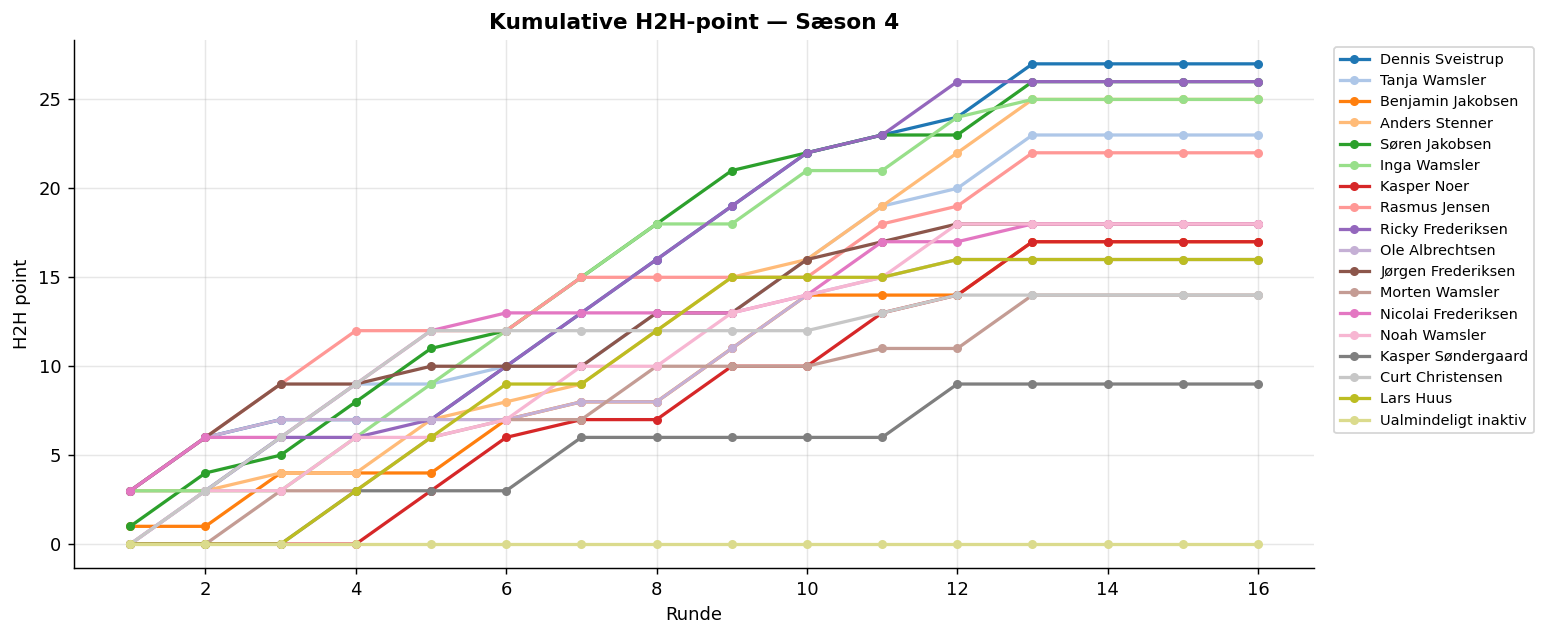

/tmp/ipykernel_1238/995480109.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.01,1),loc='upper left',fontsize=8)


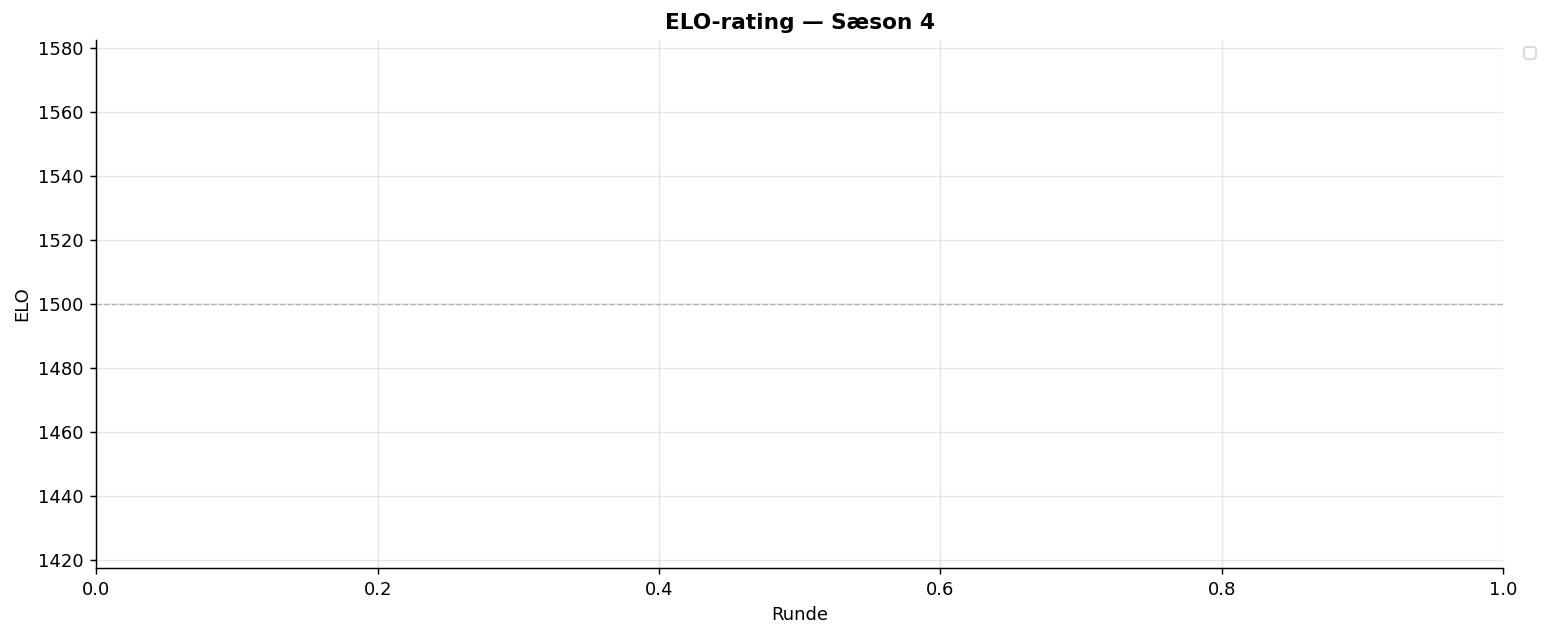

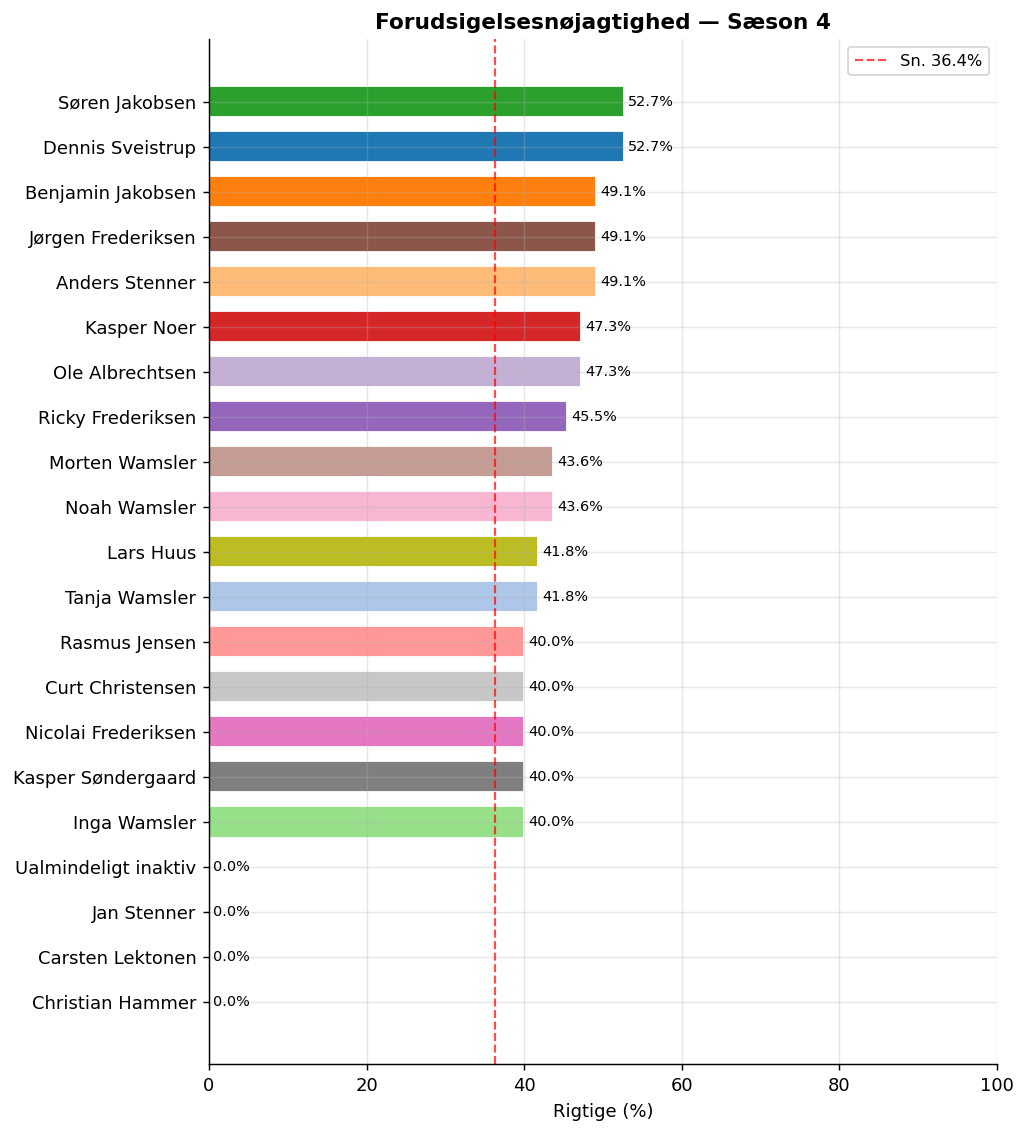

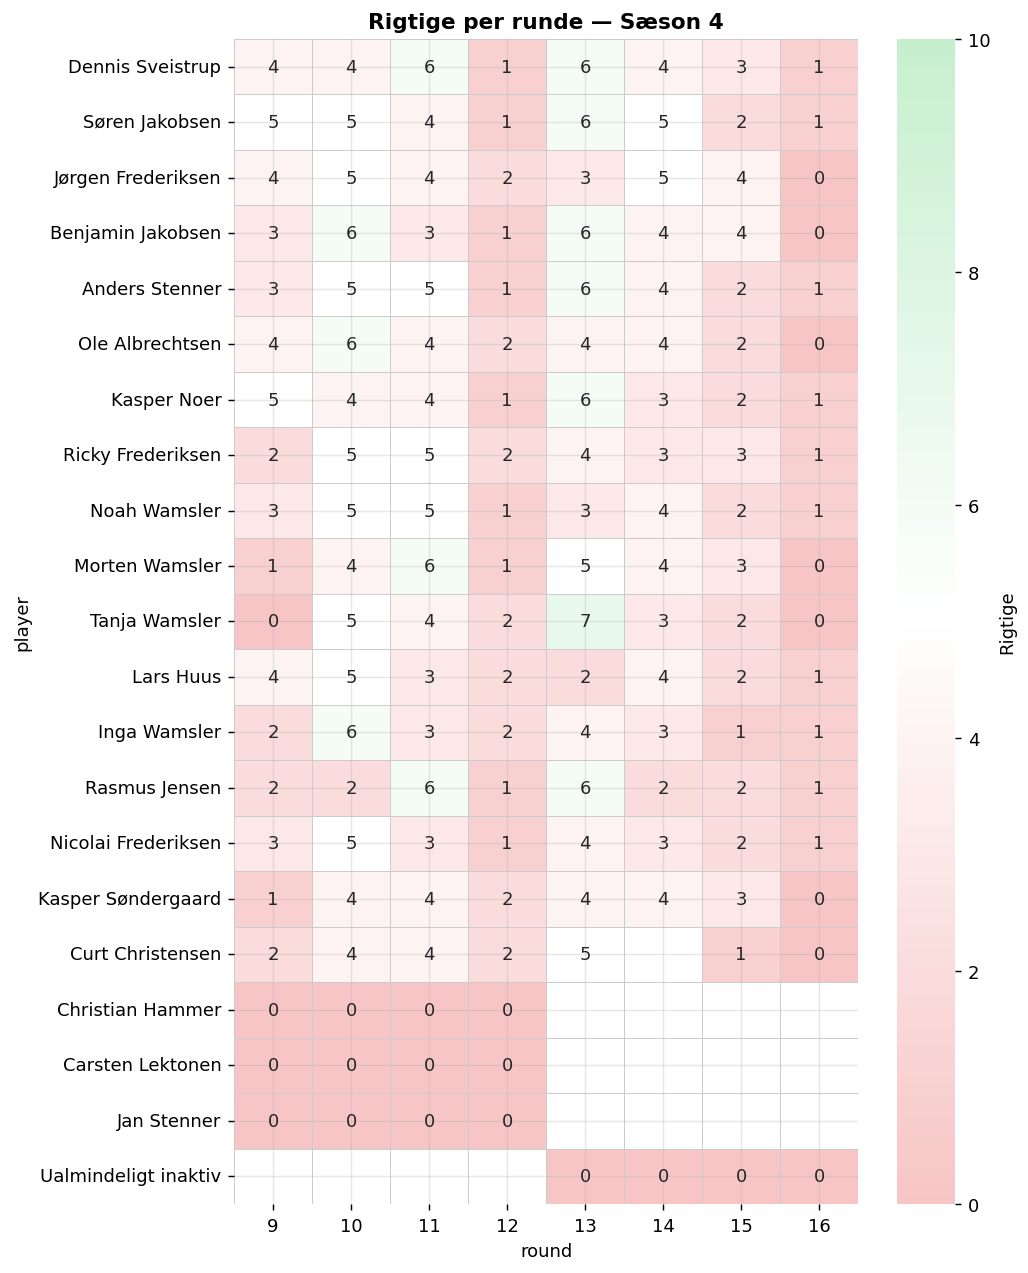

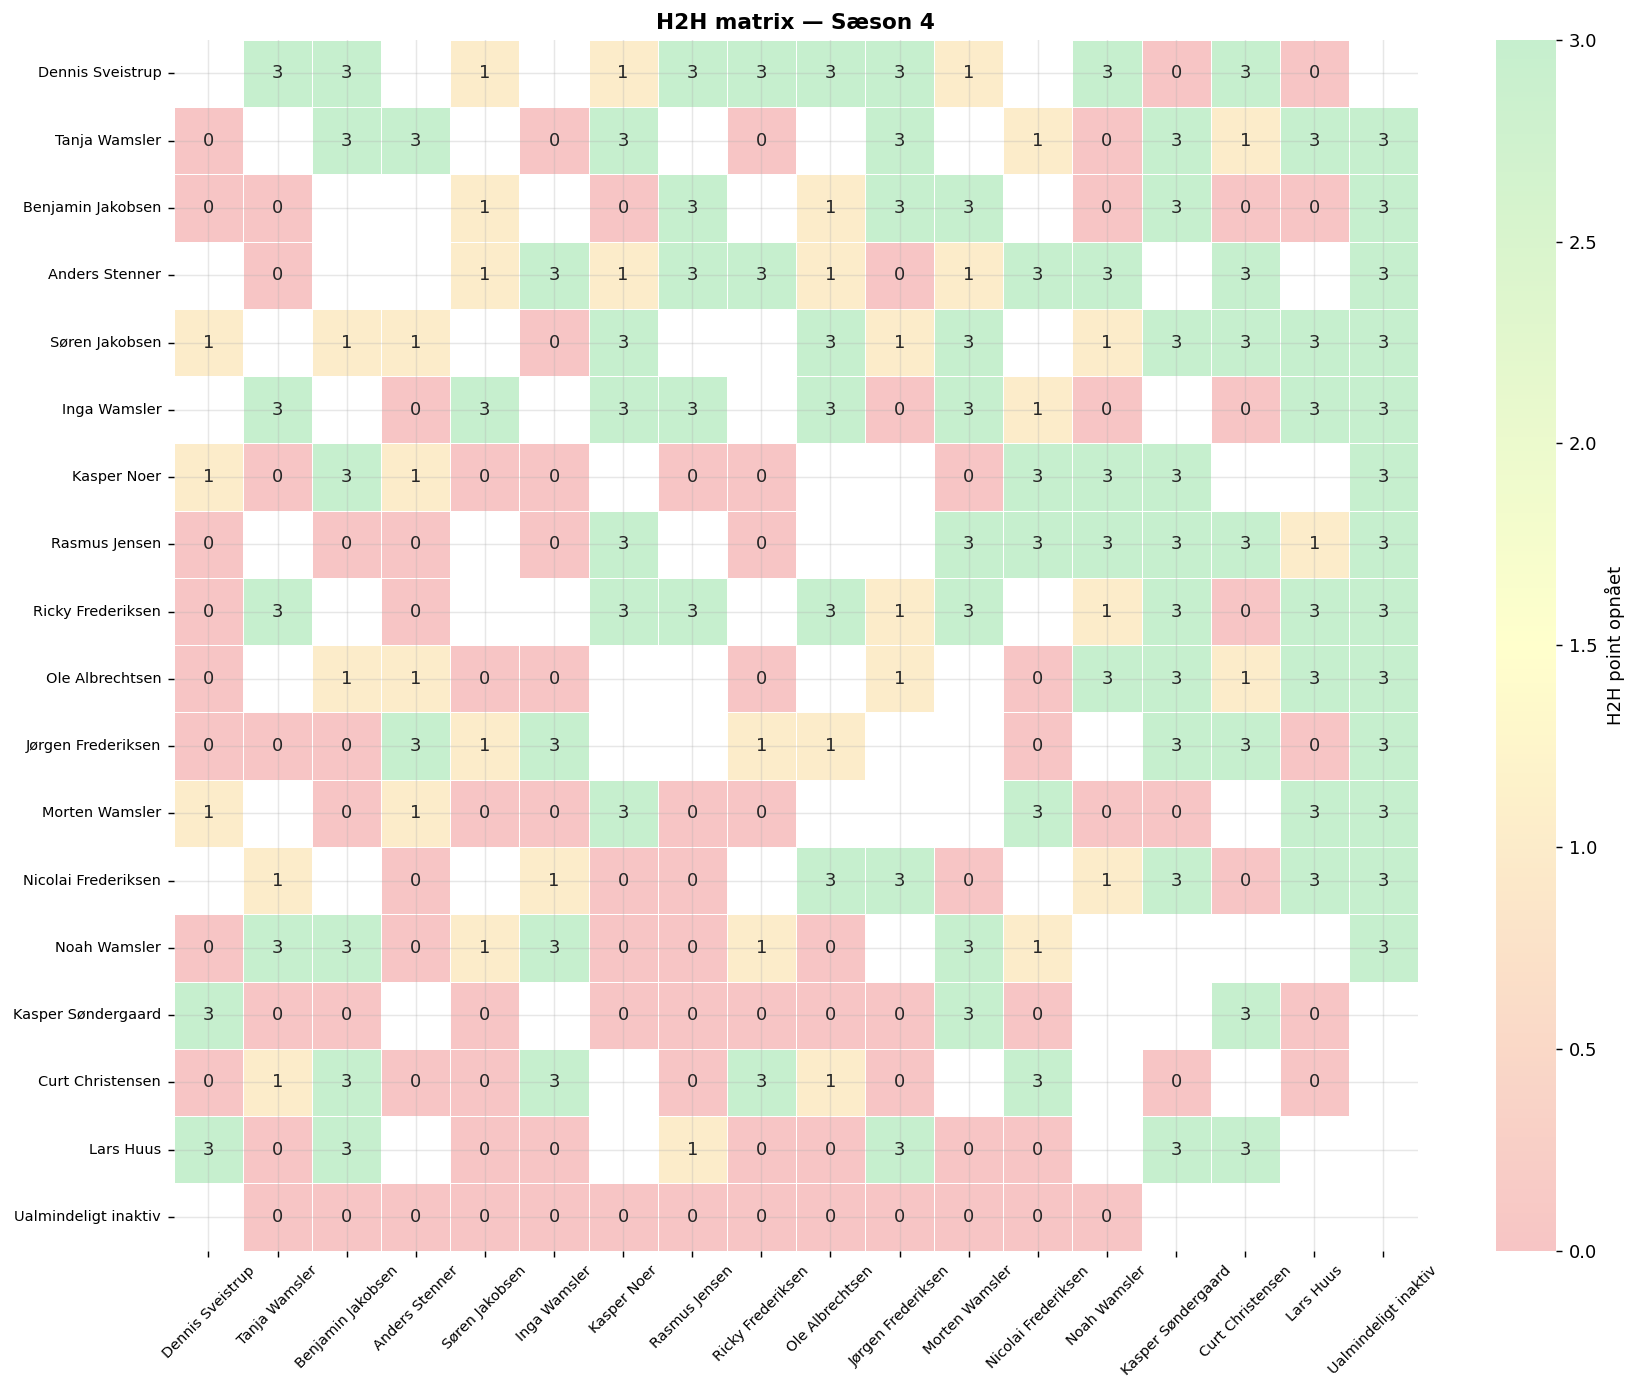


Form — seneste 5 runder:


round,12,13,14,15,16,Sn.
player,,,,,,
Benjamin Jakobsen,1,6,4,4,0,3.0
Søren Jakobsen,1,6,5,2,1,3.0
Dennis Sveistrup,1,6,4,3,1,3.0
Anders Stenner,1,6,4,2,1,2.8
Tanja Wamsler,2,7,3,2,0,2.8
Jørgen Frederiksen,2,3,5,4,0,2.8
Morten Wamsler,1,5,4,3,0,2.6
Kasper Søndergaard,2,4,4,3,0,2.6
Ricky Frederiksen,2,4,3,3,1,2.6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({'figure.dpi':130,'font.family':'sans-serif',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3})
PALETTE = sns.color_palette('tab20', 20)

df_std = pd.read_csv(STANDINGS_CSV)
df_std = df_std[df_std.season==CURRENT_SEASON]
df_pts = pd.read_csv(POINTS_CSV)
df_pts['season'] = df_pts['season'].astype(int)
df_pts = df_pts[df_pts.season==CURRENT_SEASON]
df_h2h = pd.read_csv(H2H_CSV)
df_h2h['season'] = df_h2h['season'].astype(int)
df_h2h = df_h2h[df_h2h.season==CURRENT_SEASON]
df_elo = pd.read_csv(ELO_CSV)
df_elo['season'] = df_elo['season'].astype(int)
df_elo = df_elo[df_elo.season==CURRENT_SEASON]

rounds_played  = sorted(df_pts['round'].unique())
players_sorted = df_std.sort_values('total_h2h_pts',ascending=False)['player'].tolist()
pcol = {p: PALETTE[i%20] for i,p in enumerate(players_sorted)}

# ── Stilling ──────────────────────────────────────────────────────────────
print(f'{"═"*72}')
print(f'  STILLING — Sæson {CURRENT_SEASON}')
print(f'{"═"*72}')
display(df_std.sort_values(['total_h2h_pts','total_correct'],ascending=False)
        .reset_index(drop=True)
        .rename(columns={'player':'Spiller','rounds_played':'Runder',
                         'total_correct':'Rigtige','avg_correct':'Sn./runde',
                         'total_h2h_pts':'H2H pts','elo':'ELO'})
        .style.background_gradient(subset=['H2H pts','Rigtige'],cmap='YlGn')
        .format({'Sn./runde':'{:.2f}','ELO':'{:.0f}'}))

# ── Kumulativ H2H ─────────────────────────────────────────────────────────
# Ensure df_h2h has the correct column names for player A and B points
# If 'player_a' column does not exist, but 'player1' does, rename.
# This handles the case where a previous run saved h2h.csv with 'player1'/'player2'
if 'player_a' not in df_h2h.columns and 'player1' in df_h2h.columns:
    df_h2h = df_h2h.rename(columns={'player1': 'player_a', 'player2': 'player_b'})

# Add h2h_pts_a and h2h_pts_b columns if they don't exist, filling with 0
# This prevents KeyError if no H2H data was generated in previous steps for the current season.
if 'h2h_pts_a' not in df_h2h.columns:
    df_h2h['h2h_pts_a'] = 0
if 'h2h_pts_b' not in df_h2h.columns:
    df_h2h['h2h_pts_b'] = 0

ra = df_h2h[['round','player_a','h2h_pts_a']].rename(
    columns={'player_a':'player','h2h_pts_a':'pts'})
rb = df_h2h[['round','player_b','h2h_pts_b']].rename(
    columns={'player_b':'player','h2h_pts_b':'pts'})

df_temp_cum = pd.concat([ra,rb]).sort_values('round')
df_temp_cum['pts'] = pd.to_numeric(df_temp_cum['pts'], errors='coerce').fillna(0)

df_cum = (df_temp_cum.groupby(['player','round'])['pts'].sum()
          .groupby('player').cumsum().reset_index()
          .rename(columns={'pts':'cum_pts'}))

fig, ax = plt.subplots(figsize=(12,5))
if not df_cum.empty:
    for p in players_sorted:
        s = df_cum[df_cum.player==p]
        if not s.empty:
            ax.plot(s['round'],s['cum_pts'],marker='o',ms=4,lw=1.8,color=pcol[p],label=p)
ax.set_title(f'Kumulative H2H-point — Sæson {CURRENT_SEASON}',fontweight='bold')
ax.set_xlabel('Runde'); ax.set_ylabel('H2H point')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
if not df_cum.empty:
    ax.legend(bbox_to_anchor=(1.01,1),loc='upper left',fontsize=8)
plt.tight_layout(); plt.show()

# ── ELO kurver ────────────────────────────────────────────────────────────
elo_lat = (df_elo.sort_values('round').groupby('player')['elo']
           .last().sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(12,5))
for p in elo_lat.index:
    s = df_elo[df_elo.player==p].sort_values('round')
    ax.plot(s['round'],s['elo'],marker='o',ms=3,lw=1.8,
            color=pcol.get(p,PALETTE[0]),label=f'{p} ({elo_lat[p]:.0f})')
ax.axhline(1500,color='grey',lw=0.8,ls='--',alpha=0.5)
ax.set_title(f'ELO-rating — Sæson {CURRENT_SEASON}',fontweight='bold')
ax.set_xlabel('Runde'); ax.set_ylabel('ELO')
ax.legend(bbox_to_anchor=(1.01,1),loc='upper left',fontsize=8)
plt.tight_layout(); plt.show()

# ── Nøjagtighed ───────────────────────────────────────────────────────────
acc = df_pts.groupby('player',as_index=False)['correct'].agg(total='sum',matches='count')
acc['pct'] = acc.total/acc.matches*100
acc = acc.sort_values('pct',ascending=True)
fig, ax = plt.subplots(figsize=(8,max(5,len(acc)*0.42)))
bars = ax.barh(acc.player,acc.pct,
               color=[pcol.get(p,PALETTE[0]) for p in acc.player],
               edgecolor='white',height=0.7)
for bar,v in zip(bars,acc.pct):
    ax.text(v+0.5,bar.get_y()+bar.get_height()/2,f'{v:.1f}%',va='center',fontsize=8)
ax.axvline(acc.pct.mean(),color='red',lw=1.2,ls='--',alpha=0.7,
           label=f'Sn. {acc.pct.mean():.1f}%')
ax.set_xlabel('Rigtige (%)'); ax.set_xlim(0,100)
ax.set_title(f'Forudsigelsesnøjagtighed — Sæson {CURRENT_SEASON}',fontweight='bold')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

# ── Heatmap per runde ────────────────────────────────────────────────────
pivot = (df_pts.groupby(['round','player'],as_index=False)['correct'].sum()
         .pivot(index='player',columns='round',values='correct'))
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
cmap = LinearSegmentedColormap.from_list('rg',['#f7c5c5','#ffffff','#c6efce'])
fig, ax = plt.subplots(figsize=(max(8,len(rounds_played)*0.9),
                                max(6,len(players_sorted)*0.55)))
sns.heatmap(pivot,ax=ax,annot=True,fmt='.0f',cmap=cmap,
            linewidths=0.4,linecolor='#cccccc',vmin=0,vmax=10,
            cbar_kws={'label':'Rigtige'})
ax.set_title(f'Rigtige per runde — Sæson {CURRENT_SEASON}',fontweight='bold')
ax.tick_params(axis='x',rotation=0); ax.tick_params(axis='y',rotation=0)
plt.tight_layout(); plt.show()

# ── H2H matrix ────────────────────────────────────────────────────────────
recs = {}
for _, row in df_h2h.iterrows():
    pa, pb = row.player_a, row.player_b
    recs.setdefault(pa,{}).setdefault(pb,0)
    recs.setdefault(pb,{}).setdefault(pa,0)
    recs[pa][pb] += row.h2h_pts_a
    recs[pb][pa] += row.h2h_pts_b
matrix = pd.DataFrame(
    [[recs.get(pa,{}).get(pb,None) for pb in players_sorted]
     for pa in players_sorted],
    index=players_sorted,columns=players_sorted,dtype=float)
for p in players_sorted: matrix.loc[p,p] = float('nan')
cmap2 = LinearSegmentedColormap.from_list('rg',['#f7c5c5','#ffffcc','#c6efce'])
fig, ax = plt.subplots(figsize=(max(8,len(players_sorted)*0.75),
                                max(6,len(players_sorted)*0.6)))
sns.heatmap(matrix,ax=ax,annot=True,fmt='.0f',cmap=cmap2,
            linewidths=0.5,vmin=0,vmax=3,mask=matrix.isna(),
            cbar_kws={'label':'H2H point opnået'})
ax.set_title(f'H2H matrix — Sæson {CURRENT_SEASON}',fontweight='bold')
ax.tick_params(axis='x',rotation=45,labelsize=8)
ax.tick_params(axis='y',rotation=0,labelsize=8)
plt.tight_layout(); plt.show()

# ── Form: seneste 5 runder ────────────────────────────────────────────────
last5 = sorted(rounds_played)[-5:]
form = (df_pts[df_pts['round'].isin(last5)]
        .groupby(['round','player'],as_index=False)['correct'].sum())
pf = form.pivot(index='player',columns='round',values='correct')
pf['Sn.'] = pf.mean(axis=1).round(1)
pf = pf.sort_values('Sn.',ascending=False)
print(f'\nForm — seneste {len(last5)} runder:')
display(pf.style
        .background_gradient(subset=pf.columns[:-1],cmap='RdYlGn',vmin=0,vmax=10)
        .format('{:.0f}',subset=pf.columns[:-1])
        .format('{:.1f}',subset=['Sn.']))

---
## 07 — Historisk import fra Excel

**Kør kun én gang.** Importerer historiske data fra Excel-workbooken til CSV.

Opretter:
- `hist_matches.csv` — alle 1620 historiske kampe (sæson 1-3)
- `hist_odds.csv` — bookmaker-odds per kamp
- `hist_predictions.csv` — spillerforudsigelser med korrekt/forkert flag
- `player_stats.csv` — aggregerede spillerstatistikker

**Excel-encoding:** `1`=hjemmesejr, `9`=uafgjort, `2`=udesejr → konverteres til `1`/`X`/`2`

### 07-A — Upload Excel-fil (historiske data)

In [ ]:
# ── 07-A  Upload Excel-fil ───────────────────────────────────────────────
EXCEL_PATH = '/content/drive/MyDrive/fodboldquiz/Oddsklub egen oversigt.xlsx'

# Alternativt — upload direkte fra computer:
# from google.colab import files
# uploaded = files.upload()
# EXCEL_PATH = list(uploaded.keys())[0]

if not os.path.exists(EXCEL_PATH):
    print(f'⚠️  Fil ikke fundet: {EXCEL_PATH}')
    print('Ret EXCEL_PATH ovenfor, eller kør upload-kommandoen.')
else:
    print(f'✅ Fil fundet: {EXCEL_PATH}')


✅ Fil fundet: /content/drive/MyDrive/fodboldquiz/Oddsklub egen oversigt.xlsx


In [ ]:
import openpyxl
import os

# Define EXCEL_PATH locally for robustness
EXCEL_PATH = '/content/drive/MyDrive/fodboldquiz/Oddsklub egen oversigt.xlsx'

xl = None # Initialize xl to None
if not os.path.exists(EXCEL_PATH):
    print(f'⚠️  Fil ikke fundet: {EXCEL_PATH}')
    print('Ret EXCEL_PATH ovenfor, eller kør upload-kommandoen.')
else:
    xl = pd.ExcelFile(EXCEL_PATH) # Load Excel file if it exists

# ── SPRING OVER hvis CSV-filerne allerede er opdaterede ──────────────────
# Sæt FORCE_REBUILD = True for at genindlæse Excel (f.eks. ved sæsonstart)
FORCE_REBUILD = False

_need_rebuild = (
    FORCE_REBUILD or
    not os.path.exists(HIST_MATCHES) or
    not os.path.exists(HIST_ODDS) or
    os.path.getsize(HIST_MATCHES) < 1000
)

if xl is None: # If xl could not be loaded, we can't proceed with rebuild logic.
    pass # No Excel, so no rebuild from Excel possible, and _need_rebuild logic won't save it.
elif not _need_rebuild:
    print('✅ Springer 07 over — CSV-filerne er allerede klar.')
    print('   Sæt FORCE_REBUILD = True for at genindlæse Excel.')
    # df_mo is only used if rebuild is needed, so it can remain None here.
    df_mo = None
    df_hist_matches = pd.read_csv(HIST_MATCHES)
    print(f'   hist_matches.csv: {len(df_hist_matches)} rækker (from cache)')
else: # _need_rebuild is True
    # The original intent was to load df_mo ONLY if rebuild was needed. This still holds.
    df_mo = pd.read_excel(xl, sheet_name='MasterOversigt')
    print(f'MasterOversigt: {df_mo.shape[0]} rækker') # Moved this line into the else block

def excel_result_to_1x2(v):
    if pd.isna(v): return None
    v_str = str(v).strip()
    if v_str == '1' or v == 1: return '1'
    if v_str == 'X' or v == 9: return 'X'
    if v_str == '2' or v == 2: return '2'
    return None

def make_match_id(season, runde, kamp):
    return f's{int(season)}_r{int(runde):02d}_{str(kamp).strip()}'

if _need_rebuild:
    rows = []
    for _, r in df_mo.iterrows():
        if pd.isna(r.get('Runde')) or pd.isna(r.get('Sæson')): continue
        rows.append({
            'match_id':       make_match_id(r['Sæson'], r['Runde'], r['Kamp']),
            'season':         int(r['Sæson']),
            'round':          int(r['Runde']),
            'match_code':     str(r['Kamp']).strip(),
            'league':         str(r.get('Kamptype','')),
            'home_team':      str(r['Hjemmehold']),
            'away_team':      str(r['Udehold']),
            'result':         excel_result_to_1x2(r['Resultat']),
            'elo_home':       r.get('ELO_Hjemme') if pd.notna(r.get('ELO_Hjemme')) else None,
            'elo_away':       r.get('ELO_Ude')    if pd.notna(r.get('ELO_Ude'))    else None,
            'avg_implied_1':  r.get('Odds1') if pd.notna(r.get('Odds1')) else None,
            'avg_implied_x':  r.get('Odds9') if pd.notna(r.get('Odds9')) else None,
            'avg_implied_2':  r.get('Odds2') if pd.notna(r.get('Odds2')) else None,
        })

    df_hist_matches = pd.DataFrame(rows)
    df_hist_matches.to_csv(HIST_MATCHES, index=False)
    print(f'✅ hist_matches.csv: {len(df_hist_matches)} kampe')
    print(f'   Sæsoner: {sorted(df_hist_matches.season.unique())}')
    print(f'   Resultater: {df_hist_matches.result.value_counts().to_dict()}')
    display(df_hist_matches.head(5))

    # ── 07-D  Generer ELO historie (elo_history.csv) ─────────────────────────
    # Opretter elo_history.csv fra de historiske kampdata (elo_home/elo_away).
    # Dette antager, at ELO-værdierne i MasterOversigt afspejler spillernes ELO i den pågældende runde.

    elo_history_rows = []
    for _, row in df_hist_matches.iterrows():
        season = row['season']
        rnd = row['round']
        if pd.notna(row['elo_home']) and row['home_team']:
            elo_history_rows.append({
                'season': int(season),
                'round': int(rnd),
                'player': str(row['home_team']),
                'elo': float(row['elo_home'])
            })
        if pd.notna(row['elo_away']) and row['away_team']:
            elo_history_rows.append({
                'season': int(season),
                'round': int(rnd),
                'player': str(row['away_team']),
                'elo': float(row['elo_away'])
            })

    # Skab DataFrame og fjern potentielle duplikater (hvis en spiller har flere kampe i samme runde)
    # Her tages den sidste ELO-værdi for en spiller i en given runde.
    df_elo_history = pd.DataFrame(elo_history_rows)
    if not df_elo_history.empty:
        df_elo_history = df_elo_history.sort_values(by=['season', 'round', 'player'])
        df_elo_history = df_elo_history.drop_duplicates(subset=['season', 'round', 'player'], keep='last')
        df_elo_history.to_csv(ELO_CSV, index=False)
        print(f'✅ elo_history.csv: {len(df_elo_history)} rækker gemt.')
    else:
        print(f'⚠ elo_history.csv: Ingen ELO-data fundet at gemme.')

✅ Springer 07 over — CSV-filerne er allerede klar.
   Sæt FORCE_REBUILD = True for at genindlæse Excel.
   hist_matches.csv: 1620 rækker (from cache)


### 07-C — Historiske odds (hist\_odds.csv)

In [ ]:
# ── 07-C  Historiske odds (hist_odds.csv) ────────────────────────────────
if not _need_rebuild:
    print('✅ 07-C sprunget over (cache)')
else:
    df_odds_raw = pd.read_excel(xl, sheet_name='Odds')
    print(f'Odds-ark: {df_odds_raw.shape[0]} rækker')

    def norm_bookmaker(b):
        if pd.isna(b): return None
        b = str(b).strip().lower()
        if b in ('ds','danishsuperbet'): return 'DS'
        if 'bet365' in b:  return 'Bet365'
        if 'pinnacle' in b: return 'Pinnacle'
        if 'nordic' in b:  return 'Nordic Bet'
        if 'unibet' in b:  return 'Unibet'
        if 'betclic' in b: return 'Betclic'
        if '1xbet' in b:   return '1xBet'
        if 'betsson' in b: return 'Betsson'
        if 'bwin' in b:    return 'Bwin'
        if 'forebet' in b: return None   # sandsynligheder, ikke odds
        return str(b).strip().title()

    odds_rows = []
    for _, r in df_odds_raw.iterrows():
        if pd.isna(r.get('Sæson')) or pd.isna(r.get('Kamp')): continue
        bookie = norm_bookmaker(r.get('Bookie'))
        if not bookie: continue
        h1 = r.get('Odds - 1')
        hx = r.get('Odds - 9')
        h2 = r.get('Odds -2')
        odds_rows.append({
            'match_id':   make_match_id(r['Sæson'], r['Runde'], r['Kamp']),
            'season':     int(r['Sæson']),
            'round':      int(r['Runde']),
            'match_code': str(r['Kamp']).strip(),
            'bookmaker':  bookie,
            'home_odds':  float(h1) if pd.notna(h1) else None,
            'draw_odds':  float(hx) if pd.notna(hx) else None,
            'away_odds':  float(h2) if pd.notna(h2) else None,
        })

    df_hist_odds = pd.DataFrame(odds_rows)
    df_hist_odds.to_csv(HIST_ODDS, index=False)
    print(f'✅ hist_odds.csv: {len(df_hist_odds)} rækker')
    print(f'   Bookmakers: {sorted(df_hist_odds.bookmaker.unique()[:12])}')
    display(df_hist_odds.head(5))


✅ 07-C sprunget over (cache)


In [ ]:
# ACTIVE_PLAYERS synkroniseres med PLAYERS (defineret i 03-A)
# Brug PLAYERS direkte for at undgå to lister der divergerer
ACTIVE_PLAYERS = PLAYERS

df_pp  = pd.read_excel(xl, sheet_name='PersonerPoint')
df_per = pd.read_excel(xl, sheet_name='Personer')
df_pp['season']  = df_pp['Sæson'].fillna(0).astype(int)
df_pp['round']   = df_pp['Runde'].fillna(0).astype(int)
df_per['season'] = df_per['Sæson'].fillna(0).astype(int)
df_per['round']  = df_per['Runde'].fillna(0).astype(int)

pred_rows = []
for _, r_pp in df_pp[df_pp.season>=1].iterrows():
    kamp    = str(r_pp['Kamp']).strip() if pd.notna(r_pp.get('Kamp')) else None
    if not kamp or kamp=='nan': continue
    resultat = excel_result_to_1x2(r_pp.get('Resultat'))
    match_id = make_match_id(r_pp['season'], r_pp['round'], kamp)

    # Ensure 'Kamp - master' is not NaN before stripping and comparing
    # Convert both to string and strip for robust comparison
    per_master_clean = df_per['Kamp - master'].fillna('').astype(str).str.strip()
    kamp_clean = str(kamp).strip()

    per_mask = ((df_per.season==r_pp['season'])&
                (df_per.round==r_pp['round'])&
                (per_master_clean==kamp_clean))
    per_row = df_per[per_mask]

    for player in ACTIVE_PLAYERS:
        correct_val = r_pp.get(player)
        if pd.isna(correct_val): continue
        correct = int(correct_val)
        pred_val = None
        if not per_row.empty:
            raw = per_row.iloc[0].get(player)
            if pd.notna(raw) and str(raw).strip() not in ('', ' '):
                pred_val = excel_result_to_1x2(raw)
        pred_rows.append({
            'match_id':   match_id,
            'season':     r_pp['season'],
            'round':      r_pp['round'],
            'match_code': kamp,
            'player':     player,
            'prediction': pred_val,
            'correct':    correct,
            'result':     resultat,
        })

df_hist_preds = pd.DataFrame(pred_rows)
df_hist_preds.to_csv(HIST_PREDS, index=False)
print(f'✅ hist_predictions.csv: {len(df_hist_preds)} rækker')
print(f'   Sæsoner: {sorted(df_hist_preds.season.unique())}')

acc = (df_hist_preds.groupby('player',as_index=False)['correct']
       .agg(rigtige='sum',kampe='count'))
acc['pct'] = (acc.rigtige/acc.kampe*100).round(1)
print('Historisk nøjagtighed:')
display(acc.sort_values('pct',ascending=False).reset_index(drop=True))

✅ hist_predictions.csv: 27848 rækker
   Sæsoner: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Historisk nøjagtighed:


,player,rigtige,kampe,pct
0,Søren Jakobsen,845,1717,49.2
1,Anders Stenner,834,1732,48.2
2,Dennis Sveistrup,828,1732,47.8
3,Ricky Frederiksen,826,1727,47.8
4,Inga Wamsler,808,1732,46.7
5,Noah Wamsler,801,1732,46.2
6,Morten Wamsler,800,1732,46.2
7,Lars Huus,765,1732,44.2
8,Curt Christensen,733,1722,42.6
9,Nicolai Frederiksen,734,1722,42.6


### 07-E — Spillerstatistik (player\_stats.csv)

In [ ]:
# ── 07-E  Spillerstatistik (player_stats.csv) ─────────────────────────────
if not _need_rebuild:
    print('✅ 07-E sprunget over (cache)')
else:
    df_hp = pd.read_csv(HIST_PREDS)
    def compute_player_stats(df):
        stats = []
        for player, grp in df.groupby('player'):
            grp = grp.dropna(subset=['prediction'])
            if grp.empty: continue
            total   = len(grp)
            correct = grp['correct'].sum()
            by_pred = grp['prediction'].value_counts(normalize=True)
            grp_res = grp.dropna(subset=['correct']).sort_values(['season','round'])
            last10  = grp_res.tail(10)['correct'].mean() if len(grp_res)>=10 else None
            last20  = grp_res.tail(20)['correct'].mean() if len(grp_res)>=20 else None
            by_res  = grp.groupby('result')['correct'].mean()
            stats.append({
                'player':        player,
                'total_preds':   total,
                'total_correct': int(correct),
                'accuracy':      round(correct/total, 4) if total else None,
                'home_rate':     round(by_pred.get('1', 0), 3),
                'draw_rate':     round(by_pred.get('X', 0), 3),
                'away_rate':     round(by_pred.get('2', 0), 3),
                'last10_acc':    round(last10, 3) if last10 is not None else None,
                'last20_acc':    round(last20, 3) if last20 is not None else None,
                'acc_on_1':      round(by_res.get('1', 0), 3),
                'acc_on_x':      round(by_res.get('X', 0), 3),
                'acc_on_2':      round(by_res.get('2', 0), 3),
            })
        return pd.DataFrame(stats)

    df_pstats = compute_player_stats(df_hp)
    df_pstats.to_csv(PLAYER_STATS, index=False)
    print(f'✅ player_stats.csv: {len(df_pstats)} spillere')
    pct_cols = ['accuracy','home_rate','draw_rate','away_rate',
                'last10_acc','last20_acc','acc_on_1','acc_on_x','acc_on_2']
    # Only attempt to display if df_pstats is not empty and 'accuracy' column exists
    if not df_pstats.empty and 'accuracy' in df_pstats.columns:
        display(df_pstats.sort_values('accuracy',ascending=False)
                .reset_index(drop=True)
                .style.format({c:'{:.1%}' for c in pct_cols if c in df_pstats.columns}))
    else:
        print("  Ingen spillerstatistikker at vise (enten tom eller mangler 'accuracy' kolonne).")

✅ 07-E sprunget over (cache)


---
## 07-F — Holdmapping fra Excel

**Kør ved sæsonstart** — læser forkortelserne fra Hold-fanen i Excel-filen på Drive.  
Ingen manuel upload nødvendig — finder automatisk filen på dit Drive.

Hvis cellen ikke finder filen, sæt `EXCEL_PATH_OVERRIDE` til den præcise sti.


In [ ]:
import openpyxl, json, os, glob

# DATA_DIR er defineret i celle 01-A

# --- Define load_hold_mapping function ---
def load_hold_mapping(path):
    mapping = {}
    try:
        with open(path, encoding='utf-8') as f:
            for entry in json.load(f):
                _n = str(entry.get('name','')).strip().lower()
                _a = str(entry.get('abbr','')).strip()
                if _n and _a:
                    mapping[_n] = _a
        return mapping
    except Exception as e:
        print(f'  ⚠ Fejl ved indlæsning af hold_mapping.json fra {path}: {e}')
        return {}
# --- End define load_hold_mapping function ---

# ── Find Excel-filen på Drive ─────────────────────────────────────────────
DRIVE_ROOT = '/content/drive/MyDrive'

# Søg automatisk efter xlsx-filen på Drive
EXCEL_CANDIDATES = [
    # Tilføj den præcise sti her hvis du kender den:
    os.path.join(DRIVE_ROOT, 'Oddsklub_egen_oversigt.xlsx'),
    os.path.join(DRIVE_ROOT, 'fodboldquiz', 'Oddsklub_egen_oversigt.xlsx'),
    os.path.join(DRIVE_ROOT, 'fodboldquiz', 'data', 'Oddsklub_egen_oversigt.xlsx'),
]

# Ellers: søg i hele Drive (langsommere)
EXCEL_PATH_OVERRIDE = None  # Sæt til f.eks. '/content/drive/MyDrive/Min mappe/fil.xlsx'

def find_excel_on_drive():
    if EXCEL_PATH_OVERRIDE:
        return EXCEL_PATH_OVERRIDE
    for path in EXCEL_CANDIDATES:
        if os.path.exists(path):
            print(f'  Fandt: {path}')
            return path
    # Bred søgning
    print('  Søger i hele Drive...')
    hits = glob.glob(os.path.join(DRIVE_ROOT, '**', 'Oddsklub*.xlsx'), recursive=True)
    if hits:
        print(f'  Fandt: {hits[0]}')
        return hits[0]
    hits = glob.glob(os.path.join(DRIVE_ROOT, '**', '*oddsklub*.xlsx'), recursive=True)
    if hits:
        print(f'  Fandt: {hits[0]}')
        return hits[0]
    return None

excel_path = find_excel_on_drive()
if not excel_path:
    raise FileNotFoundError(
        "Excel-filen blev ikke fundet på Drive.\n"
        "  Sæt EXCEL_PATH_OVERRIDE til den præcise sti ovenfor,\n"
        "  eller kopier filen til: /content/drive/MyDrive/Oddsklub_egen_oversigt.xlsx"
    )

# ── Læs Hold-fanen Q:U ───────────────────────────────────────────────────
print(f'Læser: {excel_path}')
wb = openpyxl.load_workbook(excel_path, data_only=True, read_only=True)
ws = wb['Hold']

rows = []
for row in ws.iter_rows(min_row=2, max_col=21, values_only=True):
    q, r, s, t, u = row[16], row[17], row[18], row[19], row[20]
    if t and q:
        rows.append({
            'abbr':     str(q).strip(),
            'type':     str(r).strip() if r else '',
            'land':     str(s).strip() if s else '',
            'name':     str(t).strip(),
            'elo_name': str(u).strip() if u else '',
        })

wb.close()

out_path = os.path.join(DATA_DIR, 'hold_mapping.json')
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(rows, f, ensure_ascii=False, indent=2)

print(f'✅ Gemt {len(rows)} hold-forkortelser → {out_path}')

# Genindlæs i session
HOLD_MAPPING = load_hold_mapping(out_path)

# ── Overrides: sikrer at Oddsklub-forkortelsen (arket) altid vinder ────
# Tilføj nye hold herunder hvis der opstår navnekonflikter fremover.
# Format: HOLD_MAPPING['fuldt holdnavn lowercase'] = 'XXX'
HOLD_MAPPING['strasbourg']         = 'STB'  # arket: STB (ikke RCS)
HOLD_MAPPING['rc strasbourg']      = 'STB'
HOLD_MAPPING['racing strasbourg']  = 'STB'
HOLD_MAPPING['fc strasbourg']      = 'STB'
HOLD_MAPPING['rayo vallecano']     = 'VAL'
HOLD_MAPPING['vallecano']          = 'VAL'
HOLD_MAPPING['rayo']               = 'VAL'
HOLD_MAPPING['Lokomotive Leipzig']               = 'LEI'
HOLD_MAPPING['RW Essen']               = 'RWE'
HOLD_MAPPING['Würzburger Kickers']               = 'WÜK'
HOLD_MAPPING [ 'Sydafrika'] = 'RSA'
HOLD_MAPPING['Sydkorea'] = 'SYK'





# Tilføjet efter brugerens ønske:
HOLD_MAPPING['royale union sg']    = 'USG'
HOLD_MAPPING['fc københavn']       = 'FCK'

print(f'   HOLD_MAPPING: {len(HOLD_MAPPING)} unikke holdnavne klar (med overrides)')

# Vis konflikter
from collections import defaultdict
conf = defaultdict(list)
for r in rows:
    conf[r['abbr']].append(r['name'])
conflicts = {k: list(dict.fromkeys(v)) for k, v in conf.items() if len(set(v)) > 1}
if conflicts:
    print(f'\n  ⚠ Forkortelse-konflikter ({len(conflicts)} stk.):')
    for k, v in conflicts.items():
        print(f'    {k}: {v}')






  Søger i hele Drive...
  Fandt: /content/drive/MyDrive/fodboldquiz/Oddsklub egen oversigt.xlsx
Læser: /content/drive/MyDrive/fodboldquiz/Oddsklub egen oversigt.xlsx
✅ Gemt 640 hold-forkortelser → /content/drive/MyDrive/fodboldquiz/data/hold_mapping.json
   HOLD_MAPPING: 575 unikke holdnavne klar (med overrides)

  ⚠ Forkortelse-konflikter (7 stk.):
    LEV: ['Bayer Leverkusen', 'Leverkusen']
    BUR: ['Burnley', 'Burton']
    CMB: ['Colombia', 'Columbia']
    HON: ['Honduras', 'Honka']
    LEI: ['Leicester', 'Lokomotive Leipizig']
    PAN: ['Panama', 'Panathinaikos']
    RWE: ['Rot Weiss Essen', 'RW Essen']


### 07-FDC — Football-Data.co.uk (træningsdata + Poisson-parametre)
*Kør én gang ved sæsonstart. Gemmer til `fdc_goals.csv` og `model_params.json` — aldrig til odds.csv eller andre live-ark.*

In [ ]:
# ── 07-FDC  Football-Data.co.uk + Poisson-parameterfit ─────────────────────
# Henter historiske mål-data (FTHG/FTAG) for de ligaer vi bruger.
# Fitter holdspecifikke angreb/forsvar-parametre via MLE med recency-decay.
# Output (TRÆNINGSDATA — ikke live):
#   data/fdc_goals.csv     → rå historiske kampe
#   data/model_params.json → fittede Poisson-parametre pr. liga

import requests, io, os, json
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.optimize import minimize

FDC_GOALS_CSV = os.path.join(DATA_DIR, 'fdc_goals.csv')
MODEL_PARAMS_JSON = os.path.join(DATA_DIR, 'model_params.json')

# Ligaer der dækker vores typiske runder
FDC_LEAGUES = {
    'E0': 'Premier League',   'E1': 'Championship',
    'D1': 'Bundesliga',        'D2': '2. Bundesliga',
    'SP1': 'La Liga',          'SP2': 'La Liga 2',
    'F1': 'Ligue 1',           'I1': 'Serie A',
    'N1': 'Eredivisie',        'B1': 'Belgian Pro League',
    'P1': 'Primeira Liga',     'G1': 'Super League (GR)',
    'T1': 'Süper Lig',
}
FDC_SEASONS = ['2223', '2324', '2425']   # 3 sæsoner = god stikprøve
DECAY_DAYS  = 200   # halveringskonstant: nyere kampe vægter mere
MIN_TEAM_GAMES = 15  # hold med færre end dette spring over

# ── 1. Download ────────────────────────────────────────────────────────────
print('📥 Downloader Football-Data.co.uk...')
frames = []; ok = 0; skip = 0

for season in FDC_SEASONS:
    for code in FDC_LEAGUES:
        url = f'https://www.football-data.co.uk/mmz4281/{season}/{code}.csv'
        try:
            r = requests.get(url, timeout=15)
            if r.status_code != 200: skip += 1; continue
            df = pd.read_csv(io.StringIO(r.content.decode('latin1')),
                             on_bad_lines='skip', low_memory=False)
            needed = ['HomeTeam','AwayTeam','FTHG','FTAG']
            if not all(c in df.columns for c in needed): skip += 1; continue
            df = df[['Div','Date','HomeTeam','AwayTeam','FTHG','FTAG']].copy()
            df['FTHG'] = pd.to_numeric(df['FTHG'], errors='coerce')
            df['FTAG'] = pd.to_numeric(df['FTAG'], errors='coerce')
            df = df.dropna(subset=['FTHG','FTAG','HomeTeam','AwayTeam'])
            df['season_fdc'] = season; df['league_fdc'] = code
            frames.append(df); ok += 1
        except Exception as e:
            skip += 1

if not frames:
    print('❌ Ingen data hentet — tjek internetforbindelsen')
else:
    fdc = pd.concat(frames, ignore_index=True)
    fdc['Date'] = pd.to_datetime(fdc['Date'], dayfirst=True, errors='coerce')
    fdc = fdc.dropna(subset=['Date'])
    fdc.to_csv(FDC_GOALS_CSV, index=False, encoding='utf-8')
    print(f'  ✅ {ok} filer hentet, {skip} sprunget over')
    print(f'  📊 {len(fdc):,} kampe → {os.path.basename(FDC_GOALS_CSV)}')
    print(f'  Periode: {fdc.Date.min().date()} → {fdc.Date.max().date()}')
    print()

    # ── 2. Fit Poisson-parametre pr. liga ──────────────────────────────────
    print('⚙ Fitter Poisson-parametre...')
    max_date = fdc['Date'].max()
    all_params = {}

    for league_code in sorted(fdc['league_fdc'].unique()):
        df_l = fdc[fdc['league_fdc'] == league_code].copy()
        df_l['days_ago'] = (max_date - df_l['Date']).dt.days
        df_l['w'] = np.exp(-df_l['days_ago'] / DECAY_DAYS)

        # Kun hold med nok kampe
        cnt = pd.concat([df_l.HomeTeam, df_l.AwayTeam]).value_counts()
        teams = sorted(t for t in cnt.index if cnt[t] >= MIN_TEAM_GAMES)
        if len(teams) < 6: continue
        df_l = df_l[df_l.HomeTeam.isin(teams) & df_l.AwayTeam.isin(teams)]

        ti = {t: i for i, t in enumerate(teams)}
        H  = np.array([ti[t] for t in df_l.HomeTeam])
        A  = np.array([ti[t] for t in df_l.AwayTeam])
        hg = df_l.FTHG.values.astype(float)
        ag = df_l.FTAG.values.astype(float)
        w  = df_l.w.values
        n  = len(teams)

        def _neg_ll(x, H=H, A=A, hg=hg, ag=ag, w=w, n=n):
            log_home = x[0]
            atk = x[1:1+n]; dfn = x[1+n:]
            lh = np.exp(log_home + atk[H] - dfn[A])
            la = np.exp(           atk[A] - dfn[H])
            lh = np.maximum(lh, 0.02); la = np.maximum(la, 0.02)
            return -(w * (hg*np.log(lh) - lh + ag*np.log(la) - la)).sum()

        try:
            res = minimize(_neg_ll, np.zeros(1+2*n), method='L-BFGS-B',
                           options={'maxiter':400, 'ftol':1e-9})
            atk = res.x[1:1+n] - res.x[1:1+n].mean()  # re-center
            dfn = res.x[1+n:]  - res.x[1+n:].mean()
            home_adv = float(np.exp(res.x[0]))

            all_params[league_code] = {
                'home_adv':       home_adv,
                'avg_goals_home': float(df_l.FTHG.mean()),
                'avg_goals_away': float(df_l.FTAG.mean()),
                'teams':          teams,
                'attack':         {t: float(atk[i]) for t,i in ti.items()},
                'defense':        {t: float(dfn[i]) for t,i in ti.items()},
                'fitted_date':    datetime.now().strftime('%Y-%m-%d'),
                'n_matches':      int(len(df_l)),
            }
            print(f'  ✅ {league_code:4} ({FDC_LEAGUES.get(league_code,"?"):22}) '
                  f'{len(teams):>3} hold, {len(df_l):>4} kampe')
        except Exception as e:
            print(f'  ⚠ {league_code}: fit fejlede ({e})')

    with open(MODEL_PARAMS_JSON, 'w', encoding='utf-8') as f:
        json.dump(all_params, f, ensure_ascii=False, indent=2)
    print(f'')
    print(f'✅ {len(all_params)} ligaer gemt → {os.path.basename(MODEL_PARAMS_JSON)}')
    print('   Kør nu celle 02-F for at generere Poisson-forudsigelser.')

📥 Downloader Football-Data.co.uk...
  ✅ 26 filer hentet, 13 sprunget over
  📊 9,262 kampe → fdc_goals.csv
  Periode: 2022-07-15 → 2024-06-02

⚙ Fitter Poisson-parametre...
  ✅ B1   (Belgian Pro League    )  19 hold,  618 kampe
  ✅ D1   (Bundesliga            )  20 hold,  612 kampe
  ✅ D2   (2. Bundesliga         )  23 hold,  612 kampe
  ✅ E0   (Premier League        )  23 hold,  760 kampe
  ✅ E1   (Championship          )  30 hold, 1104 kampe
  ✅ F1   (Ligue 1               )  22 hold,  686 kampe
  ✅ G1   (Super League (GR)     )  16 hold,  480 kampe
  ✅ I1   (Serie A               )  23 hold,  760 kampe
  ✅ N1   (Eredivisie            )  21 hold,  612 kampe
  ✅ P1   (Primeira Liga         )  21 hold,  612 kampe
  ✅ SP1  (La Liga               )  23 hold,  760 kampe
  ✅ SP2  (La Liga 2             )  29 hold,  924 kampe
  ✅ T1   (Süper Lig             )  22 hold,  722 kampe

✅ 13 ligaer gemt → model_params.json
   Kør nu celle 02-F for at generere Poisson-forudsigelser.


## 🌐 08 — Dashboard (generer + publicer)
*Kør til sidst — bygger dashboard-HTML og pusher til GitHub Pages.*


### 08 — Generer dashboard-HTML + push til GitHub Pages

In [ ]:
try:
    from google.colab import userdata
except ImportError:
    userdata = type("_ud", (), {"get": lambda self, k, d=None: d})()

def _get_secret(key, default=''):
    """Henter Colab-secret — fejler lydløst på mobil (TimeoutException)."""
    try:
        val = userdata.get(key)
        return val if val else default
    except Exception:
        # TimeoutException på mobil, SecretNotFoundError hvis secret mangler
        return default

# ── 08  Generer dashboard + push til GitHub automatisk ───────────────────
GITHUB_TOKEN = _get_secret('GITHUB_TOKEN') or os.getenv('GITHUB_TOKEN', '')
GITHUB_USER     = 'Stenner93'
GITHUB_REPO     = 'Odds'
GITHUB_FILENAME = 'index.html'

import pandas as pd, json, os, base64
import requests as req_gh
from collections import defaultdict

print('Bygger dashboard data...')

# ── Hent CSV-data ─────────────────────────────────────────────────────────
df_m = pd.read_csv(MATCHES_CSV); df_m['season']=df_m['season'].astype(int); df_m['round']=df_m['round'].astype(int)
df_p = pd.read_csv(PREDICTIONS_CSV); df_p['season']=df_p['season'].astype(int); df_p['round']=df_p['round'].astype(int)

norm_bet = _norm_bet  # defineret i celle 01-A

df_p['bet']=df_p['bet'].apply(norm_bet)

# ── Resultater: weekly_matches.csv er primær kilde; predictions.csv result som fallback ──
# (predictions.csv result kan være tom for aktuel runde inden celle 04-A er kørt)
_df_wm_res = df_m[df_m['result'].isin(['1','X','2','ALL'])][['season','round','match_code','result']].rename(columns={'result':'wm_res'})
all_merged = df_p.merge(_df_wm_res, on=['season','round','match_code'], how='left')
all_merged['actual'] = all_merged.apply(
    lambda r: (str(r['result']).strip() if str(r.get('result','')).strip() in ('1','X','2','ALL')
               else (str(r['wm_res']).strip() if str(r.get('wm_res','')).strip() in ('1','X','2','ALL') else None)),
    axis=1
)
all_merged['correct'] = (all_merged['bet'] == all_merged['actual']) & all_merged['actual'].notna()
# 'ALL' = afbrudt/void kamp — alle med et gyldigt gaet faar 1 rigtigt
_all_mask = all_merged['actual'] == 'ALL'
all_merged.loc[_all_mask & all_merged['bet'].notna(), 'correct'] = 1
all_merged.loc[_all_mask & all_merged['bet'].isna(),  'correct'] = 0

# ── Standings pr. sæson ───────────────────────────────────────────────────
seasons_avail = sorted(int(s) for s in df_p['season'].unique())
standings_by_season = {}
for season in seasons_avail:
    sub = all_merged[all_merged['season'] == season]
    st = sub.groupby('player').agg(
        points=('correct', 'sum'),
        answered=('bet', 'count')
    ).reset_index().sort_values('points', ascending=False)
    # Kun spillere med mindst ét gæt
    st = st[st['answered'] > 0]
    standings_by_season[season] = st.to_dict('records')

# ── H2H stilling pr. sæson ───────────────────────────────────────────────
h2h_standings = {}
h2h_by_round = {}
if os.path.exists(H2H_CSV):
    df_h2h = pd.read_csv(H2H_CSV)
    df_h2h['season'] = df_h2h['season'].astype(int)
    if 'player1' in df_h2h.columns and 'player_a' not in df_h2h.columns:
        df_h2h = df_h2h.rename(columns={'player1':'player_a','player2':'player_b'})
    for season in seasons_avail:
        sh = df_h2h[df_h2h['season'] == season]
        # Kun færdige runder tæller i H2H-stillingen
        # En runde er færdig når h2h_pts er udfyldt for ALLE matchups i runden
        try:
            _sh_pts = sh[sh['h2h_pts_a'].notna() & (sh['h2h_pts_a'].astype(str).str.strip() != '')]
            _tot_mu  = sh.groupby('round')['player_a'].count()
            _done_mu = _sh_pts.groupby('round')['player_a'].count().reindex(_tot_mu.index, fill_value=0)
            _complete = _done_mu[_done_mu == _tot_mu].index.tolist()
            sh = sh[sh['round'].isin(_complete)]
        except Exception as _e:
            print(f'  H2H runde-filter fejl: {_e}')
        pts = defaultdict(int)
        rnd_pts = defaultdict(lambda:defaultdict(int))
        for _, row in sh.iterrows():
            pts[row['player_a']] += int(row['h2h_pts_a'] or 0)
            pts[row['player_b']] += int(row['h2h_pts_b'] or 0)
            rnd_pts[int(row['round'])][row['player_a']] = int(row['h2h_pts_a'] or 0)
            rnd_pts[int(row['round'])][row['player_b']] = int(row['h2h_pts_b'] or 0)
        h2h_standings[season] = sorted(
            [{'player': p, 'h2h_pts': int(v)} for p, v in pts.items()],
            key=lambda x: -x['h2h_pts']
        )
        h2h_by_round[season] = {r: dict(p) for r, p in rnd_pts.items()}

# ── Kumulative rigtige gæt pr. runde ─────────────────────────────────────
pts_per_round = {}
for season in seasons_avail:
    sub = all_merged[all_merged['season'] == season]
    rnd_pts = sub.groupby(['player', 'round'])['correct'].sum().reset_index()
    rounds = sorted(sub['round'].unique())
    cum = {}
    for p in sub['player'].unique():
        p_pts = rnd_pts[rnd_pts['player'] == p].set_index('round')['correct'].to_dict()
        running = 0; series = []
        for r in rounds: running += p_pts.get(r, 0); series.append(int(running))
        cum[p] = series
    pts_per_round[season] = {'rounds': [int(r) for r in rounds], 'data': cum}

# ── Active players ────────────────────────────────────────────────────────
# Kun spillere der faktisk har afgivet gæt i den aktuelle sæson
_s4_with_bets = df_p[(df_p['season']==CURRENT_SEASON)&(df_p['bet'].notna())]
active_players = sorted(_s4_with_bets['player'].unique().tolist())
print(f'✅ Aktive spillere sæson {CURRENT_SEASON}: {len(active_players)}')

# ── Gæt-fordeling pr. spiller (bet_dist) ─────────────────────────────────
bet_dist = {}
s_cur_bets = df_p[(df_p['season']==CURRENT_SEASON) & df_p['bet'].notna()]
for player, grp in s_cur_bets.groupby('player'):
    counts = grp['bet'].value_counts().to_dict()
    bet_dist[player] = {'1': int(counts.get('1',0)), 'X': int(counts.get('X',0)), '2': int(counts.get('2',0))}

# ── Heatmap: rigtige gæt pr. spiller pr. runde (aktuel sæson) ────────────
heatmap_s4 = {}
s4_merged = all_merged[all_merged['season']==CURRENT_SEASON]
for player, grp in s4_merged.groupby('player'):
    rnd_data = {}
    for rnd, rgrp in grp.groupby('round'):
        rnd_data[str(int(rnd))] = {
            'pts': int(rgrp['correct'].sum()),
            'answered': int(rgrp['bet'].notna().sum())
        }
    heatmap_s4[player] = rnd_data

# ── Historisk sammenligning (hist_compare): rigtige gæt pr. spiller pr. sæson ──
hist_compare = {}
for player, grp in all_merged.groupby('player'):
    season_pts = {}
    for season, sgrp in grp.groupby('season'):
        season_pts[str(int(season))] = int(sgrp['correct'].sum())
    hist_compare[player] = season_pts

# ── Player stats ──────────────────────────────────────────────────────────
player_stats = {}
for player, grp in all_merged.groupby('player'):
    total_bets = int(grp['bet'].notna().sum())
    total_pts  = int(grp['correct'].sum())
    dist = grp[grp['bet'].notna()]['bet'].value_counts(normalize=True).mul(100).round(1).to_dict()
    season_pts = {str(int(s)): int(sg['correct'].sum()) for s, sg in grp.groupby('season')}
    # Beregn "følger bookies favorit" fra odds.csv
    follows_bookies = 0
    follows_bookies_n = 0
    if os.path.exists(ODDS_CSV):
        try:
            _df_fb = pd.read_csv(ODDS_CSV)
            # Beregn bookies favorit direkte fra odds — mest robust
            if all(c in _df_fb.columns for c in ['odds_1','odds_x','odds_2']):
                def _fav_from_odds(r):
                    try:
                        o1,ox,o2=float(r['odds_1']),float(r['odds_x']),float(r['odds_2'])
                        if any(pd.isna(v) or v<=0 for v in [o1,ox,o2]): return None
                        return min([('1',o1),('X',ox),('2',o2)],key=lambda x:x[1])[0]
                    except: return None
                _df_fb['_fav'] = _df_fb.apply(_fav_from_odds, axis=1)
            elif 'favourit' in _df_fb.columns:
                _df_fb['_fav'] = _df_fb['favourit']
            else:
                _df_fb['_fav'] = None
            # Én række per match_code (seneste odds)
            _df_fb = _df_fb[['match_code','_fav']].dropna().drop_duplicates('match_code',keep='last')
            _bets_p = grp[grp['bet'].notna()][['match_code','bet']]
            _merged_fb = _bets_p.merge(_df_fb, on='match_code', how='inner')
            follows_bookies_n = len(_merged_fb)
            if follows_bookies_n:
                follows_bookies = round((_merged_fb['bet'].astype(str)==_merged_fb['_fav'].astype(str)).mean()*100,1)
        except Exception as _e_fb:
            pass  # silent — data mangler
    player_stats[player] = {
        'dist': {'1': round(dist.get('1',0),1), 'X': round(dist.get('X',0),1), '2': round(dist.get('2',0),1)},
        'season_pts': season_pts,
        'total_pts': total_pts,
        'total_bets': total_bets,
        'accuracy': round(total_pts/total_bets*100, 1) if total_bets else 0,
        'follows_bookies_pct': follows_bookies,
        'follows_bookies_n': follows_bookies_n,
    }

# ── Predictor eval (ELO vs Bookies) ──────────────────────────────────────
eval_overall = {}
eval_by_type = {}
try:
    df_ho = pd.read_csv(HIST_ODDS) if os.path.exists(HIST_ODDS) else pd.DataFrame()
    df_hm = pd.read_csv(HIST_MATCHES) if os.path.exists(HIST_MATCHES) else pd.DataFrame()
    # Tilføj sæson 4 kampe fra weekly_matches + odds.csv til eval
    if os.path.exists(MATCHES_CSV) and os.path.exists(ODDS_CSV):
        try:
            _df_wm4 = pd.read_csv(MATCHES_CSV)
            _df_wm4['season'] = _df_wm4['season'].astype(int)
            _df_wm4 = _df_wm4[_df_wm4['season']==CURRENT_SEASON]
            # Brug predictions.csv result (mere pålidelig)
            _df_pr = df_p[['match_code','result','season','round']].drop_duplicates('match_code')
            _df_pr = _df_pr[_df_pr['result'].notna()&_df_pr['season']==CURRENT_SEASON]
            _df_cur_odds = pd.read_csv(ODDS_CSV)
            _df_cur_odds = _df_cur_odds[_df_cur_odds['season'].astype(int)==CURRENT_SEASON]
            _df_cur_odds = _df_cur_odds[['match_code','league','home_team','away_team','elo_home','elo_away','favourit']].drop_duplicates('match_code')
            _df_s4 = _df_pr.merge(_df_cur_odds, on='match_code', how='inner')
            _df_s4 = _df_s4.rename(columns={'result':'result','elo_home':'elo_home','elo_away':'elo_away'})
            if not df_hm.empty and not _df_s4.empty:
                _s4_for_hist = _df_s4[['match_code','league','home_team','away_team','result','elo_home','elo_away']].copy()
                df_hm = pd.concat([df_hm, _s4_for_hist], ignore_index=True)
        except Exception as _e:
            print(f'  (S4 eval merge: {_e})')
    if not df_ho.empty and not df_hm.empty:
        df_hm['result'] = df_hm['result'].astype(str)
        df_ho_agg = df_ho.groupby('match_code').agg(
            odds_1=('home_odds','mean'), odds_x=('draw_odds','mean'), odds_2=('away_odds','mean')
        ).reset_index()
        # Tilføj odds fra odds.csv for sæson 4
        if os.path.exists(ODDS_CSV):
            try:
                _df_oc = pd.read_csv(ODDS_CSV)[['match_code','odds_1','odds_x','odds_2']].dropna()
                _df_oc = _df_oc.rename(columns={'odds_1':'odds_1','odds_x':'odds_x','odds_2':'odds_2'})
                _df_oc_agg = _df_oc.groupby('match_code').agg(odds_1=('odds_1','mean'),odds_x=('odds_x','mean'),odds_2=('odds_2','mean')).reset_index()
                df_ho_agg = pd.concat([df_ho_agg, _df_oc_agg]).drop_duplicates('match_code', keep='last')
            except: pass
        df_eval = df_hm.merge(df_ho_agg, on='match_code', how='left')
        df_eval = df_eval[df_eval['result'].isin(['1','X','2'])]
        def fav_from_odds(r, col1, colx, col2):
            o1,ox,o2 = r.get(col1), r.get(colx), r.get(col2)
            if pd.isna(o1) or pd.isna(ox) or pd.isna(o2): return None
            p1,px,p2 = 1/o1, 1/ox, 1/o2
            if p1>=px and p1>=p2: return '1'
            if p2>=px and p2>=p1: return '2'
            return 'X'
        df_eval['elo_fav'] = df_eval.apply(
            lambda r: '1' if r.get('elo_home',0)>(r.get('elo_away',0) or 0) else '2' if (r.get('elo_away',0) or 0)>(r.get('elo_home',0) or 0) else 'X', axis=1)
        df_eval['book_fav'] = df_eval.apply(lambda r: fav_from_odds(r,'odds_1','odds_x','odds_2'), axis=1)
        # Overall
        elo_ok = df_eval['elo_fav'].notna()
        book_ok = df_eval['book_fav'].notna()
        eval_overall = {
            'ELO':     round((df_eval[elo_ok]['elo_fav']==df_eval[elo_ok]['result']).mean()*100,1),
            'Bookies': round((df_eval[book_ok]['book_fav']==df_eval[book_ok]['result']).mean()*100,1),
            'B+E Enige': round((df_eval[elo_ok & book_ok & (df_eval['elo_fav']==df_eval['book_fav'])]['result'] == df_eval[elo_ok & book_ok & (df_eval['elo_fav']==df_eval['book_fav'])]['elo_fav']).mean()*100, 1),
            'n_elo': int(elo_ok.sum()),
            'n_book': int(book_ok.sum()),
        }
        # By league type
        for league, lgrp in df_eval.groupby('league'):
            le = lgrp[lgrp['elo_fav'].notna()]
            lb = lgrp[lgrp['book_fav'].notna()]
            lbe = lgrp[lgrp['elo_fav'].notna() & lgrp['book_fav'].notna() & (lgrp['elo_fav']==lgrp['book_fav'])]
            eval_by_type[str(league)] = {
                'ELO':     {'acc': round((le['elo_fav']==le['result']).mean()*100,1), 'n': len(le)} if len(le) else None,
                'Bookies': {'acc': round((lb['book_fav']==lb['result']).mean()*100,1), 'n': len(lb)} if len(lb) else None,
                'B+E Enige': {'acc': round((lbe['result']==lbe['elo_fav']).mean()*100,1), 'n': len(lbe)} if len(lbe) else None,
            }
except Exception as e:
    print(f'eval error: {e}')

# ── Combo stats ───────────────────────────────────────────────────────────
combo_stats = {}
derby_accuracy = {}
try:
    if not df_ho.empty and not df_hm.empty and not df_eval.empty:
        agree = df_eval[df_eval['elo_fav']==df_eval['book_fav']].dropna(subset=['elo_fav','book_fav'])
        disagree = df_eval[df_eval['elo_fav']!=df_eval['book_fav']].dropna(subset=['elo_fav','book_fav'])
        combo_stats = {
            'agree_n': len(agree),
            'agree_acc': round((agree['result']==agree['elo_fav']).mean()*100,1) if len(agree) else 0,
            'disagree_n': len(disagree),
            'disagree_bookies_acc': round((disagree['result']==disagree['book_fav']).mean()*100,1) if len(disagree) else 0,
            'disagree_elo_acc': round((disagree['result']==disagree['elo_fav']).mean()*100,1) if len(disagree) else 0,
        }
        derby_accuracy = {'ELO': eval_overall.get('ELO',0), 'n': eval_overall.get('n_elo',0)}
except: pass

# ── Current odds ──────────────────────────────────────────────────────────
current_odds = []
if os.path.exists(ODDS_CSV):
    try:
        df_odds = pd.read_csv(ODDS_CSV)
        df_odds['season'] = df_odds['season'].astype(int)
        df_odds['round']  = df_odds['round'].astype(int)
        rnd_odds = df_odds[(df_odds['season']==CURRENT_SEASON)&(df_odds['round']==CURRENT_ROUND)]
        rnd_odds = rnd_odds[rnd_odds['home_team'].notna()&(rnd_odds['home_team'].astype(str).str.strip()!='')&(rnd_odds['home_team'].astype(str)!='nan')]
        rnd_odds = rnd_odds.reset_index().sort_values(['match_no','index']).drop_duplicates(subset=['match_no'],keep='last')
        # Byg result-opslag fra weekly_matches
        _result_lookup = {}
        if os.path.exists(MATCHES_CSV):
            _df_res = pd.read_csv(MATCHES_CSV)
            _df_res = _df_res[(_df_res['season'].astype(int)==CURRENT_SEASON)&(_df_res['round'].astype(int)==CURRENT_ROUND)]
            for _, _rr in _df_res.iterrows():
                _rv = str(_rr.get('result',''))
                if pd.notna(_rr.get('result')) and _rv not in ('','nan'):
                    _result_lookup[str(_rr['match_code'])] = _rv
        for _, row in rnd_odds.sort_values('match_no').iterrows():
            def _f(col): return round(float(row[col]),2) if col in row.index and pd.notna(row.get(col)) else None
            def _i(col): return int(row[col]) if col in row.index and pd.notna(row.get(col)) else None
            # DC (Double Chance) fra implied odds-sandsynligheder
            _o1, _ox, _o2 = row.get('odds_1'), row.get('odds_x'), row.get('odds_2')
            _dc1 = _dcx = _dc2 = None
            if pd.notna(_o1) and pd.notna(_ox) and pd.notna(_o2) and _o1>0 and _ox>0 and _o2>0:
                _p1 = 1/_o1; _px = 1/_ox; _p2 = 1/_o2
                _tot = _p1 + _px + _p2  # normalisér for vig
                _p1n = _p1/_tot; _pxn = _px/_tot; _p2n = _p2/_tot
                _dc1 = round((_p1n + _pxn)*100, 1)   # hjemme vinder ELLER uafgjort
                _dcx = round((_p1n + _p2n)*100, 1)   # ingen uafgjort (begge kan vinde)
                _dc2 = round((_pxn + _p2n)*100, 1)   # ude vinder ELLER uafgjort
            # ELO-implied sandsynligheder
            # ELO: club-ELO (elo_home) er nu allerede back-fyldt med landshold-ELO af 02-A.2
            _eh = row.get('elo_home') if pd.notna(row.get('elo_home')) else row.get('n20_elo_home')
            _ea = row.get('elo_away') if pd.notna(row.get('elo_away')) else row.get('n20_elo_away')
            _ep1 = _epx = _ep2 = None; _rec_bayes = None
            if pd.notna(_eh) and pd.notna(_ea) and float(_eh)>0 and float(_ea)>0:
                _ediff = float(_eh) - float(_ea) + 50
                _pw = 1/(1+10**(-_ediff/400)); _pl = 1/(1+10**(_ediff/400))
                _pd_e = 0.27*max(0.05,1-abs(_ediff)/600); _pw*=(1-_pd_e); _pl*=(1-_pd_e)
                _te = _pw+_pd_e+_pl
                _ep1=round(_pw/_te*100,1); _epx=round(_pd_e/_te*100,1); _ep2=round(_pl/_te*100,1)
                if pd.notna(row.get('odds_1')) and float(row.get('odds_1',0))>0 and pd.notna(row.get('odds_x')) and pd.notna(row.get('odds_2')):
                    _bm=1/float(row['odds_1'])+1/float(row['odds_x'])+1/float(row['odds_2'])
                    _bay1=(1/float(row['odds_1']))/_bm*(_pw/_te); _bayx=(1/float(row['odds_x']))/_bm*(_pd_e/_te); _bay2=(1/float(row['odds_2']))/_bm*(_pl/_te)
                    _bt=_bay1+_bayx+_bay2
                    if _bt>0: _rec_bayes='1' if _bay1/_bt>=_bayx/_bt and _bay1/_bt>=_bay2/_bt else ('X' if _bayx/_bt>=_bay2/_bt else '2')
            _mc_key=str(row.get('match_code',''))
            _rec_lr_ml=_ml_preds_cur.get(_mc_key,{}).get('lr') if '_ml_preds_cur' in dir() else None
            _rec_rf=_ml_preds_cur.get(_mc_key,{}).get('rf') if '_ml_preds_cur' in dir() else None
            _elo_dh=_elo_deltas_cur.get(_mc_key,{}).get('home') if '_elo_deltas_cur' in dir() else None
            _elo_da=_elo_deltas_cur.get(_mc_key,{}).get('away') if '_elo_deltas_cur' in dir() else None
            current_odds.append({
                'match_code': _mc_key,
                'home_team': row.get('home_team',''), 'away_team': row.get('away_team',''),
                'league': row.get('league',''),
                'odds_1': _f('odds_1'), 'odds_x': _f('odds_x'), 'odds_2': _f('odds_2'),
                'elo_home': (int(_eh) if pd.notna(_eh) else None) if _eh is not None else None,
                'elo_away': (int(_ea) if pd.notna(_ea) else None) if _ea is not None else None,
                'opta_home': _f('opta_home'), 'opta_away': _f('opta_away'),
                'favourit': str(row.get('favourit','')) if pd.notna(row.get('favourit')) else None,
                'dc_1': _dc1, 'dc_x': _dcx, 'dc_2': _dc2,
                'elo_prob_1': _ep1, 'elo_prob_x': _epx, 'elo_prob_2': _ep2,
                'rec_bayes': _rec_bayes,
                'rec_lr_ml': _rec_lr_ml, 'rec_rf': _rec_rf,
                'elo_delta_home': _elo_dh, 'elo_delta_away': _elo_da,
                'rec_regel': str(row.get('rec_regel','')) if pd.notna(row.get('rec_regel')) else None,
                'rec_lr':    str(row.get('rec_lr',''))    if pd.notna(row.get('rec_lr'))    else None,
                'rec_bzz':   str(row.get('rec_bzz',''))   if pd.notna(row.get('rec_bzz'))   else None,
                'n20_rec':      str(row.get('n20_rec',''))   if pd.notna(row.get('n20_rec'))   else None,
                'n20_prob_1':   float(row['n20_prob_1'])  if pd.notna(row.get('n20_prob_1'))  else None,
                'n20_prob_x':   float(row['n20_prob_x'])  if pd.notna(row.get('n20_prob_x'))  else None,
                'n20_prob_2':   float(row['n20_prob_2'])  if pd.notna(row.get('n20_prob_2'))  else None,
                'n20_elo_home': int(row['n20_elo_home'])  if pd.notna(row.get('n20_elo_home')) else None,
                'n20_elo_away': int(row['n20_elo_away'])  if pd.notna(row.get('n20_elo_away')) else None,
                'poisson_p1':   float(row['poisson_p1'])  if pd.notna(row.get('poisson_p1'))  else None,
                'poisson_px':   float(row['poisson_px'])  if pd.notna(row.get('poisson_px'))  else None,
                'poisson_p2':   float(row['poisson_p2'])  if pd.notna(row.get('poisson_p2'))  else None,
                'rec_poisson':  str(row.get('rec_poisson',''))  if pd.notna(row.get('rec_poisson'))  else None,
                'odds_mc_p1':   float(row['odds_mc_p1'])  if pd.notna(row.get('odds_mc_p1'))  else None,
                'odds_mc_px':   float(row['odds_mc_px'])  if pd.notna(row.get('odds_mc_px'))  else None,
                'odds_mc_p2':   float(row['odds_mc_p2'])  if pd.notna(row.get('odds_mc_p2'))  else None,
                'odds_mc_unc':  float(row['odds_mc_unc']) if pd.notna(row.get('odds_mc_unc')) else None,
                'rec_odds_mc':  str(row.get('rec_odds_mc',''))  if pd.notna(row.get('rec_odds_mc'))  else None,
                'ensemble_p1':  float(row['ensemble_p1'])  if pd.notna(row.get('ensemble_p1'))  else None,
                'ensemble_px':  float(row['ensemble_px'])  if pd.notna(row.get('ensemble_px'))  else None,
                'ensemble_p2':  float(row['ensemble_p2'])  if pd.notna(row.get('ensemble_p2'))  else None,
                'ensemble_conf':float(row['ensemble_conf'])if pd.notna(row.get('ensemble_conf'))else None,
                'rec_ensemble': str(row.get('rec_ensemble','')) if pd.notna(row.get('rec_ensemble')) else None,
                'result': _result_lookup.get(_mc_key),
            })
    except Exception as e:
        print(f'odds error: {e}')

# ── Aktuel runde: H2H matchups + gæt ─────────────────────────────────────
cur_matchups = []
cur_bets = {}
cur_results = {}
cur_match_codes = []

# Hold-forkortelse -> fuldt navn
ABBR_TO_NAME = {}
try:
    import openpyxl as _ox, glob as _glob
    _EXCEL = None
    for _root in ['/content/drive/MyDrive/fodboldquiz',
                  '/content/drive/MyDrive',
                  '/content/drive/MyDrive/fodboldquiz/data']:
        _hits = _glob.glob(f'{_root}/Oddsklub*.xlsx')
        if _hits: _EXCEL = _hits[0]; break
    if _EXCEL:
        _wb = _ox.load_workbook(_EXCEL, data_only=True, read_only=True)
        _ws = _wb['Hold']
        for _row in _ws.iter_rows(min_row=2, values_only=True):
            _a = str(_row[16]).strip() if _row[16] else None
            _f = str(_row[19]).strip() if _row[19] else None
            if _a and _f and _a!='None' and _f!='None':
                if _a not in ABBR_TO_NAME: ABBR_TO_NAME[_a] = _f
        _wb.close()
except: pass

ABBR_TO_NAME.update({
    'VLL':'Rayo Vallecano','PSG':'Paris Saint-Germain','STB':'Strasbourg',
    'MAN':'Manchester United','PAR':'Paris Saint-Germain','ATL':'Atletico Madrid',
    'MIL':'AC Milan','HOF':'TSG Hoffenheim','FCK':'FC Kobenhavn',
    'ARS':'Arsenal','NOT':'Nottingham Forest','AGF':'AGF','BRE':'Brentford',
})

def _mc_to_label(mc):
    parts = mc.split('-')
    if len(parts)==2:
        return f"{ABBR_TO_NAME.get(parts[0],parts[0])} vs {ABBR_TO_NAME.get(parts[1],parts[1])}"
    return mc

# H2H matchups — fra h2h.csv hvis runden er der, ellers fra Rod-fanen
if os.path.exists(H2H_CSV):
    try:
        _df_h2h_cur = pd.read_csv(H2H_CSV)
        _df_h2h_cur['season'] = _df_h2h_cur['season'].astype(int)
        _df_h2h_cur['round']  = _df_h2h_cur['round'].astype(int)
        _cur_mu = _df_h2h_cur[(_df_h2h_cur['season']==CURRENT_SEASON)&(_df_h2h_cur['round']==CURRENT_ROUND)]
        for _, _r in _cur_mu.iterrows():
            cur_matchups.append({
                'p1': _r['player_a'], 'p2': _r['player_b'],
                'correct_a': int(_r['correct_a']) if pd.notna(_r.get('correct_a')) else None,
                'correct_b': int(_r['correct_b']) if pd.notna(_r.get('correct_b')) else None,
                'h2h_pts_a': int(_r['h2h_pts_a']) if pd.notna(_r.get('h2h_pts_a')) else None,
                'h2h_pts_b': int(_r['h2h_pts_b']) if pd.notna(_r.get('h2h_pts_b')) else None,
            })
    except Exception as _e: print(f'cur_matchups h2h error: {_e}')

# Fallback: byg matchups fra Rod-fanen hvis h2h.csv ikke har aktuel runde
if not cur_matchups:
    try:
        import openpyxl as _ox, glob as _gl, re as _re
        _IGNORE = {'til minde om sune t.', ''}
        _EXCEL = None
        for _root in [DATA_DIR, '/content/drive/MyDrive', '/content/drive/MyDrive/fodboldquiz']:
            _hits = _gl.glob(f'{_root}/Oddsklub*.xlsx')
            if _hits: _EXCEL = _hits[0]; break
        if _EXCEL:
            _wb = _ox.load_workbook(_EXCEL, data_only=True, read_only=True)
            _ws = _wb['Rod']
            _SEASON_MAP = {0:1,1:1,2:2,3:3,4:4}
            _round_seq = 0; _players = []; _in_round = False; _all_rounds = {}
            for _row_idx, _row in enumerate(_ws.iter_rows(values_only=True), 1):
                if _row_idx < 3173: continue
                if len(_row) < 3: continue
                _rb = _row[1]
                if isinstance(_rb, float) and _rb == int(_rb): _rb = int(_rb)
                _cb = str(_rb).strip() if _rb is not None else ''
                _cc = str(_row[2]).strip() if _row[2] is not None else ''
                if _re.match(r'^\d+\.\s*runde\s*$', _cb, _re.I):
                    if _in_round and _players: _all_rounds[_round_seq] = _players[:]
                    _round_seq += 1; _in_round = True; _players = []
                    continue
                if _in_round and _re.match(r'^\d+$', _cb) and _cc:
                    _p = _cc.replace('ST/Benjamin Jakobsen','Benjamin Jakobsen').strip()
                    if _p.lower() in _IGNORE: continue
                    if _re.match(r'^[A-ZÆØÅ]{2,5}-[A-ZÆØÅ]{2,5}$', _p): continue
                    _players.append(_p)
            if _in_round and _players: _all_rounds[_round_seq] = _players
            _wb.close()
            _rnd_players = _all_rounds.get(CURRENT_ROUND, [])
            for _i in range(0, len(_rnd_players)-1, 2):
                cur_matchups.append({'p1':_rnd_players[_i],'p2':_rnd_players[_i+1],'correct_a':None,'correct_b':None,'h2h_pts_a':None,'h2h_pts_b':None})
            print(f'  (Brugte Rod-fanen som fallback: {len(cur_matchups)} matchups)')
    except Exception as _e: print(f'cur_matchups Rod fallback error: {_e}')

# Kampe i rækkefølge fra weekly_matches (ALTID korrekt kronologisk orden)
if os.path.exists(MATCHES_CSV):
    try:
        _df_wm = pd.read_csv(MATCHES_CSV)
        _df_wm['season'] = _df_wm['season'].astype(int)
        _df_wm['round']  = _df_wm['round'].astype(int)
        _df_wm_cur = _df_wm[(_df_wm['season']==CURRENT_SEASON)&(_df_wm['round']==CURRENT_ROUND)].sort_values('match_no')
        for _, _wrow in _df_wm_cur.iterrows():
            _mc = str(_wrow['match_code'])
            cur_match_codes.append({
                'mc': _mc,
                'label': f"{_wrow.get('home_team',_mc)} vs {_wrow.get('away_team',_mc)}"
            })
            # Populer cur_results fra weekly_matches.csv (primær kilde — predictions.csv result er tom)
            _res = str(_wrow.get('result', '')).strip()
            if _res in ('1', 'X', '2', 'ALL'):
                cur_results[_mc] = _res
    except Exception as _e: print(f'wm match codes fejl: {_e}')

# Gæt + resultater fra predictions.csv
# (prediction-koder kan afvige fra weekly_matches — cur_bets bruger predictions' egne koder)
if os.path.exists(PREDICTIONS_CSV):
    try:
        _df_pred_cur = pd.read_csv(PREDICTIONS_CSV)
        _df_pred_cur['season'] = _df_pred_cur['season'].astype(int)
        _df_pred_cur['round']  = _df_pred_cur['round'].astype(int)
        _df_pred_cur = _df_pred_cur[(_df_pred_cur['season']==CURRENT_SEASON)&(_df_pred_cur['round']==CURRENT_ROUND)]
        # Byg kode-mapping: pred_mc → wm_mc (så bets kan slås op med wm-koder)
        _wm_codes = [m['mc'] for m in cur_match_codes]
        _pred_to_wm = {}
        _pred_mc_all = _df_pred_cur['match_code'].unique().tolist()
        for _pmc in _pred_mc_all:
            # Find matching wm code by exact match eller home prefix
            if _pmc in _wm_codes:
                _pred_to_wm[_pmc] = _pmc
            else:
                for _wmc in _wm_codes:
                    if _wmc[:3] == _pmc[:3] and _wmc not in _pred_to_wm.values():
                        _pred_to_wm[_pmc] = _wmc; break
                else:
                    _pred_to_wm[_pmc] = _pmc  # ingen match - beholder pred-kode

        for _, _r in _df_pred_cur.iterrows():
            _p, _pmc = _r['player'], _r['match_code']
            _mc = _pred_to_wm.get(_pmc, _pmc)  # brug wm-kode som nøgle
            if _p not in cur_bets: cur_bets[_p] = {}
            if pd.notna(_r.get('bet')): cur_bets[_p][_mc] = str(_r['bet'])
            if pd.notna(_r.get('result')) and _mc not in cur_results:
                cur_results[_mc] = str(_r['result'])
        # cur_match_codes er allerede bygget korrekt fra weekly_matches
    except Exception as _e: print(f'cur_bets error: {_e}')

# Beregn løbende rigtige gæt for igangværende runder (correct_a/b er None naar h2h.csv ikke er opdateret)
_runde_faerdig = len(cur_results) >= len(cur_match_codes) and len(cur_match_codes) > 0
if cur_matchups and cur_results:
    for _mu in cur_matchups:
        if _mu.get('correct_a') is None and _mu.get('correct_b') is None:
            _b1 = cur_bets.get(_mu['p1'], {})
            _b2 = cur_bets.get(_mu['p2'], {})
            _ca = sum(1 for _mc, _res in cur_results.items()
                      if (_res == 'ALL' and _b1.get(_mc) not in (None,''))
                      or (_res != 'ALL' and _b1.get(_mc) == _res))
            _cb = sum(1 for _mc, _res in cur_results.items()
                      if (_res == 'ALL' and _b2.get(_mc) not in (None,''))
                      or (_res != 'ALL' and _b2.get(_mc) == _res))
            _mu['correct_a'] = _ca
            _mu['correct_b'] = _cb
            # h2h_pts sættes nedenfor hvis runden er færdig

# H2H-afslutning: nar ALLE kampe har resultat, beregn endelige pts og gem i h2h.csv
if _runde_faerdig and cur_matchups:
    _H2H_WIN = H2H_WIN if 'H2H_WIN' in dir() else 3
    _H2H_DRAW = H2H_DRAW if 'H2H_DRAW' in dir() else 1
    _H2H_LOSS = H2H_LOSS if 'H2H_LOSS' in dir() else 0
    _any_new = False
    for _mu in cur_matchups:
        if _mu.get('h2h_pts_a') is not None:
            continue  # allerede beregnet (fra h2h.csv)
        _ca = _mu.get('correct_a', 0) or 0
        _cb = _mu.get('correct_b', 0) or 0
        if _ca > _cb:
            _mu['h2h_pts_a'], _mu['h2h_pts_b'] = _H2H_WIN, _H2H_LOSS
        elif _cb > _ca:
            _mu['h2h_pts_a'], _mu['h2h_pts_b'] = _H2H_LOSS, _H2H_WIN
        else:
            _mu['h2h_pts_a'], _mu['h2h_pts_b'] = _H2H_DRAW, _H2H_DRAW
        _any_new = True
    if _any_new and os.path.exists(H2H_CSV):
        try:
            _df_h2h_fin = pd.read_csv(H2H_CSV)
            _df_h2h_fin['season'] = _df_h2h_fin['season'].astype(int)
            _df_h2h_fin['round']  = _df_h2h_fin['round'].astype(int)
            for _mu in cur_matchups:
                if _mu.get('h2h_pts_a') is None: continue
                _fm = (
                    (_df_h2h_fin['season']==CURRENT_SEASON) &
                    (_df_h2h_fin['round']==CURRENT_ROUND) &
                    (_df_h2h_fin['player_a']==_mu['p1']) &
                    (_df_h2h_fin['player_b']==_mu['p2'])
                )
                _df_h2h_fin.loc[_fm, 'correct_a']  = _mu['correct_a']
                _df_h2h_fin.loc[_fm, 'correct_b']  = _mu['correct_b']
                _df_h2h_fin.loc[_fm, 'h2h_pts_a']  = _mu['h2h_pts_a']
                _df_h2h_fin.loc[_fm, 'h2h_pts_b']  = _mu['h2h_pts_b']
                _outcome = 'W' if _mu['h2h_pts_a']==_H2H_WIN else ('L' if _mu['h2h_pts_a']==_H2H_LOSS else 'D')
                _df_h2h_fin.loc[_fm, 'outcome_a']  = _outcome
            _df_h2h_fin.to_csv(H2H_CSV, index=False)
            print(f'H2H S{CURRENT_SEASON}R{CURRENT_ROUND}: pts beregnet og gemt i h2h.csv')
        except Exception as _h2h_e:
            print(f'H2H-afslutning fejlede: {_h2h_e}')

print(f'Matchups: {len(cur_matchups)}, kampe: {len(cur_match_codes)}, resultater: {len(cur_results)}')

# ── Dashboard data dict ───────────────────────────────────────────────────
# -- H2H odds-sandsynlighed: DP over diff-bet kampe med 3 udfald pr. kamp --
if os.path.exists(ODDS_CSV):
    try:
        _df_odds_h2h = pd.read_csv(ODDS_CSV)
        _df_odds_h2h['season'] = _df_odds_h2h['season'].astype(int)
        _df_odds_h2h['round']  = _df_odds_h2h['round'].astype(int)
        _df_odds_h2h = _df_odds_h2h[
            (_df_odds_h2h['season']==CURRENT_SEASON) & (_df_odds_h2h['round']==CURRENT_ROUND)]
        _odds_prob = {}  # match_code -> {'1': p1, 'X': px, '2': p2}
        for _, _or in _df_odds_h2h.iterrows():
            _o1 = _or.get('odds_1'); _ox = _or.get('odds_x'); _o2 = _or.get('odds_2')
            if pd.notna(_o1) and pd.notna(_ox) and pd.notna(_o2) and float(_o1)>0 and float(_ox)>0 and float(_o2)>0:
                _m = 1/float(_o1) + 1/float(_ox) + 1/float(_o2)
                _odds_prob[str(_or['match_code'])] = {
                    '1': round((1/float(_o1))/_m, 4),
                    'X': round((1/float(_ox))/_m, 4),
                    '2': round((1/float(_o2))/_m, 4)}

        for _mu in cur_matchups:
            _b1 = cur_bets.get(_mu['p1'], {})
            _b2 = cur_bets.get(_mu['p2'], {})
            _lead = (_mu.get('correct_a') or 0) - (_mu.get('correct_b') or 0)

            # Saml diff-bet kampe med odds
            _diff = []
            for _mc, _probs in _odds_prob.items():
                if cur_results.get(_mc): continue
                _ba = _b1.get(_mc); _bb = _b2.get(_mc)
                if _ba and _bb and _ba != _bb:
                    _pa = _probs.get(_ba, 0)
                    _pb = _probs.get(_bb, 0)
                    _pn = max(0.0, 1.0 - _pa - _pb)
                    _diff.append((_pa, _pb, _pn))

            if not _diff:
                _mu['prob_a'] = None; _mu['prob_b'] = None; _mu['prob_draw'] = None
                continue

            # DP: fordeling af (p1_gain - p2_gain) over alle diff-bet kampe
            _n = len(_diff)
            _dist = [0.0] * (2*_n + 1)  # _dist[d+_n] = prob(net==d)
            _dist[_n] = 1.0
            for _pa, _pb, _pn in _diff:
                _nd = [0.0] * (2*_n + 1)
                for _di, _pr in enumerate(_dist):
                    if _pr == 0: continue
                    if _di + 1 <= 2*_n: _nd[_di+1] += _pr * _pa  # p1 scorer
                    if _di - 1 >= 0:    _nd[_di-1] += _pr * _pb  # p2 scorer
                    _nd[_di] += _pr * _pn                          # ingen scorer
                _dist = _nd

            _pw = _pd = _pl = 0.0
            for _di, _pr in enumerate(_dist):
                _final = _lead + (_di - _n)
                if _final > 0:   _pw += _pr
                elif _final == 0: _pd += _pr
                else:             _pl += _pr

            _mu['prob_a']    = round(_pw * 100)
            _mu['prob_draw'] = round(_pd * 100)
            _mu['prob_b']    = round(_pl * 100)

        print(f'H2H odds-sandsynlighed (DP): {sum(1 for _m in cur_matchups if _m.get("prob_a") is not None)} matchups med odds-data')
    except Exception as _e:
        print(f'H2H prob fejl: {_e}')
        import traceback; traceback.print_exc()
        for _mu in cur_matchups:
            _mu['prob_a'] = None; _mu['prob_b'] = None; _mu['prob_draw'] = None
else:
    for _mu in cur_matchups:
        _mu['prob_a'] = None; _mu['prob_b'] = None; _mu['prob_draw'] = None


# ── Rolling accuracy (glidende 5-runders snit) ───────────────────────────
rolling_accuracy = {}
for _rs in seasons_avail:
    _sub = all_merged[all_merged['season']==_rs]
    _rounds = sorted(_sub['round'].unique())
    _s_roll = {'rounds': [int(r) for r in _rounds], 'data': {}}
    for _player, _grp in _sub.groupby('player'):
        _series = []
        for _i, _r in enumerate(_rounds):
            _win_r = _rounds[max(0,_i-4):_i+1]
            _w = _grp[_grp['round'].isin(_win_r)]
            _ans = int(_w['bet'].notna().sum())
            _series.append(round(int(_w['correct'].sum())/_ans*100,1) if _ans else None)
        _s_roll['data'][_player] = _series
    rolling_accuracy[_rs] = _s_roll

# ── Konsensus-analyse ─────────────────────────────────────────────────────
consensus_data = {'summary': [], 'by_round': {}}
try:
    _cons_sub = all_merged[(all_merged['season']==CURRENT_SEASON)&all_merged['actual'].notna()]
    _cons_rows = []
    for (_cs,_cr,_cmc), _cgrp in _cons_sub.groupby(['season','round','match_code']):
        _cbets = _cgrp[_cgrp['bet'].notna()]['bet']
        if len(_cbets)==0: continue
        _ctop = _cbets.value_counts().idxmax()
        _cpct = round(_cbets.value_counts(normalize=True).max()*100)
        _cons_rows.append({'round':int(_cr),'consensus_pct':_cpct,'correct':bool(_ctop==_cgrp['actual'].iloc[0])})
    if _cons_rows:
        _df_c = pd.DataFrame(_cons_rows)
        for _lo,_hi in [(50,60),(60,70),(70,80),(80,90),(90,101)]:
            _sb = _df_c[(_df_c['consensus_pct']>=_lo)&(_df_c['consensus_pct']<_hi)]
            if len(_sb): consensus_data['summary'].append({'label':f'{_lo}-{min(_hi-1,100)}%','n':len(_sb),'acc':round(float(_sb['correct'].mean())*100,1)})
        for _rr, _rgrp in _df_c.groupby('round'):
            consensus_data['by_round'][str(int(_rr))] = {'avg_consensus':round(float(_rgrp['consensus_pct'].mean()),1),'avg_acc':round(float(_rgrp['correct'].mean())*100,1)}
except Exception as _e: print(f'Konsensus fejl: {_e}')

# ── Lucky vs. Good ────────────────────────────────────────────────────────
lucky_good = []
try:
    if os.path.exists(ODDS_CSV):
        _df_lg_odds = pd.read_csv(ODDS_CSV)[['match_code','odds_1','odds_x','odds_2']].dropna()
        _lg_sub = all_merged[(all_merged['season']==CURRENT_SEASON)&all_merged['bet'].notna()&all_merged['actual'].notna()].merge(_df_lg_odds,on='match_code',how='inner')
        def _ip(row):
            o1,ox,o2=row.get('odds_1'),row.get('odds_x'),row.get('odds_2')
            if pd.isna(o1) or pd.isna(ox) or pd.isna(o2): return None
            m=1/o1+1/ox+1/o2; p={'1':(1/o1)/m,'X':(1/ox)/m,'2':(1/o2)/m}
            return p.get(str(row['bet']))
        _lg_sub = _lg_sub.copy(); _lg_sub['_ip'] = _lg_sub.apply(_ip, axis=1)
        for _lp, _lg in _lg_sub.groupby('player'):
            _lv = _lg[_lg['_ip'].notna()]
            if len(_lv)<3: continue
            lucky_good.append({'player':_lp,'expected':round(float(_lv['_ip'].sum()),1),'actual':int(_lv['correct'].sum()),'diff':round(int(_lv['correct'].sum())-float(_lv['_ip'].sum()),1),'n':len(_lv)})
        lucky_good.sort(key=lambda x:-x['diff'])
except Exception as _e: print(f'Lucky/Good fejl: {_e}')

# ── Upset rate per liga ───────────────────────────────────────────────────
upset_rate = {}
try:
    if 'df_eval' in dir() and not df_eval.empty and 'book_fav' in df_eval.columns:
        for _ul, _ulg in df_eval.groupby('league'):
            _uv = _ulg[_ulg['book_fav'].notna()&_ulg['result'].notna()]
            if len(_uv)<5: continue
            _uups = int((_uv['book_fav']!=_uv['result']).sum())
            upset_rate[str(_ul)] = {'total':int(len(_uv)),'upsets':_uups,'rate':round(_uups/len(_uv)*100,1)}
except Exception as _e: print(f'Upset rate fejl: {_e}')

# ── Bet overlap matrix ────────────────────────────────────────────────────
bet_overlap = {}
try:
    _ov_bets = all_merged[(all_merged['season']==CURRENT_SEASON)&all_merged['bet'].notna()][['player','match_code','bet']]
    for _op1 in active_players:
        bet_overlap[_op1] = {}
        _ob1 = _ov_bets[_ov_bets['player']==_op1].set_index('match_code')['bet']
        for _op2 in active_players:
            if _op1==_op2: bet_overlap[_op1][_op2]=100; continue
            _ob2 = _ov_bets[_ov_bets['player']==_op2].set_index('match_code')['bet']
            _common = _ob1.index.intersection(_ob2.index)
            if not len(_common): bet_overlap[_op1][_op2]=None
            else: bet_overlap[_op1][_op2]=round(int((_ob1[_common]==_ob2[_common]).sum())/len(_common)*100)
except Exception as _e: print(f'Bet overlap fejl: {_e}')

dashboard_data = {
    'standings_by_season': {str(k): v for k, v in standings_by_season.items()},
    'h2h_standings':       {str(k): v for k, v in h2h_standings.items()},
    'h2h_by_round':        {str(k): v for k, v in h2h_by_round.items()},
    'pts_per_round':       {str(k): v for k, v in pts_per_round.items()},
    'seasons':             seasons_avail,
    'current_season':      int(CURRENT_SEASON),
    'current_round':       int(CURRENT_ROUND),
    'active_players':      active_players,
    'bet_dist':            bet_dist,
    'heatmap_s4':          heatmap_s4,
    'hist_compare':        hist_compare,
    'player_stats':        player_stats,
    'current_odds':        current_odds,
    'eval_overall':        eval_overall,
    'eval_by_type':        eval_by_type,
    'combo_stats':         combo_stats,
    'derby_accuracy':      derby_accuracy,
    'cur_matchups':        cur_matchups,
    'cur_bets':            cur_bets,
    'cur_results':         cur_results,
    'cur_match_codes':     cur_match_codes,
    'generated_at':        (__import__('datetime').datetime.now(__import__('datetime').timezone(__import__('datetime').timedelta(hours=2)))).strftime('%d/%m/%Y %H:%M'),
    'rolling_accuracy':    {str(k): v for k, v in rolling_accuracy.items()},
    'consensus':           consensus_data,
    'lucky_good':          lucky_good,
    'upset_rate':          upset_rate,
    'bet_overlap':         bet_overlap,
}

# ── Template + push ───────────────────────────────────────────────────────
TEMPLATE_PATH = os.path.join(DATA_DIR, 'dashboard_template.html')
if not os.path.exists(TEMPLATE_PATH):
    raise FileNotFoundError(f'Template ikke fundet: {TEMPLATE_PATH}\nUpload dashboard_template.html til Drive.')

with open(TEMPLATE_PATH, encoding='utf-8') as f:
    template = f.read()

if len(template) < 5000 or '__DATA_PLACEHOLDER__' not in template:
    raise ValueError(f'Template ser korrupt ud ({len(template)} bytes). Upload korrekt template.')

print(f'Template OK: {len(template)//1024} KB')
html = template.replace('__DATA_PLACEHOLDER__', json.dumps(dashboard_data, ensure_ascii=False))

html_bytes = html.encode('utf-8')
content_b64 = base64.b64encode(html_bytes).decode('ascii')
print(f'Dashboard: {len(html_bytes)//1024} KB')

if not GITHUB_TOKEN:
    print('⚠ GITHUB_TOKEN ikke tilgængelig (mobilbrowser?) — dashboard genereret men IKKE pushed.')
    print(f'   HTML gemt lokalt: {len(html_bytes)//1024} KB')
else:
    hdrs = {'Authorization': f'token {GITHUB_TOKEN}', 'Accept': 'application/vnd.github.v3+json'}
    url = f'https://api.github.com/repos/{GITHUB_USER}/{GITHUB_REPO}/contents/{GITHUB_FILENAME}'
    r = req_gh.get(url, headers=hdrs)
    sha = r.json().get('sha') if r.status_code == 200 else None
    payload = {'message': f'Auto: S{CURRENT_SEASON} R{CURRENT_ROUND}',
               'content': content_b64, 'branch': 'main'}
    if sha: payload['sha'] = sha
    r_put = req_gh.put(url, headers=hdrs, json=payload)
    if r_put.status_code in (200, 201):
        print(f'Dashboard opdateret: https://{GITHUB_USER}.github.io/{GITHUB_REPO}/')
    else:
        print(f'GitHub fejl {r_put.status_code}: {r_put.json().get("message","")}')
# ── 08-B  Git push: data/ + index.html ──────────────────────────────────────
if GITHUB_MODE:
    import shutil as _sh
    _sh.copy('/content/index.html', f'{GITHUB_LOCAL}/index.html')
    _cmds = [
        ['git','-C',GITHUB_LOCAL,'add','data/','index.html'],
        ['git','-C',GITHUB_LOCAL,'commit','-m',f'Auto: S{CURRENT_SEASON} R{CURRENT_ROUND}'],
        ['git','-C',GITHUB_LOCAL,'push'],
    ]
    for _cmd in _cmds:
        _r = _sp.run(_cmd, capture_output=True, text=True)
        if _r.returncode != 0 and 'nothing to commit' not in _r.stdout + _r.stderr:
            print(f'⚠️  Git fejl ({_cmd[2]}): {_r.stderr[:150]}')
            break
    else:
        print(f'✅ Git: data/ + index.html pushet (S{CURRENT_SEASON} R{CURRENT_ROUND})')


Bygger dashboard data...


/tmp/ipykernel_1238/100544532.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  all_merged.loc[_all_mask & all_merged['bet'].notna(), 'correct'] = 1


✅ Aktive spillere sæson 4: 17
Matchups: 9, kampe: 10, resultater: 2
H2H odds-sandsynlighed (DP): 8 matchups med odds-data
Template OK: 77 KB
Dashboard: 197 KB
Dashboard opdateret: https://Stenner93.github.io/Odds/
